In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Yolu proje kokune gore kuruyorum, mutlak yol yazmiyorum: notebook baska
# bir makinede de ayni sekilde calissin.
BASE_DIR = Path.cwd().parent          # notebooks klasorunden bir ust dizine cik
DB_PATH = BASE_DIR / "data" / "raw" / "data.db"

conn = sqlite3.connect(DB_PATH)
print("Baglanti basarili:", DB_PATH.relative_to(BASE_DIR))

Baglanti basarili: data\raw\data.db


In [2]:
df_hedef = pd.read_sql('SELECT * FROM hedef', conn)

print(df_hedef.head())

print(df_hedef.dtypes)

  öğrenci_id hedef_degisken
0          1    286,6960835
1          2    339,4194585
2          3    271,1636283
3          4    307,9972813
4          5    328,1582231
öğrenci_id        object
hedef_degisken    object
dtype: object


In [3]:
df_hedef['hedef_degisken'] = df_hedef['hedef_degisken'].str.replace(',', '.')

df_hedef['hedef_degisken'] = pd.to_numeric(df_hedef['hedef_degisken'], errors='coerce')

print(df_hedef['hedef_degisken'].dtype)

print(df_hedef['hedef_degisken'].isnull().sum())

print(df_hedef['hedef_degisken'].describe())

float64
0
count    1004.000000
mean      300.096222
std        64.791991
min       164.928302
25%       253.866472
50%       294.000266
75%       345.870669
max       484.239987
Name: hedef_degisken, dtype: float64


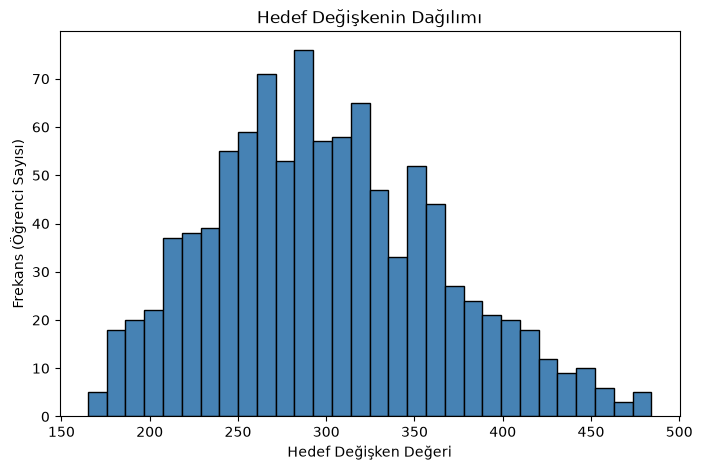

In [4]:
plt.figure(figsize=(8, 5))

plt.hist(df_hedef['hedef_degisken'], bins=30, color='steelblue', edgecolor='black')

plt.title("Hedef Değişkenin Dağılımı")

plt.xlabel("Hedef Değişken Değeri")

plt.ylabel("Frekans (Öğrenci Sayısı)")

plt.show()

Bunlar Hedef Değişken kolonlarımız.



**Peki Hedef Değişkeni ne anlama gelmekte?** Öğrencinin tahmin edilmesi istenen bir performans başarı skorudur.


In [5]:
from scipy.stats import shapiro

stat, p = shapiro(df_hedef['hedef_degisken'].dropna())

print(stat, p)

0.9859780694128174 3.192194690100213e-08


Bu test, hedef_degisken sütununun normal dağılıma uyup uymadığını ölçüyor.



**p-değeri Nedir?** P-değeri, istatistikte "gördüğüm bu sonucun, sadece tesadüfen ortaya çıkma olasılığı nedir?" sorusuna cevap veren bir sayı.



S**hapiro Testi Nedir?** Normal dağılıma uyup uymadığını sayısal olarak test eder.



Test, önce bir varsayım ile başlıyor:



- "Bu veri, normal dağılımdan geliyor."



- P-değeri şunu söylüyor:



- "Eğer bu varsayım gerçekten doğruysa, elimdeki veri kadar 'normalden sapmış' bir örneklem görme ihtimalim nedir?"



**Yorumlama Kuralı**



**p-değeri	Anlamı:**



- p > 0.05	Sapma şansla açıklanabilir veri normal dağılıma uygun diyebiliriz

- p ≤ 0.05	Sapma şansla açıklanamayacak kadar büyük  veri normal dağılıma uygun değil



**Sonuç:** p = 3.192194690100213e-08



Bu, 0.0000000319 demek yani 0.05'ten inanılmaz derecede küçük.



**Sonuç:** hedef_degisken sütunu, istatistiksel olarak normal dağılıma uymuyor.



**stat (Test İstatistiği / W Değeri) Nedir?** Bu, Shapiro testinde W olarak da bilinir. 0 ile 1 arasında bir değerdir. 1'e ne kadar yakınsa, verinin şekli normale o kadar benziyor demektir.



**Sonuç:** stat = 0.9859780694128174 değeri 1'e çok yakın yani veri görsel olarak normale oldukça benziyor.



**Amacımız,** hedef_degisken sütununun normal dağılıma uyup uymadığını sayısal/istatistiksel olarak kesin bir şekilde ölçmekti  yani sadece "gözle bakınca çan şekline benziyor" demek yerine, bunu test ederek kanıtlamaktı.

In [6]:
print(f"İstatistik: {stat}, p-değeri: {p}")

İstatistik: 0.9859780694128174, p-değeri: 3.192194690100213e-08


In [7]:
print(df_hedef['hedef_degisken'].skew())

0.35830563186446585


**Skewness (Çarpıklık) Nedir?** Skewness, bir verinin dağılımının simetrik olup olmadığını ve hangi yöne doğru "kaydığını" ölçen bir sayıdır.

In [8]:
print(df_hedef.columns.tolist())

['öğrenci_id', 'hedef_degisken']


Bu tablomda (df_hedef) hangi sütunlar var, isimleri söyler

In [9]:
%who DataFrame

df_hedef	 


Şu ana kadar oluşturduğum tabloların (DataFrame'lerin) hepsini listeler.

In [10]:
# ==============================================================================
# BOLUM 2 - KESIFSEL VERI ANALIZI
# Buradan asagisi tek bir akis: oku -> temizle -> incele.
# Yukaridaki ilk hucreler sadece hedef tablosuna ilk bakisti.
# ==============================================================================
import sqlite3
import struct

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

In [11]:
# ============================================
# 1. VERIYI OKU VE BIRLESTIR
# ============================================
DB_PATH = '../data/raw/data.db'

conn = sqlite3.connect(DB_PATH)
hedef = pd.read_sql('SELECT * FROM hedef', conn)
notlar = pd.read_sql('SELECT * FROM "not"', conn)   # "not" SQL anahtar kelimesi, tirnak sart
ogrenci = pd.read_sql('SELECT * FROM ogrenci', conn)

print("Tablo satir sayilari:")
print("  ogrenci:", len(ogrenci), "| not:", len(notlar), "| hedef:", len(hedef))

# DIKKAT: burada henuz birlestirmiyorum. Once id kolonunu duzeltmem lazim,
# yoksa mukerrer kayitlari goremiyorum. Sebebini bir alttaki hucrede yaziyorum.

Tablo satir sayilari:
  ogrenci: 1004 | not: 1004 | hedef: 1004


In [12]:
# ==============================================================================
# 2. TEMIZLIK (Byte Hatasi + Turkce Virgullu Sayi Formati + Mukerrer Kayit)
# ==============================================================================


def fix_bytes(v):
  """SQLite'tan gelen ham byte degerlerini int64 tam sayiya cevirir.

  SQLite kolonlara tip zorlamiyor. Bu veride bazi id ve yil degerleri
  8 baytlik little-endian tamsayi olarak yazilmis, '<q' formati bunu cozuyor.
  """
  if isinstance(v, bytes):
    try:
      return struct.unpack('<q', v)[0]
    except Exception:
      return np.nan
  return v


def to_num_tr(v):
  """Byte veya Turkce virgullu string ('85,5') formatindaki sayilari float yapar."""
  if isinstance(v, bytes):
    v = fix_bytes(v)

  if isinstance(v, str):
    v = v.replace(',', '.').strip()
    try:
      return float(v)
    except Exception:
      return np.nan
  return v


byte_cols = [
    'öğrenci_id',
    'dogum_yil',
    'il',
    'cinsiyet(kiz=1, erkek=0)',
    'anne_baba_ayri',
]
num_str_cols = [
    'turkce_not_ort',
    'matematik_not_ort',
    'fen_not_ort',
    'sosyal_not_ort',
    'y_dil_not_ort',
    'din_not_ort',
    'ontest_skoru',
    'hedef_degisken',
]


def tabloyu_temizle(tablo):
  """Tip donusumlerini BIRLESTIRMEDEN ONCE, her tabloya ayri ayri uygular."""
  t = tablo.copy()
  for c in byte_cols:
    if c in t.columns:
      t[c] = t[c].apply(fix_bytes).astype('Int64')
  for c in num_str_cols:
    if c in t.columns:
      t[c] = t[c].apply(to_num_tr)
  return t


ogrenci_t = tabloyu_temizle(ogrenci)
notlar_t = tabloyu_temizle(notlar)
hedef_t = tabloyu_temizle(hedef)

# ---- Mukerrer kayit kontrolu -------------------------------------------------
# Bu kontrolu id'leri duzelttikten SONRA yapmak zorundayim. Duzeltmeden once
# ayni ogrencinin BLOB yazilmis kaydi ile int yazilmis kaydi SQLite acisindan
# iki ayri deger, bu yuzden nunique() mukerrerligi gizliyor.
print('Ham id ile benzersiz ogrenci :', ogrenci['öğrenci_id'].nunique())
print('Duzeltilmis id ile benzersiz :', ogrenci_t['öğrenci_id'].nunique())

tekrar = ogrenci_t['öğrenci_id'].value_counts()
print('Iki kez kayitli ogrenci      :', list(tekrar[tekrar > 1].index))


def mukerrerleri_ayikla(t, ad):
  """Ayni ogrencinin birden fazla kaydindan EN DOLU olani tutar.

  Kopyalar birebir ayni degil, ikinci kayitta bazi alanlar bos. Rastgele
  birini tutmak yerine dolu hucre sayisi en yuksek olani tutuyorum.
  """
  once = len(t)
  t = t.assign(_dolu=t.notna().sum(axis=1))
  t = (t.sort_values('_dolu', ascending=False)
        .drop_duplicates(subset='öğrenci_id', keep='first')
        .drop(columns='_dolu')
        .sort_values('öğrenci_id')
        .reset_index(drop=True))
  print(f'  {ad}: {once} -> {len(t)} satir')
  return t


print()
print('Mukerrer ayiklama:')
ogrenci_t = mukerrerleri_ayikla(ogrenci_t, 'ogrenci')
notlar_t = mukerrerleri_ayikla(notlar_t, 'not    ')
hedef_t = mukerrerleri_ayikla(hedef_t, 'hedef  ')

# ---- Birlestirme -------------------------------------------------------------
df = ogrenci_t.merge(notlar_t, on='öğrenci_id').merge(hedef_t, on='öğrenci_id')

print()
print('Birlestirilmis df shape :', df.shape)
print('Benzersiz ogrenci       :', df['öğrenci_id'].nunique())

print()
print('Eksik Deger Ozeti (eksik olan kolonlar):')
missing_summary = df.isna().sum()[df.isna().sum() > 0]
print(missing_summary if not missing_summary.empty else 'Hic eksik deger bulunmuyor.')

Ham id ile benzersiz ogrenci : 1004


Duzeltilmis id ile benzersiz : 999
Iki kez kayitli ogrenci      : [np.int64(23), np.int64(156), np.int64(489), np.int64(672), np.int64(831)]

Mukerrer ayiklama:


  ogrenci: 1004 -> 999 satir
  not    : 1004 -> 999 satir
  hedef  : 1004 -> 999 satir

Birlestirilmis df shape : (999, 25)
Benzersiz ogrenci       : 999

Eksik Deger Ozeti (eksik olan kolonlar):
burslu                   8
aile_geliri_seviyesi    68
kardes(var/yok)         20
anne_egitim_seviyesi    53
baba_egitim_seviyesi    52
anne_meslek(var/yok)    51
baba_meslek(var/yok)    50
turkce_not_ort           1
matematik_not_ort        1
fen_not_ort              1
sosyal_not_ort           1
y_dil_not_ort            2
din_not_ort              2
dtype: int64


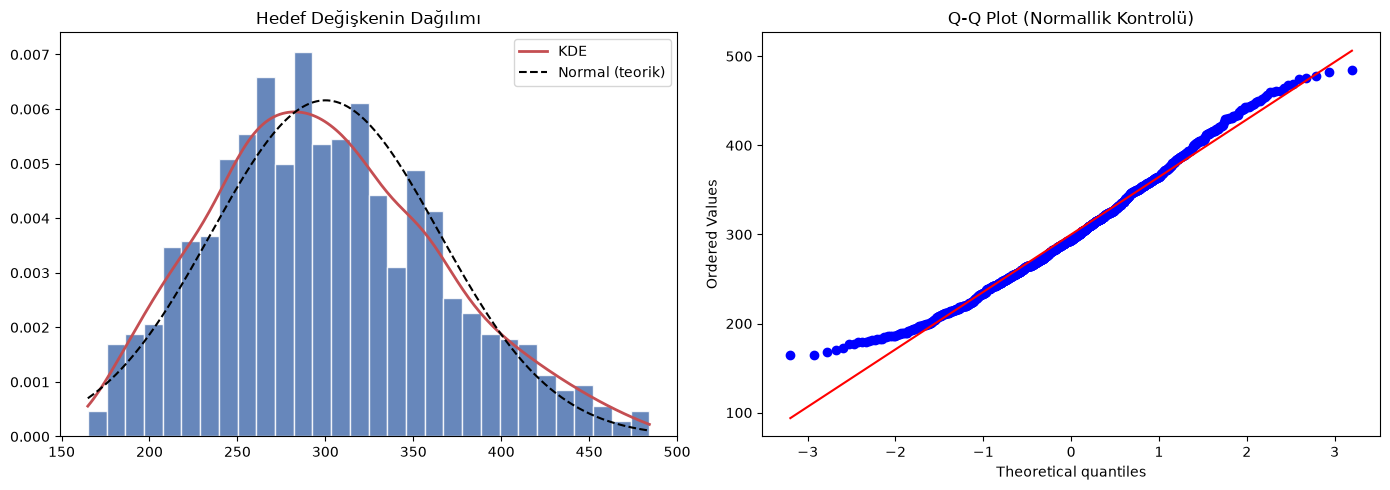

Çarpıklık: 0.3577 | Shapiro-Wilk p-value: 0.000000


In [13]:
# ============================================

# 3. GRAFİK 1: HEDEF DEĞİŞKENİN DAĞILIMI

# ============================================

hedef_col = df['hedef_degisken'].dropna()

 # df['hedef_degisken'] -> DataFrame'den sadece bu tek kolonu seç (bir Series olur)

# .dropna() -> içindeki eksik (NaN) değerleri at, sadece dolu olanları bırak.

# Neden: histogram/istatistik hesaplarken NaN varsa hata verir ya da

#   yanlış sonuç çıkar, o yüzden önce temizliyoruz.

# Sonucu hedef_col adlı yeni bir değişkende saklıyoruz, tekrar tekrar

#   df['hedef_degisken'].dropna() yazmamak için.

 



fig, axes = plt.subplots(1, 2, figsize=(14, 5))



 

# ---- SOL GRAFİK: Histogram + KDE + Normal eğri ----

 

 

axes[0].hist(hedef_col, bins=30, color='#4C72B0', edgecolor='white', alpha=0.85, density=True)

xs = np.linspace(hedef_col.min(), hedef_col.max(), 200)

kde = stats.gaussian_kde(hedef_col)

axes[0].plot(xs, kde(xs), color='#C44E52', linewidth=2, label='KDE')

mu, sigma = hedef_col.mean(), hedef_col.std()



 

axes[0].plot(xs, stats.norm.pdf(xs, mu, sigma), color='black', linestyle='--', label='Normal (teorik)')

axes[0].set_title('Hedef Değişkenin Dağılımı')

axes[0].legend()



 

# ---- SAĞ GRAFİK: Q-Q Plot ----

 

stats.probplot(hedef_col, dist="norm", plot=axes[1])



 

axes[1].set_title('Q-Q Plot (Normallik Kontrolü)')



plt.tight_layout()

plt.show()



 

# ---- İstatistiksel testler: sayısal olarak normallik ölçümü ----

 

 

skew = stats.skew(hedef_col)



shapiro_stat, shapiro_p = stats.shapiro(hedef_col.sample(min(len(hedef_col), 5000), random_state=1))

print(f"Çarpıklık: {skew:.4f} | Shapiro-Wilk p-value: {shapiro_p:.6f}")



 

Mavi çubuklar histogramımız, kırmızı çizgi ise verimizin şeklini daha net görebilmek için var, siyah noktalar ise veri mükemmel normal dağılımı olsaydı böyle görünürdü anlamına geliyor. Normal dağılıma yakın gözüküyor ama Wilk testi yaptık ve istatiksel olarak olmadığını gördük. Sağa yatık bir grafik çünkü skewness (çarpıklık) 0.3577 pozitif bir değer ve şunu öğrendimki skewness değeri  pozitif 0.5'ten büyük ise sağa -0.5 ve 0.5 aralığında ise yaklaşık simetrik negatif -0.5'ten küçük ise sola yatık olur.



Q-Q Plot'ta ise veriler ne kadar kırmızı çizgiye yakınsa sapma o kadar az olur. Normal dağılıma uygun.



1.grafik'i veriler genel olarak tek tepeli mi, çan şeklinde mi, simetrik mi kabaca bir ilk izlenim elde içindi.



2.grafik ise verinin her bir noktasının, tam normal dağılım olsaydı nerede olması gerektiğini ve en düşük ve en yüksek değerlerdeki sapmaları çok daha net yakalamak.

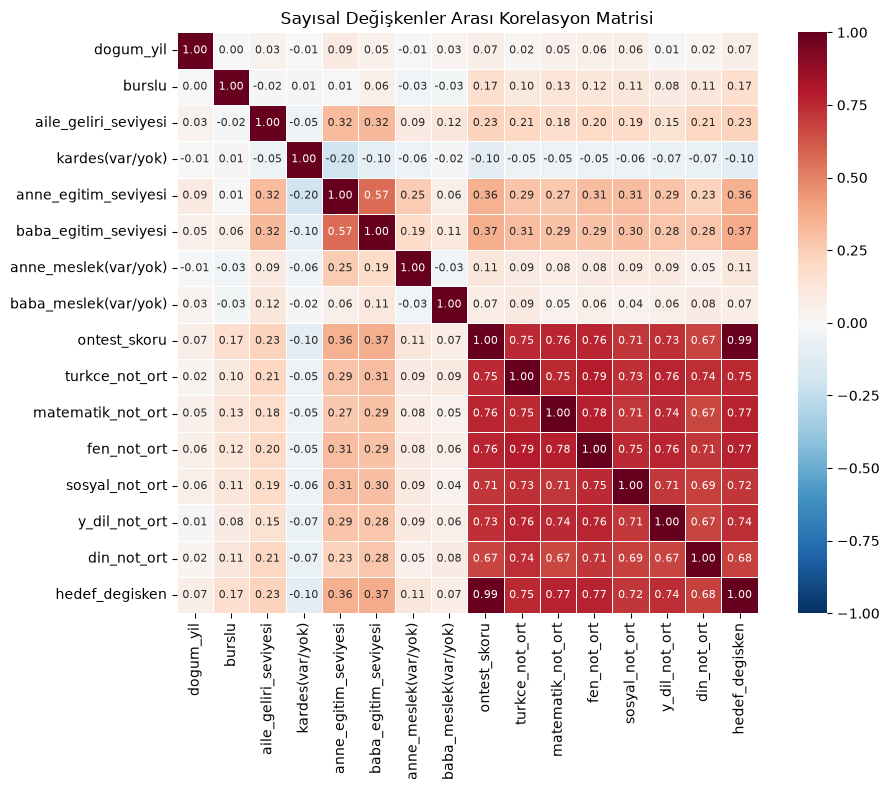

ontest_skoru            0.990002
fen_not_ort             0.768554
matematik_not_ort       0.766975
turkce_not_ort          0.754211
y_dil_not_ort           0.737510
sosyal_not_ort          0.717414
din_not_ort             0.681937
baba_egitim_seviyesi    0.367527
anne_egitim_seviyesi    0.356963
aile_geliri_seviyesi    0.228647
burslu                  0.169643
anne_meslek(var/yok)    0.111004
baba_meslek(var/yok)    0.072685
dogum_yil               0.065370
kardes(var/yok)        -0.101971
Name: hedef_degisken, dtype: float64


In [14]:
# ============================================

# 4. GRAFİK 2: KORELASYON MATRİSİ

# ============================================

num_cols = ['dogum_yil', 'burslu', 'aile_geliri_seviyesi', 'kardes(var/yok)',

            'anne_egitim_seviyesi', 'baba_egitim_seviyesi', 'anne_meslek(var/yok)',

            'baba_meslek(var/yok)', 'ontest_skoru', 'turkce_not_ort', 'matematik_not_ort',

            'fen_not_ort', 'sosyal_not_ort', 'y_dil_not_ort', 'din_not_ort', 'hedef_degisken']

 

corr = df[num_cols].corr(numeric_only=True)

 

plt.figure(figsize=(10 ,8))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,

            square=True, linewidths=0.5, annot_kws={'size': 8})

plt.title('Sayısal Değişkenler Arası Korelasyon Matrisi')

plt.tight_layout()

plt.show()

 

print(corr['hedef_degisken'].drop('hedef_degisken').sort_values(ascending=False))

 

**Korelasyon matrisi nedir ve okuyalım:**



- Veri setindeki tüm sayısal verilerin bir biri ile ne kadar bağlantılı olduğunu gösterir.



- Her hücreye -1 ve +1 arasında değer veriyoruz ve 1 olduğunda  mükemmel pozitif ilişki, 0 olduğunda hiç ilişki yok ve -1 olduduğunda ise mükemmel negatif ilişki anlamına geliyor.



Koyu kırmızı +1



Beyaz 0'a yakın 



Koyu mavi -1



**Neyi görmek istedim?** Korelasyon matrisini çizmemizin temel amacı, hangi değişkenlerin birbiriyle ilişkili olduğunu, hangi değişkenlerin hedef değişkeni (hedef_degisken) etkileyebileceğini görmekti. 




findfont: Failed to find font weight semibold, now using 700.


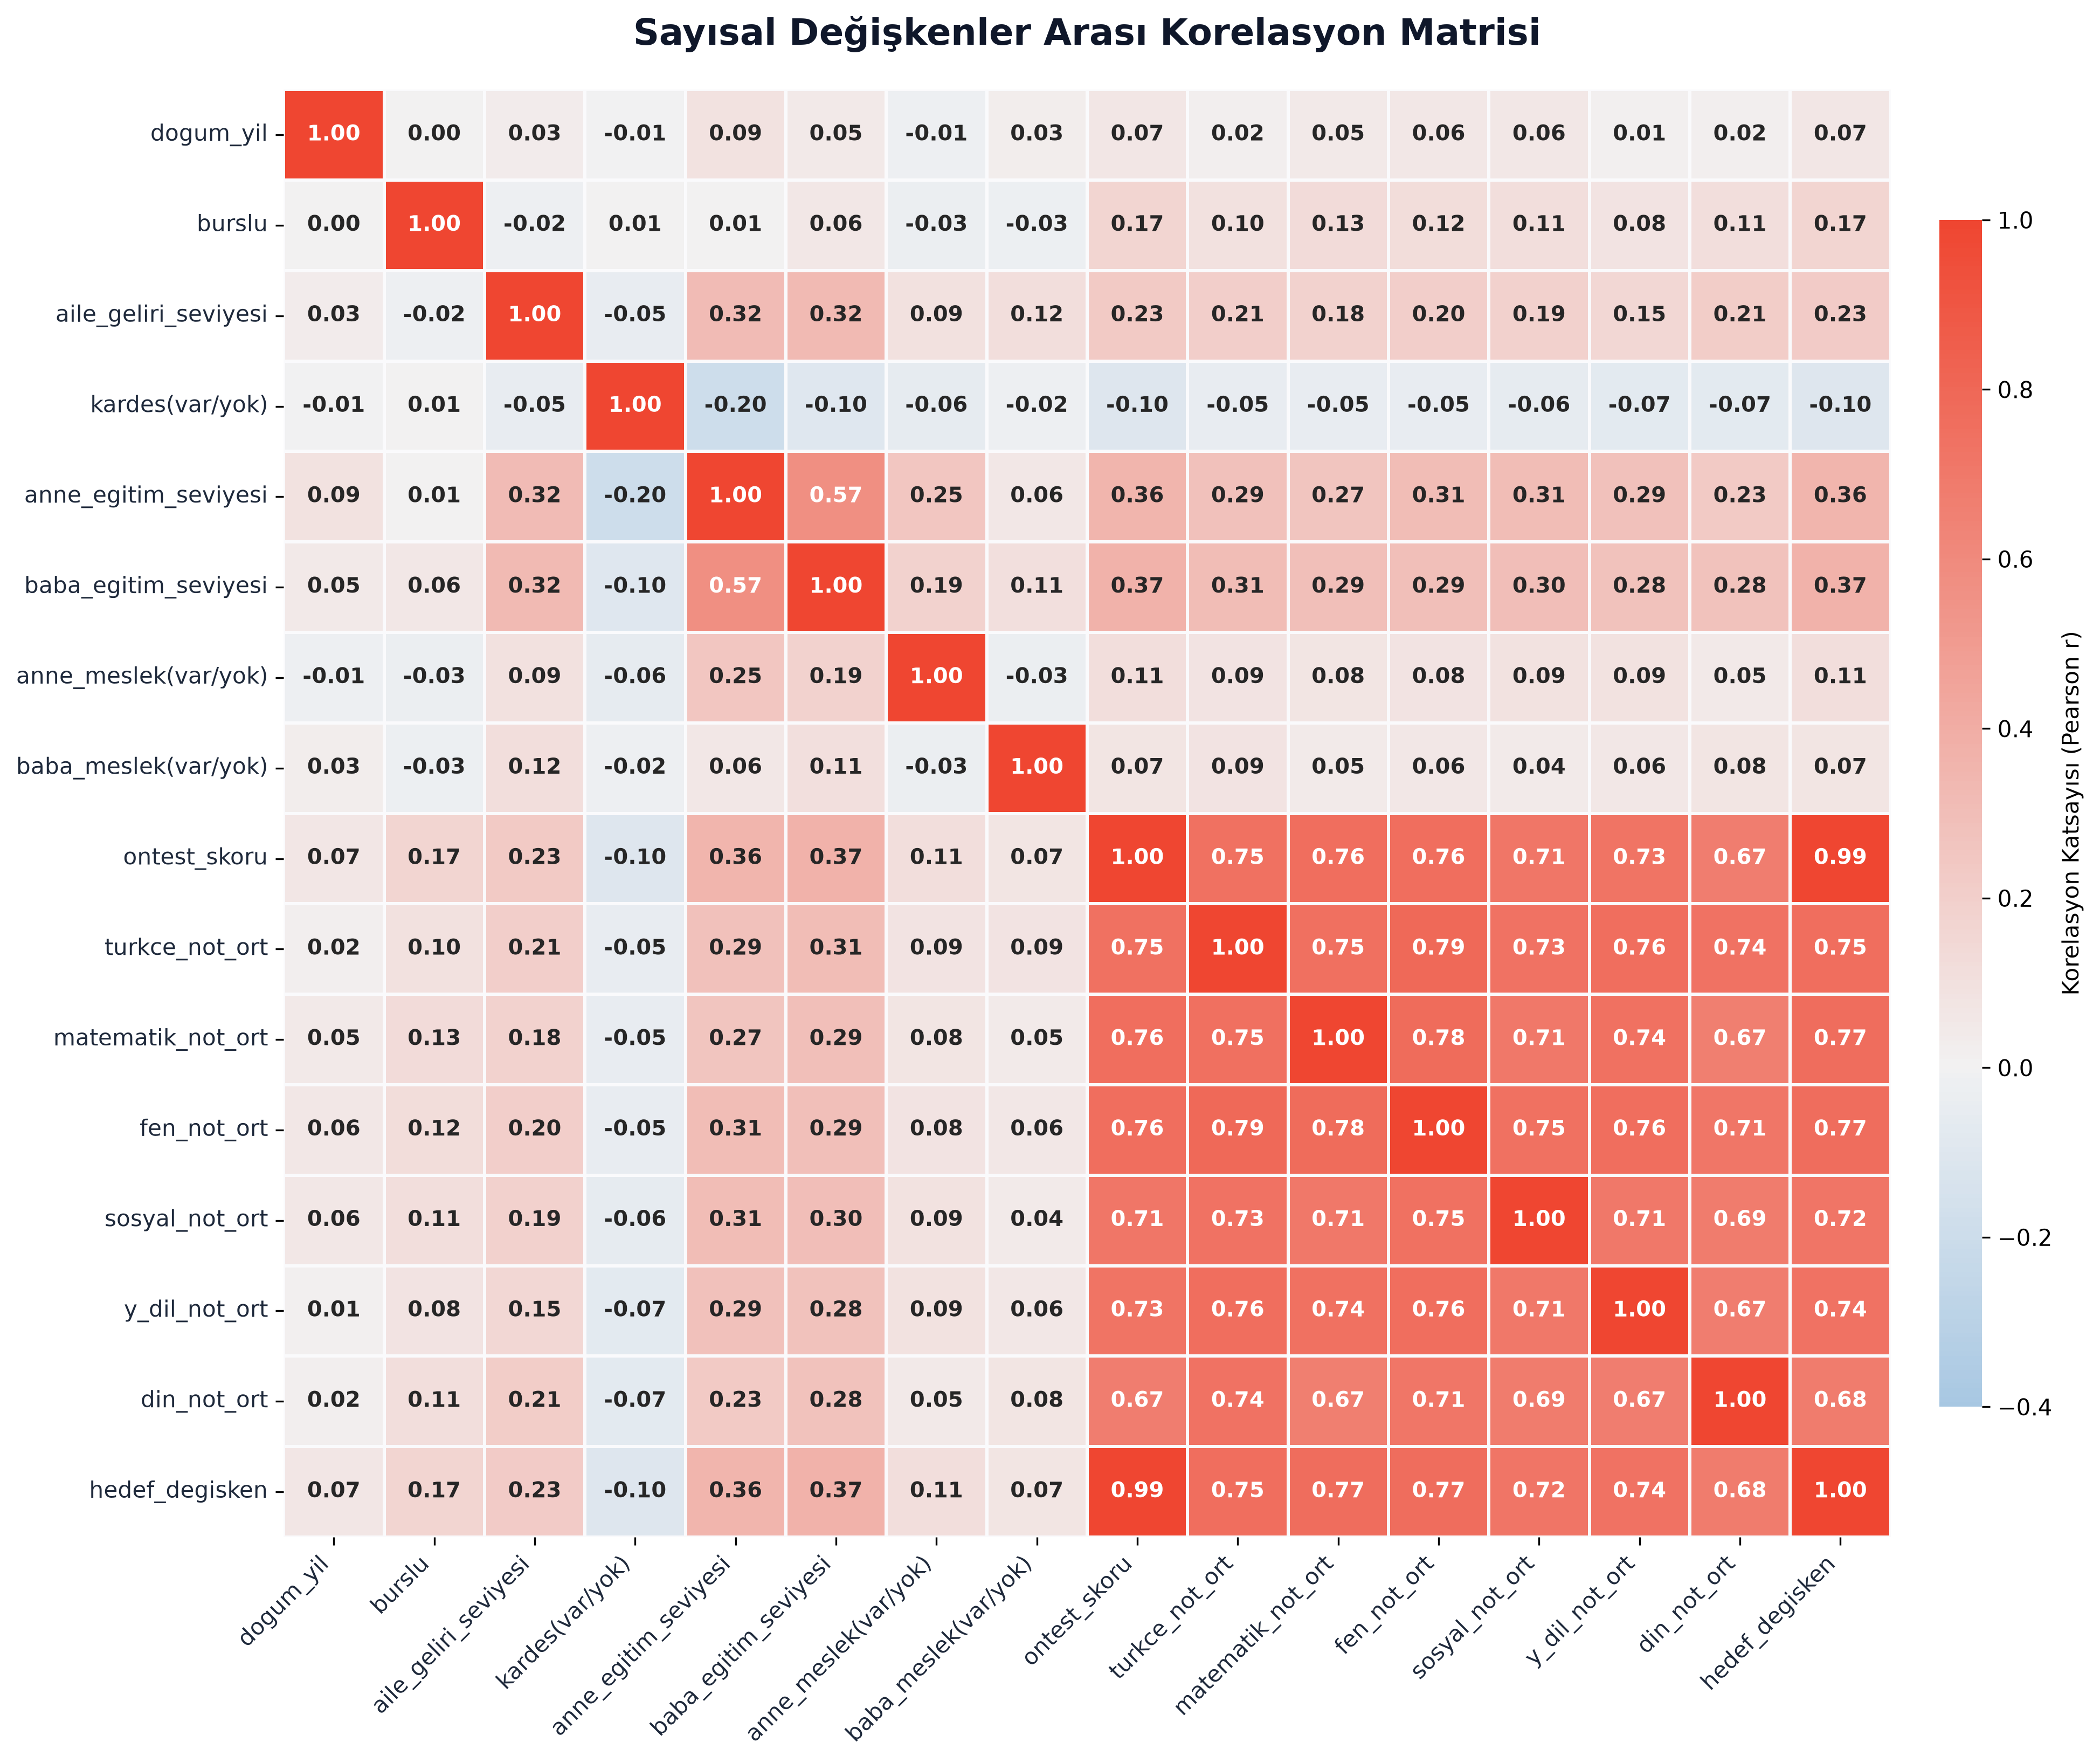

In [15]:
import matplotlib.pyplot as plt

import seaborn as sns



# 1. Görseldeki 16 değişkenin listesi

selected_cols = [

    'dogum_yil',

    'burslu',

    'aile_geliri_seviyesi',

    'kardes(var/yok)',

    'anne_egitim_seviyesi',

    'baba_egitim_seviyesi',

    'anne_meslek(var/yok)',

    'baba_meslek(var/yok)',

    'ontest_skoru',

    'turkce_not_ort',

    'matematik_not_ort',

    'fen_not_ort',

    'sosyal_not_ort',

    'y_dil_not_ort',

    'din_not_ort',

    'hedef_degisken',

]



# 2. Sadece bu sütunların korelasyonunu hesaplama

corr = df[selected_cols].corr()



# 3. Grafik Alanı ve Renk Paleti

plt.figure(figsize=(14, 11), dpi=300)

cmap = sns.diverging_palette(245, 15, s=85, l=55, as_cmap=True)



# 4. Isı Haritası (Heatmap) Çizimi

sns.heatmap(

    corr,

    annot=True,

    fmt='.2f',

    cmap=cmap,

    vmin=-0.4,

    vmax=1.0,

    center=0,

    linewidths=1.0,

    linecolor='#FAFAFC',

    cbar_kws={

        'label': 'Korelasyon Katsayısı (Pearson r)',

        'shrink': 0.82,

        'aspect': 28,

        'pad': 0.025,

    },

    annot_kws={'size': 9.5, 'weight': 'semibold'},

)



# 5. Başlık ve Eksenler

plt.title(

    'Sayısal Değişkenler Arası Korelasyon Matrisi',

    fontsize=16,

    fontweight='bold',

    pad=20,

    color='#0F172A',

)

plt.xticks(rotation=45, ha='right', fontsize=10, color='#1E293B')

plt.yticks(rotation=0, fontsize=10, color='#1E293B')



plt.tight_layout()

plt.show()

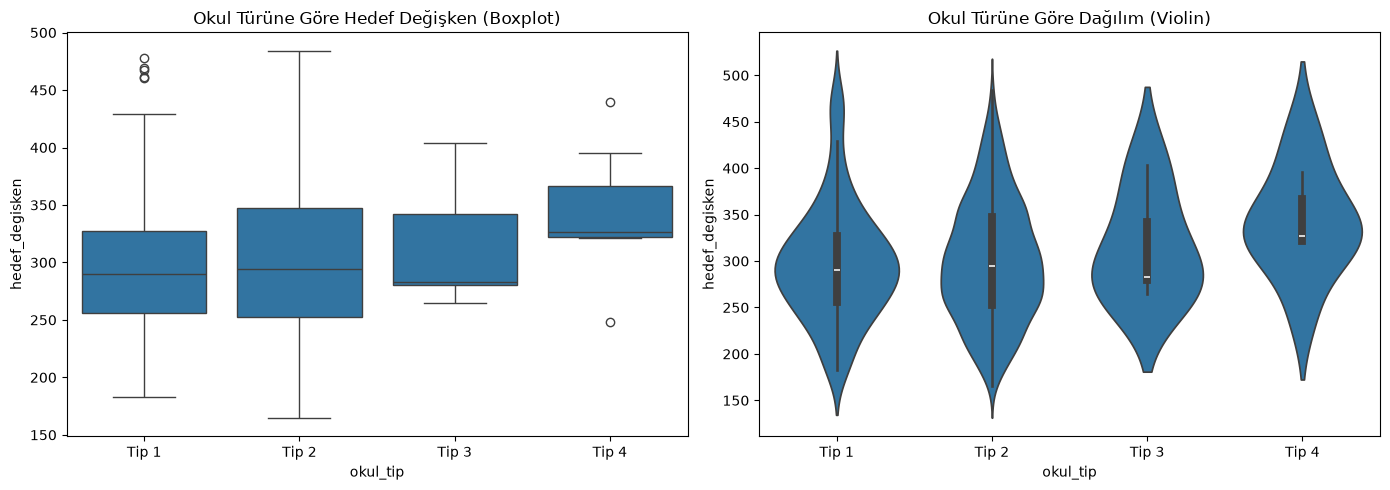

ANOVA: F=1.267, p=0.284523


In [16]:
# ============================================

# 5. GRAFİK 3: OKUL TÜRÜ vs HEDEF DEĞİŞKEN

# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = sorted(df['okul_tip'].unique())

 

sns.boxplot(data=df, x='okul_tip', y='hedef_degisken', ax=axes[0], order=order)

axes[0].set_title('Okul Türüne Göre Hedef Değişken (Boxplot)')

 

sns.violinplot(data=df, x='okul_tip', y='hedef_degisken', ax=axes[1], order=order)

axes[1].set_title('Okul Türüne Göre Dağılım (Violin)')

plt.tight_layout()

plt.show()

 

groups = [g['hedef_degisken'].dropna().values for _, g in df.groupby('okul_tip')]

f_stat, p_val = stats.f_oneway(*groups)

print(f"ANOVA: F={f_stat:.3f}, p={p_val:.6f}")

Okul Türüne Göre Hedef Değişken Boxplot grafiği,

her kutu o gruba ait verinin özet istatisklerini veriyor.

Kutunun içindeki çizgi medyan ortanca değer. Kutunun boyu ne kadar yayıldığını gösterir ve kutu ne kadar büyükse o kadar çeşitlilik var anlamına geliyor. Çizgilerimiz ise max ve min değerleri gösterirken  noktalar aykırı değerleri gösterir yani gruptan anormal şekilde uzaklar.



- Medyanlar sadece kutunun içindeki değerlere göre hesaplanır!



**Violin grafiği:**



- Boxplotun gelişmiş versiyonuymuş, ek olarak dağılım şeklini gösterir.

- Şeklin genişliği o değer aralığında ne kadar öğrenci olduğunu gösterir.

- Ne kadar genişse o kadar veri olduğu anlamına geliyor.

- İçindeki beyaz çizgiler medyanı gösteriyor.

- Şeklin yüksekliği verinin en düşük ve en yüksek değerlerini gösteriyor.



**Neler görmek için ve neden yaptım?**



Bu iki grafiği çizmemizin temel amacı, okul_tip değişkeninin hedef_degisken üzerinde bir etkisi var mı,  yok mu sorusuna cevap aramaktı.

**ANOVA Testi Ne Yapar?**



- ANOVA 3 veya daha fazla grubun ortalamalarını karşılaştırmak için kullanılır.



- Boxplot ve Violin plot'ta gözle gördüğümüz grup farklarının, istatistiksel olarak anlamlı olup olmadığını test eden sonuç.





**F Değeri Nedir?** F = 1.267



- F değeri, gruplar arasındaki farkın, grupların kendi içindeki farka  oranını gösterir.



- F ne kadar büyükse, gruplar arasındaki fark o kadar belirgin demektir.



- F = 1'e yakın değerler, gruplar arası farkın grup içi farktan pek de büyük olmadığını gösterir.



 - F = 1.267 değeri, 1'e oldukça yakın yani gruplar arası fark ile grup içi doğal değişkenlik birbirine benzer büyüklükte. Bu, güçlü bir grup farkı olmadığına işaret ediyor.



**P-değeri Nedir?** p = 0.284523



**p-değeri	Anlamı**



- p > 0.05	Fark, şansla açıklanabilir 



- p ≤ 0.05	Fark, şansla açıklanamayacak kadar büyük  



p = 0.2845, 0.05'ten çok büyük.



**Sonuç:** Okul türleri arasında, hedef_degisken açısından istatistiksel olarak anlamlı bir fark yok.

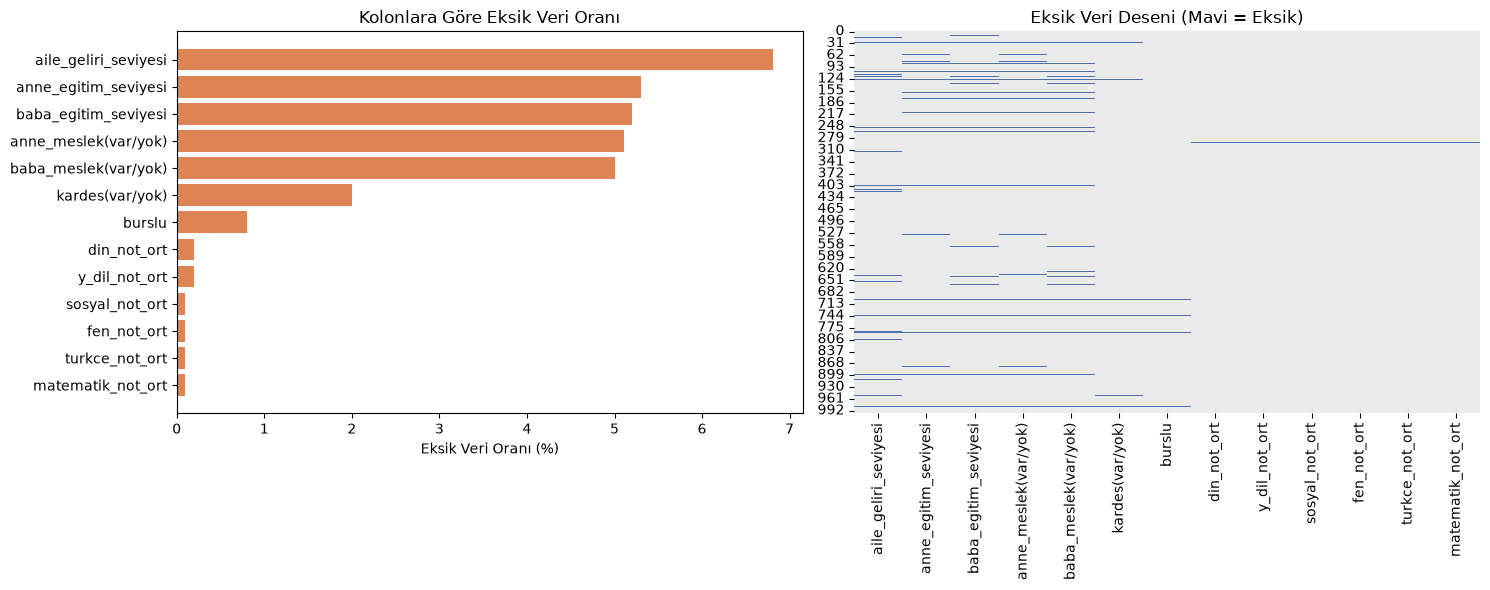

                 anne_egt_eksik  baba_egt_eksik
kiminle_kaliyor                                
Ailesiyle              0.044560        0.043523
Annesiyle              0.280000        0.360000
Babasıyla              0.166667        0.000000
Velisiyle              0.666667        0.333333


In [17]:
# ============================================

# 6. GRAFİK 4: EKSİK VERİ DESENİ

# ============================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

 

miss = df.isna().mean().sort_values(ascending=False)

miss = miss[miss > 0]

axes[0].barh(miss.index, miss.values * 100, color='#DD8452')

axes[0].set_xlabel('Eksik Veri Oranı (%)')

axes[0].set_title('Kolonlara Göre Eksik Veri Oranı')

axes[0].invert_yaxis()

 

miss_cols = miss.index.tolist()

sns.heatmap(df[miss_cols].isna(), cbar=False, cmap=['#EAEAEA', '#4C72B0'], ax=axes[1])

axes[1].set_title('Eksik Veri Deseni (Mavi = Eksik)')

plt.tight_layout()

plt.show()

 

# MAR testi: eksiklik gözlenen bir değişkenle ilişkili mi?

df['anne_egt_eksik'] = df['anne_egitim_seviyesi'].isna().astype(int)

df['baba_egt_eksik'] = df['baba_egitim_seviyesi'].isna().astype(int)

print(df.groupby('kiminle_kaliyor')[['anne_egt_eksik', 'baba_egt_eksik']].mean())

#1.grafik kolonlara göre eksik veri oranı



#2.grafik matrix desen grafiği



Eksiklikler özellikle aile_geliri_seviyesi, anne_egitim_seviyesi, baba_egitim_seviyesi, anne_meslek, baba_meslek sütunlarında belirli satır aralıklarında kümelenmiş görünüyor.



Bu, eksikliğin rastgele dağılmadığını, belirli öğrenci gruplarında (belki belirli okullarda, belirli veri toplama dönemlerinde) birlikte ortaya çıktığını gösteriyor olabilir.



din_not_ort sütununda sadece bir tek mavi çizgi var (992 civarı) — yani neredeyse tamamen dolu.



ontest_skoru sütununda birkaç dağınık mavi çizgi var

## Confounder / Yorumlayıcı Analiz



**Ne yaptım?**

Data leakage temizliğinden önce, ham veri üzerinde aile_geliri_seviyesi, 

burslu, okul_tip ve on_test değişkenlerinin hedef_degisken ile ilişkisini ve 

birbirleri arasındaki potansiyel confounding etkisini inceledim.



**Neden yaptım?**

Bursluluk, on test veya okul tipi gibi değişkenlerin hedef üzerindeki etkisini 

yorumlarken, aile geliri gibi gizli bir değişkenin bu ilişkiyi 

etkileyip etkilemediğini görmek istedim.



**Amacım neydi?**

"Burslu öğrenciler daha başarılı" gibi bir yorum yapmadan önce, bu 

etkinin gerçekten bursluluktan mı yoksa aile gelirinden mi 

kaynaklandığını ayırt etmek.

## Okul Tipi ve Confounder Etkisi 

OKUL TÜRLERİ BAZINDA CONFOUNDER (ARINDIRILMIŞ BAŞARI) ANALİZİ
Kontrol edilenler: burslu, aile_geliri_seviyesi
Okul Türü  Öğrenci Sayısı  Ortalama Gelir  Ortalama Ön Test  Ham Başarı Ortalaması  Düzeltilmiş Başarı (Arındırılmış)  Etki Değişimi (Fark)
    Tip 1             110            2.20            251.62                 296.78                             295.16                 -1.62
    Tip 2             808            2.03            255.78                 300.68                             300.99                  0.31
    Tip 3               5            2.00            264.17                 314.83                             317.30                  2.47
    Tip 4               8            2.00            293.15                 342.09                             331.07                -11.02

KARŞILAŞTIRMA: ontest_skoru kontrol değişkeni olarak EKLENSEYDİ ne olurdu?
Okul Türü    Ham  Düzeltilmiş (doğru)  Düzeltilmiş (ontest dahil, HATALI)
    Tip 1 296.78               295.16   

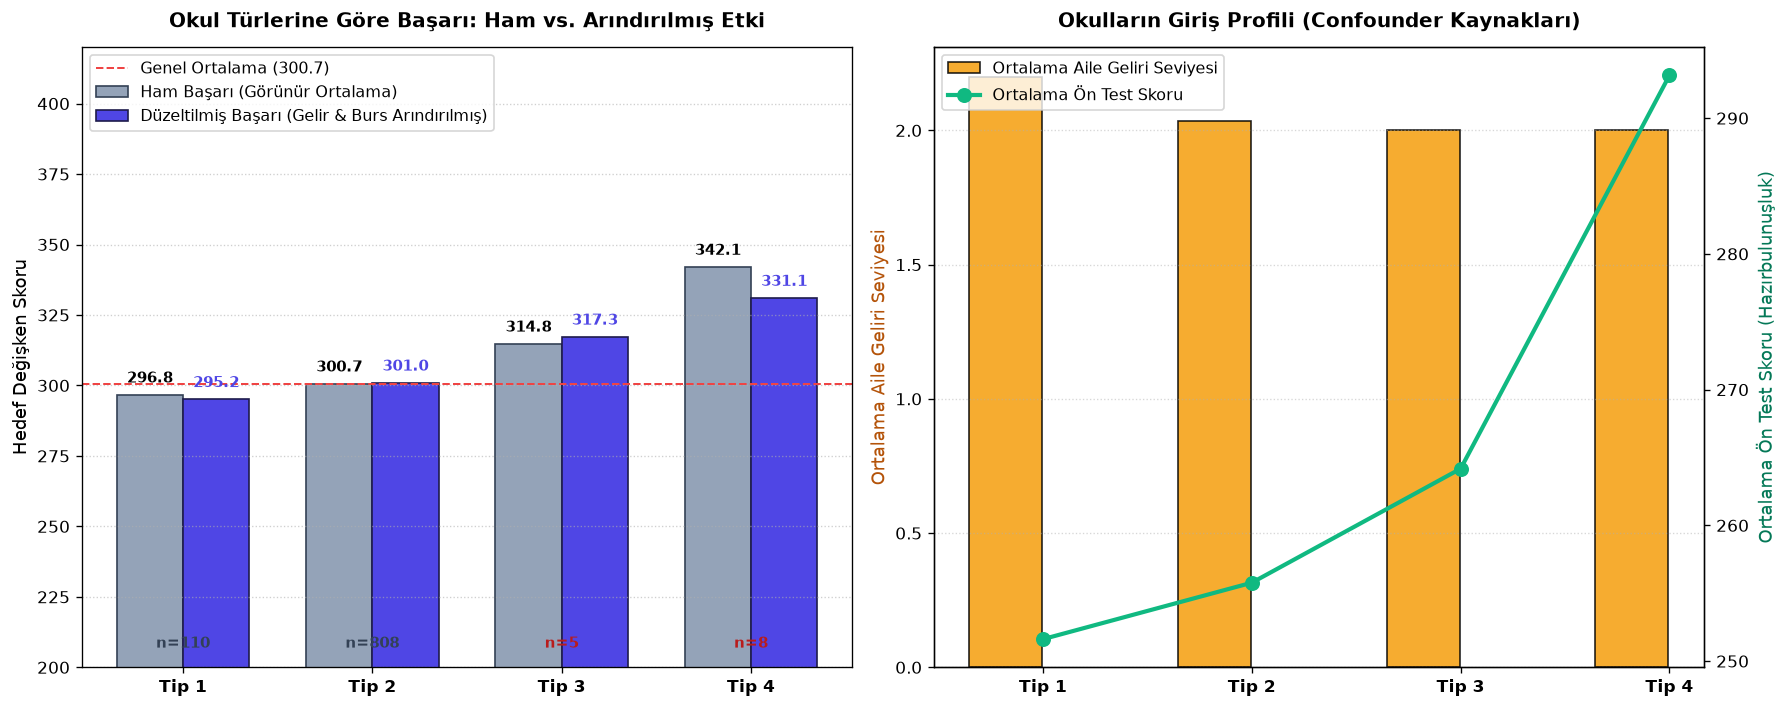

In [18]:
# ==============================================================================
# ADIM 1.5: OKUL TIPLERINE GORE CONFOUNDER & ETKI ANALIZI
# ==============================================================================
# DIKKAT (kendime not): Bu analizi ilk yazdigimda kontrol degiskenlerinin
# arasina ontest_skoru'nu da koymustum. Yanlisti. ontest_skoru ile hedef
# arasindaki korelasyon 0.99, yani ontest fiilen hedefin kendisi. Hedefi
# hedefe gore duzeltince geriye zaten hicbir okul etkisi kalmiyor, sonuc
# kacinilmaz olarak "hicbir okul katki saglamiyor" cikiyor. Bu, verinin
# soyledigi bir sey degil, kurdugum regresyonun kendi kendine urettigi bir sey.
# Asagida iki kontrol setini de hesaplayip yan yana koyuyorum ki fark gorunsun.
from sklearn.linear_model import LinearRegression

cols = [
    'hedef_degisken',
    'okul_tip',
    'burslu',
    'aile_geliri_seviyesi',
    'ontest_skoru',
]
df_c = df[cols].dropna().copy()

okul_tipleri = sorted(df_c['okul_tip'].unique())
genel_ortalama = df_c['hedef_degisken'].mean()

df_dummies = pd.get_dummies(df_c, columns=['okul_tip'], prefix='okul', dtype=float)
okul_cols = [c for c in df_dummies.columns if c.startswith('okul_')]
y = df_dummies['hedef_degisken']


def duzeltilmis_ortalamalar(kontroller):
  """Kontrol degiskenleri sabitlendiginde her okulun ortalama skoru.

  Intercept'siz kurup butun okul kuklalarini birakiyorum, boylece her
  katsayi dogrudan o okulun baz puani oluyor. Uzerine kontrollerin genel
  ortalamadaki etkisini ekliyorum, yani "ortalama ogrenci profiline sahip
  olsalardi bu okullar ne verirdi" sorusunun cevabi.
  """
  X = df_dummies[okul_cols + kontroller]
  lr = LinearRegression(fit_intercept=False).fit(X, y)
  coef_map = dict(zip(X.columns, lr.coef_))
  ofset = sum(coef_map[k] * df_c[k].mean() for k in kontroller)
  return [coef_map[f'okul_{t}'] + ofset for t in okul_tipleri]


kontrol_dogru = ['burslu', 'aile_geliri_seviyesi']
kontrol_hatali = ['burslu', 'aile_geliri_seviyesi', 'ontest_skoru']

ham_ortalamalar = [df_c.loc[df_c['okul_tip'] == t, 'hedef_degisken'].mean()
                   for t in okul_tipleri]
duzeltilmis_ortalamalar_ = duzeltilmis_ortalamalar(kontrol_dogru)
sizintili_ortalamalar = duzeltilmis_ortalamalar(kontrol_hatali)

ogrenci_sayilari = [int((df_c['okul_tip'] == t).sum()) for t in okul_tipleri]
ortalama_gelirler = [df_c.loc[df_c['okul_tip'] == t, 'aile_geliri_seviyesi'].mean()
                     for t in okul_tipleri]
ortalama_ontestler = [df_c.loc[df_c['okul_tip'] == t, 'ontest_skoru'].mean()
                      for t in okul_tipleri]

analiz_df = pd.DataFrame({
    'Okul Türü': okul_tipleri,
    'Öğrenci Sayısı': ogrenci_sayilari,
    'Ortalama Gelir': ortalama_gelirler,
    'Ortalama Ön Test': ortalama_ontestler,
    'Ham Başarı Ortalaması': ham_ortalamalar,
    'Düzeltilmiş Başarı (Arındırılmış)': duzeltilmis_ortalamalar_,
})
analiz_df['Etki Değişimi (Fark)'] = (
    analiz_df['Düzeltilmiş Başarı (Arındırılmış)']
    - analiz_df['Ham Başarı Ortalaması']
)

print('=' * 85)
print('OKUL TÜRLERİ BAZINDA CONFOUNDER (ARINDIRILMIŞ BAŞARI) ANALİZİ')
print('Kontrol edilenler: burslu, aile_geliri_seviyesi')
print('=' * 85)
print(analiz_df.round(2).to_string(index=False))

print()
print('=' * 85)
print('KARŞILAŞTIRMA: ontest_skoru kontrol değişkeni olarak EKLENSEYDİ ne olurdu?')
print('=' * 85)
kiyas = pd.DataFrame({
    'Okul Türü': okul_tipleri,
    'Ham': ham_ortalamalar,
    'Düzeltilmiş (doğru)': duzeltilmis_ortalamalar_,
    'Düzeltilmiş (ontest dahil, HATALI)': sizintili_ortalamalar,
})
print(kiyas.round(2).to_string(index=False))
print()
print('Not: ontest_skoru hedefle 0.99 korelasyonlu. Onu kontrol degiskeni yapmak')
print('hedefi hedefe gore duzeltmek demek, o yuzden sagdaki sutun kullanilamaz.')

# ==============================================================================
# GORSELLESTIRME: HAM vs. DUZELTILMIS BASARI VE OKUL PROFILI
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=120)

x = np.arange(len(okul_tipleri))
width = 0.35

rects1 = ax1.bar(
    x - width / 2,
    analiz_df['Ham Başarı Ortalaması'],
    width,
    label='Ham Başarı (Görünür Ortalama)',
    color='#94A3B8',
    edgecolor='#334155',
)
rects2 = ax1.bar(
    x + width / 2,
    analiz_df['Düzeltilmiş Başarı (Arındırılmış)'],
    width,
    label='Düzeltilmiş Başarı (Gelir & Burs Arındırılmış)',
    color='#4F46E5',
    edgecolor='#1E1B4B',
)

ax1.axhline(
    genel_ortalama,
    color='#EF4444',
    linestyle='--',
    linewidth=1.2,
    label=f'Genel Ortalama ({genel_ortalama:.1f})',
)
ax1.set_title(
    'Okul Türlerine Göre Başarı: Ham vs. Arındırılmış Etki',
    fontsize=12,
    fontweight='bold',
    pad=12,
)
ax1.set_xticks(x)
ax1.set_xticklabels(okul_tipleri, fontweight='bold')
ax1.set_ylabel('Hedef Değişken Skoru', fontsize=11)
ax1.set_ylim(200, 420)
ax1.legend(loc='upper left', fontsize=9.5)
ax1.grid(axis='y', linestyle=':', alpha=0.6)

for r in rects1:
  ax1.text(r.get_x() + r.get_width() / 2, r.get_height() + 3,
           f'{r.get_height():.1f}', ha='center', va='bottom',
           fontsize=9, fontweight='bold')
for r in rects2:
  ax1.text(r.get_x() + r.get_width() / 2, r.get_height() + 3,
           f'{r.get_height():.1f}', ha='center', va='bottom',
           fontsize=9, fontweight='bold', color='#4F46E5')

# Kac ogrenciye dayandigini grafigin uzerine yaziyorum. Tip 3 ve Tip 4'te
# n cok kucuk, bunu gormeden yorum yapmak yaniltici olur.
for i, n in enumerate(ogrenci_sayilari):
  ax1.text(i, 207, f'n={n}', ha='center', fontsize=9,
           color='#B91C1C' if n < 30 else '#334155',
           fontweight='bold')

ax2_twin = ax2.twinx()
ax2.bar(
    x - 0.18,
    analiz_df['Ortalama Gelir'],
    width=0.35,
    color='#F59E0B',
    alpha=0.85,
    label='Ortalama Aile Geliri Seviyesi',
    edgecolor='black',
)
ax2_twin.plot(
    x,
    analiz_df['Ortalama Ön Test'],
    color='#10B981',
    marker='o',
    linewidth=2.5,
    markersize=8,
    label='Ortalama Ön Test Skoru',
)

ax2.set_title(
    'Okulların Giriş Profili (Confounder Kaynakları)',
    fontsize=12,
    fontweight='bold',
    pad=12,
)
ax2.set_xticks(x)
ax2.set_xticklabels(okul_tipleri, fontweight='bold')
ax2.set_ylabel('Ortalama Aile Geliri Seviyesi', fontsize=10.5, color='#B45309')
ax2_twin.set_ylabel('Ortalama Ön Test Skoru (Hazırbulunuşluk)',
                    fontsize=10.5, color='#047857')
ax2.grid(axis='y', linestyle=':', alpha=0.5)

lines, labels = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=9.5)

plt.tight_layout()
plt.show()

**Ne yaptım?**
Dört okul tipini aile geliri, bursluluk, ham başarı ve düzeltilmiş başarı
açısından yan yana koydum. Düzeltilmiş başarı şu demek: bütün okullara aynı
ortalama öğrenci profilini verseydim ortalamaları ne olurdu?

**Neden yaptım?**
Okul tipleri arasında görünen başarı farkı okulun kendi katkısı mı, yoksa
oraya giden öğrencinin zaten farklı olmasından mı geliyor, bunu ayırmak için.

**Bir hatamı burada düzelttim.**
Bu analizi ilk kurduğumda kontrol değişkenlerinin arasına `ontest_skoru`'nu da
koymuştum. Sonuç çok çarpıcı çıkmıştı: Tip 4'ün ortalaması 342.1'den 298.5'e
düşüyordu, yani "bu okulun katkısı yokmuş" gibi görünüyordu. Sonra fark ettim ki
`ontest_skoru` ile hedef arasındaki korelasyon 0.99. Yani ön test skoru pratikte
hedefin kendisi. Hedefi hedefe göre düzeltirsem geriye hiçbir okul etkisi
kalmaması zaten matematiksel bir zorunluluk, verinin bana söylediği bir şey
değil. Üstteki karşılaştırma tablosunda iki kontrol setini de bıraktım ki fark
görünsün: doğru kurulumda Tip 4 için 331.1, hatalı kurulumda 298.5 çıkıyor.
Aradaki 32 puanın tamamı benim kurgu hatamdı.

**Ne gördüm? (doğru kurulumla)**

| Okul | n | Ort. gelir | Ham | Düzeltilmiş | Fark |
|---|---|---|---|---|---|
| Tip 1 | 110 | 2.20 | 296.8 | 295.2 | -1.6 |
| Tip 2 | 808 | 2.03 | 300.7 | 301.0 | +0.3 |
| Tip 3 | 5 | 2.00 | 314.8 | 317.3 | +2.5 |
| Tip 4 | 8 | 2.00 | 342.1 | 331.1 | -11.0 |

- Gelir ve burs kontrol edildiğinde tablo neredeyse hiç değişmiyor. Tip 1 ve
  Tip 2'de oynama 2 puanın altında.
- Yani ortada büyük bir confounder yok. Sağdaki profil grafiğinde de bu
  görünüyor: dört okulun ortalama geliri 2.00 ile 2.20 arasında sıkışmış,
  birbirinden ayrışmıyorlar.
- Tip 4 düzeltmeden sonra da ortalamanın 31 puan üstünde kalıyor.

**Sonuç:**
Confounder hipotezim bu veride doğrulanmadı. Okullar arası gelir farkı yok
denecek kadar küçük olduğu için düzeltmenin düzeltecek bir şeyi yok.

Ama buradan "Tip 4 gerçekten daha iyi bir okul" sonucunu da çıkaramıyorum.
Tip 4'te 8 öğrenci var, Tip 3'te 5. Hedefin standart sapması 65 puan; 8 kişilik
bir grubun ortalamasının 30-40 puan sapması bu örneklem büyüklüğünde gayet
olağan. Nitekim bir sonraki hücredeki ANOVA da p = 0.31 veriyor, yani gruplar
arası fark şansla açıklanabilir düzeyde.

Kurduğum cümle şu olmalı: **bu veriyle okul tipinin etkisi ölçülemiyor.**
"Etkisi yok" demiyorum, "elimdeki 999 öğrenciyle tespit edilebilecek bir etki
yok" diyorum. İkisi farklı şeyler. Tip 3 ve Tip 4 için anlamlı bir şey
söyleyebilmek adına her gruptan en az 30-40 öğrenci lazımdı.

## Aile Geliri Seviyesi ve Confounder Etkisi

AİLE GELİRİ SEVİYESİ BAZINDA CONFOUNDER (ARINDIRILMIŞ BAŞARI) ANALİZİ
Kontrol edilenler: burslu + okul tipi kuklalari
Gelir Seviyesi  Öğrenci Sayısı  Ortalama Ön Test  Ham Başarı Ortalaması  Düzeltilmiş Başarı (Arındırılmış)  Etki Değişimi (Fark)
      Seviye 0              15            204.13                 238.55                             239.57                  1.02
      Seviye 1             180            239.49                 282.48                             281.76                 -0.72
      Seviye 2             490            254.35                 299.08                             298.98                 -0.10
      Seviye 3             233            273.14                 320.72                             321.32                  0.59
      Seviye 4              13            274.51                 323.18                             325.12                  1.93

KARŞILAŞTIRMA: ontest_skoru kontrole eklenseydi (HATALI kurulum)
   Gelir    Ham  Düzeltilmiş (doğru)  Düze

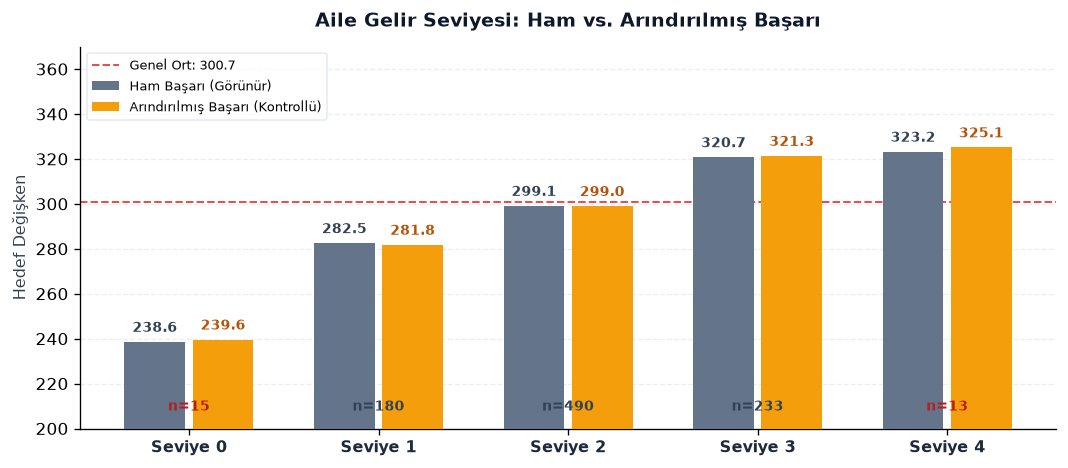

In [19]:
# ==============================================================================
# AILE GELIRI SEVIYESI CONFOUNDER ANALIZI
# ==============================================================================
# Ayni duzeltme burada da gecerli: kontrol setine ontest_skoru koymuyorum.
# Onceki surumde koymustum ve "gelirin etkisi kayboluyor" gibi bir sonuc
# almistim. O sonuc gelirle ilgili degildi, ontest ile hedefin ayni sey
# olmasiyla ilgiliydi.

analiz_kolonlari = ['hedef_degisken', 'aile_geliri_seviyesi', 'burslu',
                    'okul_tip', 'ontest_skoru']
df_gelir = df[analiz_kolonlari].dropna().copy()
genel_ortalama = df_gelir['hedef_degisken'].mean()

gelir_seviyeleri = sorted(df_gelir['aile_geliri_seviyesi'].unique())

# Gelir ve okul tipini kukla degiskene ceviriyorum, burslu zaten 0/1.
dd = pd.get_dummies(df_gelir, columns=['aile_geliri_seviyesi', 'okul_tip'],
                    prefix=['gelir', 'okul'], dtype=float)
gelir_cols = [c for c in dd.columns if c.startswith('gelir_')]
okul_cols = [c for c in dd.columns if c.startswith('okul_')]
y = dd['hedef_degisken']


def gelir_duzeltilmis(kontroller):
  X = dd[gelir_cols + kontroller]
  lr = LinearRegression(fit_intercept=False).fit(X, y)
  cm = dict(zip(X.columns, lr.coef_))
  ofset = sum(cm[k] * dd[k].mean() for k in kontroller)
  return [cm[f'gelir_{g}'] + ofset for g in gelir_seviyeleri]


kontrol_dogru = ['burslu'] + okul_cols
kontrol_hatali = ['burslu', 'ontest_skoru'] + okul_cols

gelir_ham = [df_gelir.loc[df_gelir['aile_geliri_seviyesi'] == g,
                          'hedef_degisken'].mean() for g in gelir_seviyeleri]
gelir_adj = gelir_duzeltilmis(kontrol_dogru)
gelir_sizintili = gelir_duzeltilmis(kontrol_hatali)
gelir_sayi = [int((df_gelir['aile_geliri_seviyesi'] == g).sum())
              for g in gelir_seviyeleri]
ort_ontestler = [df_gelir.loc[df_gelir['aile_geliri_seviyesi'] == g,
                              'ontest_skoru'].mean() for g in gelir_seviyeleri]

df_gelir_res = pd.DataFrame({
    'Gelir Seviyesi': [f'Seviye {int(g)}' for g in gelir_seviyeleri],
    'Öğrenci Sayısı': gelir_sayi,
    'Ortalama Ön Test': ort_ontestler,
    'Ham Başarı Ortalaması': gelir_ham,
    'Düzeltilmiş Başarı (Arındırılmış)': gelir_adj,
})
df_gelir_res['Etki Değişimi (Fark)'] = (
    df_gelir_res['Düzeltilmiş Başarı (Arındırılmış)']
    - df_gelir_res['Ham Başarı Ortalaması']
)

print('=' * 95)
print('AİLE GELİRİ SEVİYESİ BAZINDA CONFOUNDER (ARINDIRILMIŞ BAŞARI) ANALİZİ')
print('Kontrol edilenler: burslu + okul tipi kuklalari')
print('=' * 95)
print(df_gelir_res.round(2).to_string(index=False))
print('=' * 95)

print()
print('KARŞILAŞTIRMA: ontest_skoru kontrole eklenseydi (HATALI kurulum)')
print(pd.DataFrame({
    'Gelir': [f'Seviye {int(g)}' for g in gelir_seviyeleri],
    'Ham': gelir_ham,
    'Düzeltilmiş (doğru)': gelir_adj,
    'Düzeltilmiş (ontest dahil)': gelir_sizintili,
}).round(2).to_string(index=False))

# ---- Grafik -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4), dpi=120)
x = np.arange(len(gelir_seviyeleri))
width = 0.32

r1 = ax.bar(x - width / 2 - 0.02, df_gelir_res['Ham Başarı Ortalaması'], width,
            label='Ham Başarı (Görünür)', color='#64748B', zorder=3)
r2 = ax.bar(x + width / 2 + 0.02, df_gelir_res['Düzeltilmiş Başarı (Arındırılmış)'],
            width, label='Arındırılmış Başarı (Kontrollü)', color='#F59E0B', zorder=3)

ax.axhline(genel_ortalama, color='#DC2626', linestyle='--', linewidth=1.2,
           alpha=0.8, label=f'Genel Ort: {genel_ortalama:.1f}', zorder=2)

for rect, renk in [(r1, '#334155'), (r2, '#B45309')]:
  for bar in rect:
    ax.annotate(f'{bar.get_height():.1f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=8.5,
                fontweight='bold', color=renk)

for i, n in enumerate(gelir_sayi):
  ax.text(i, 208, f'n={n}', ha='center', fontsize=8.5, fontweight='bold',
          color='#B91C1C' if n < 30 else '#334155')

ax.set_title('Aile Gelir Seviyesi: Ham vs. Arındırılmış Başarı',
             fontsize=11.5, fontweight='bold', pad=12, color='#0F172A')
ax.set_xticks(x)
ax.set_xticklabels(df_gelir_res['Gelir Seviyesi'], fontsize=9.5,
                   fontweight='bold', color='#1E293B')
ax.set_ylabel('Hedef Değişken', fontsize=9.5, color='#334155')
ax.set_ylim(200, 370)
ax.grid(axis='y', linestyle='--', alpha=0.4, color='#CBD5E1', zorder=0)
ax.grid(visible=False, axis='x')
sns.despine(top=True, right=True)
ax.legend(frameon=True, facecolor='white', edgecolor='#E2E8F0',
          fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

**Ne yaptım?**
Beş gelir seviyesini ham başarı ve arındırılmış başarı açısından karşılaştırdım.
Kontrol olarak bursluluk ve okul tipini sabitledim.

**Neden yaptım?**
"Gelir arttıkça başarı artıyor" görüntüsünün gerçekten gelirden mi geldiğini,
yoksa gelirle birlikte gelen başka bir şeyden mi kaynaklandığını anlamak için.

**Ne gördüm?**

| Gelir | n | Ham | Düzeltilmiş | Fark |
|---|---|---|---|---|
| Seviye 0 | 15 | 238.6 | 239.6 | +1.0 |
| Seviye 1 | 180 | 282.5 | 281.8 | -0.7 |
| Seviye 2 | 490 | 299.1 | 299.0 | -0.1 |
| Seviye 3 | 233 | 320.7 | 321.3 | +0.6 |
| Seviye 4 | 13 | 323.2 | 325.1 | +1.9 |

- Ham başarı gelirle birlikte düzenli artıyor. Seviye 0 ile Seviye 4 arasında
  85 puan fark var, hedefin standart sapması 65 iken bu büyük bir fark.
- Burs ve okul tipi sabitlendiğinde tablo neredeyse hiç oynamıyor. En büyük
  düzeltme 1.9 puan.
- Yani gelirin başarıyla ilişkisi başka bir değişkenin gölgesi değil, kendi
  başına duruyor.

**Burada da aynı hatayı düzelttim.**
Önceki kurulumda kontrol setinde `ontest_skoru` vardı ve tablo şöyle çıkıyordu:
bütün gelir seviyeleri düzeltmeden sonra 298-301 aralığına toplanıyordu, ben de
"gelirin etkisi yokmuş, asıl belirleyici hazırbulunuşluk" diye yazmıştım.
Üstteki karşılaştırma tablosunda o sütun duruyor. Seviye 0 için 238.6 olan ham
ortalama 298.2'ye fırlıyor. Bu 60 puanlık sıçrama gelirle ilgili bir bulgu
değil, hedefle 0.99 korelasyonlu bir değişkeni kontrol değişkeni yapmanın
sonucu. `ontest_skoru`'nu çıkarınca gelir farkı olduğu gibi duruyor.

**Sonuç:**
Gelir, hedefle güçlü ve doğrudan ilişkili. Elimdeki kontrollerle bu ilişkiyi
açıklayıp yok edemiyorum.

Bunun iki sonucu var. Birincisi, gelir modelde işe yarayacak bir değişken.
İkincisi ve daha önemlisi, bu bir adalet sorunu: model geliri kullanırsa düşük
gelirli öğrenciye sistematik olarak düşük tahmin verecek ve bu tahmin
"desteklenecek öğrenci" listelerini belirleyecek. Bunu Bölüm 5'te ayrıca ele
alıyorum.

Bir sınır daha var: Seviye 0'da 15, Seviye 4'te 13 öğrenci var. Uçlardaki iki
kutunun tam yeri oynak, ama ortadaki üç seviye (n = 180, 490, 233) tek başına
bile artışı gösteriyor.

##  Bursluluk ve Confounder Etkisi

BURSLULUK DURUMU BAZINDA CONFOUNDER (ARINDIRILMIŞ BAŞARI) ANALİZİ
Kontrol edilenler: aile_geliri_seviyesi + okul tipi kuklalari
Burs Durumu  Öğrenci Sayısı  Ortalama Gelir  Ham Başarı Ortalaması  Düzeltilmiş Başarı (Arındırılmış)  Etki Değişimi (Fark)
Burssuz (0)             919            2.05                 299.26                             299.26                  0.00
 Burslu (1)              12            1.92                 407.20                             407.13                 -0.07

ESKI CELISKININ KAYNAGI
Burs Durumu    Ham  Düzeltilmiş (doğru)  Düzeltilmiş (ontest dahil)
Burssuz (0) 299.26               299.26                      300.61
 Burslu (1) 407.20               407.13                      303.38

Iki analizin farkli sonuc vermesinin sebebi yontem degil, kontrol setiydi.
ontest_skoru kontrole girince burslunun ortalamasi 103 puan dusuyor.


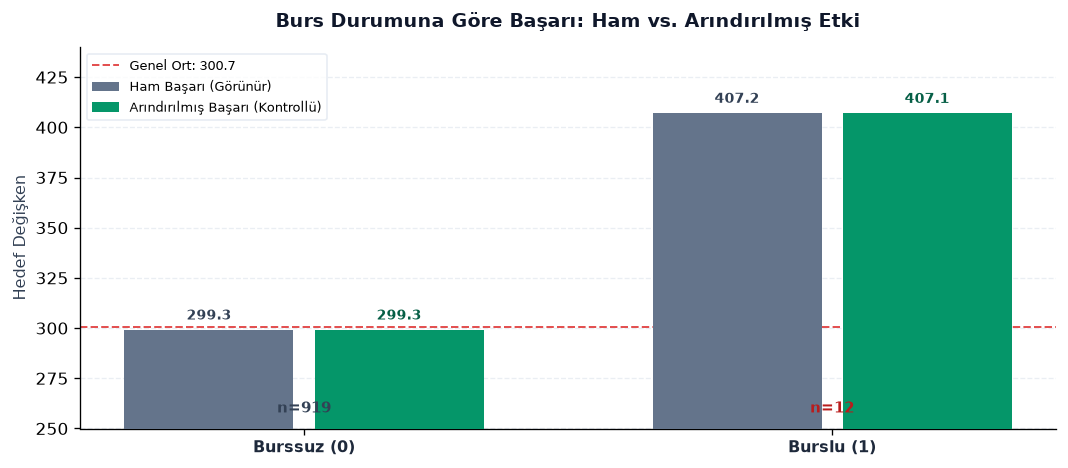

In [20]:
# ==============================================================================
# BURSLULUK DURUMU CONFOUNDER ANALIZI
# ==============================================================================
# Bu bolumu bastan yazdim. Onceki halinde iki burs analizi birbiriyle celisiyordu
# ve ben de notuma "hangi kurulumun kullanildigi netlesmeden yazilamaz" diye
# yazip birakmistim. Celiskinin sebebini buldum: bir analizde kontrol setinde
# ontest_skoru vardi, digerinde yoktu. Asagida ikisini de hesaplayip
# celiskinin nereden geldigini gosteriyorum.

df_burs = df[['hedef_degisken', 'burslu', 'aile_geliri_seviyesi',
              'okul_tip', 'ontest_skoru']].dropna().copy()
genel_ortalama = df_burs['hedef_degisken'].mean()

df_burs['burs_durumu'] = df_burs['burslu'].map({0.0: 'Burssuz (0)', 1.0: 'Burslu (1)'})
burs_tipleri = ['Burssuz (0)', 'Burslu (1)']

dd = pd.get_dummies(df_burs, columns=['burs_durumu', 'okul_tip'],
                    prefix=['burs', 'okul'], dtype=float)
burs_cols = [f'burs_{t}' for t in burs_tipleri]
okul_cols = [c for c in dd.columns if c.startswith('okul_')]
y = dd['hedef_degisken']


def burs_duzeltilmis(kontroller):
  X = dd[burs_cols + kontroller]
  lr = LinearRegression(fit_intercept=False).fit(X, y)
  cm = dict(zip(X.columns, lr.coef_))
  ofset = sum(cm[k] * dd[k].mean() for k in kontroller)
  return [cm[c] + ofset for c in burs_cols]


kontrol_dogru = ['aile_geliri_seviyesi'] + okul_cols
kontrol_hatali = ['aile_geliri_seviyesi', 'ontest_skoru'] + okul_cols

ham_ortalamalar = [df_burs.loc[df_burs['burs_durumu'] == t, 'hedef_degisken'].mean()
                   for t in burs_tipleri]
duzeltilmis = burs_duzeltilmis(kontrol_dogru)
sizintili = burs_duzeltilmis(kontrol_hatali)
ogrenci_sayilari = [int((df_burs['burs_durumu'] == t).sum()) for t in burs_tipleri]

burs_analiz_df = pd.DataFrame({
    'Burs Durumu': burs_tipleri,
    'Öğrenci Sayısı': ogrenci_sayilari,
    'Ortalama Gelir': [df_burs.loc[df_burs['burs_durumu'] == t,
                                   'aile_geliri_seviyesi'].mean() for t in burs_tipleri],
    'Ham Başarı Ortalaması': ham_ortalamalar,
    'Düzeltilmiş Başarı (Arındırılmış)': duzeltilmis,
})
burs_analiz_df['Etki Değişimi (Fark)'] = (
    burs_analiz_df['Düzeltilmiş Başarı (Arındırılmış)']
    - burs_analiz_df['Ham Başarı Ortalaması']
)

print('=' * 95)
print('BURSLULUK DURUMU BAZINDA CONFOUNDER (ARINDIRILMIŞ BAŞARI) ANALİZİ')
print('Kontrol edilenler: aile_geliri_seviyesi + okul tipi kuklalari')
print('=' * 95)
print(burs_analiz_df.round(2).to_string(index=False))
print('=' * 95)

print()
print('ESKI CELISKININ KAYNAGI')
print(pd.DataFrame({
    'Burs Durumu': burs_tipleri,
    'Ham': ham_ortalamalar,
    'Düzeltilmiş (doğru)': duzeltilmis,
    'Düzeltilmiş (ontest dahil)': sizintili,
}).round(2).to_string(index=False))
print()
print('Iki analizin farkli sonuc vermesinin sebebi yontem degil, kontrol setiydi.')
print('ontest_skoru kontrole girince burslunun ortalamasi 103 puan dusuyor.')

# ---- Grafik -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4), dpi=120)
x = np.arange(len(burs_tipleri))
width = 0.32

rects1 = ax.bar(x - width / 2 - 0.02, burs_analiz_df['Ham Başarı Ortalaması'],
                width, label='Ham Başarı (Görünür)', color='#64748B', zorder=3)
rects2 = ax.bar(x + width / 2 + 0.02,
                burs_analiz_df['Düzeltilmiş Başarı (Arındırılmış)'],
                width, label='Arındırılmış Başarı (Kontrollü)',
                color='#059669', zorder=3)

ax.axhline(genel_ortalama, color='#DC2626', linestyle='--', linewidth=1.2,
           alpha=0.8, label=f'Genel Ort: {genel_ortalama:.1f}', zorder=2)

for rect, renk in [(rects1, '#334155'), (rects2, '#065F46')]:
  for bar in rect:
    ax.annotate(f'{bar.get_height():.1f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=8.5,
                fontweight='bold', color=renk)

for i, n in enumerate(ogrenci_sayilari):
  ax.text(i, 258, f'n={n}', ha='center', fontsize=9, fontweight='bold',
          color='#B91C1C' if n < 30 else '#334155')

ax.set_title('Burs Durumuna Göre Başarı: Ham vs. Arındırılmış Etki',
             fontsize=11.5, fontweight='bold', pad=12, color='#0F172A')
ax.set_xticks(x)
ax.set_xticklabels(burs_tipleri, fontsize=9.5, fontweight='bold', color='#1E293B')
ax.set_ylabel('Hedef Değişken', fontsize=9.5, color='#334155')
ax.set_ylim(250, 440)
ax.grid(axis='y', linestyle='--', alpha=0.4, color='#CBD5E1', zorder=0)
ax.grid(visible=False, axis='x')
sns.despine(top=True, right=True)
ax.legend(frameon=True, facecolor='white', edgecolor='#E2E8F0',
          fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

**Ne yaptım?**
Burslu ve burssuz öğrencileri ham ve arındırılmış başarı açısından
karşılaştırdım. Gelir ve okul tipini kontrol ettim.

**Önce eski çelişkiyi kapatayım.**
Bu bölümün ilk halinde iki burs analizi vardı ve birbirini tutmuyordu. Birinde
bursun etkisi kontrol sonrası neredeyse kayboluyordu (407.2'den 303.4'e),
diğerinde olduğu gibi kalıyordu. O zaman sebebini bulamamıştım, notuma
"hangi kurulumun kullanıldığı netleşmeden yazılamaz" yazıp geçmiştim.

Sebebi buldum ve basitmiş: iki analizin kontrol setleri farklıydı. Birinde
`ontest_skoru` kontrol değişkeni olarak vardı, diğerinde yoktu. Üstteki
karşılaştırma tablosu bunu gösteriyor. `ontest_skoru` hedefle 0.99
korelasyonlu olduğu için onu sabitlemek pratikte hedefi sabitlemek demek,
o yüzden geriye hiçbir grup farkı kalmıyor. Yöntemlerden biri yanlış değildi,
kontrol setlerinden biri yanlıştı.

**Ne gördüm? (doğru kurulumla)**

| Burs | n | Ham | Düzeltilmiş | Fark |
|---|---|---|---|---|
| Burssuz | 919 | 299.3 | 299.3 | 0.0 |
| Burslu | 12 | 407.2 | 407.1 | -0.1 |

- Burslu öğrencilerin ortalaması burssuzlardan 108 puan yüksek.
- Gelir ve okul tipi sabitlendiğinde bu fark hiç değişmiyor. Düzeltme
  0.1 puan oynatıyor.

**Sonuç:**
Burs, bu veride hedefle çok güçlü ilişkili ve elimdeki değişkenlerle
açıklanamıyor.

Ama buradan "burs başarıyı artırıyor" diye bir cümle kurmuyorum, çünkü iki
sebep var. Birincisi, burslu öğrenci sayısı 12. Bin öğrencilik veride 12
kişilik bir grup üzerinden nedensellik konuşulmaz. İkincisi ve daha önemlisi,
burs muhtemelen başarının sebebi değil sonucu: bursu zaten başarılı öğrenciler
alıyor olabilir. Bu bir seçilim etkisi ve elimdeki veriyle ikisini
ayıramıyorum, çünkü bursun ne zaman verildiğini gösteren bir tarih alanı yok.

Modelleme açısından bu şu demek: `burslu` değişkenini kullanabilirim ama
katsayısını "bursun etkisi" diye yorumlayamam. Sadece bir gösterge olarak
duruyor.

## Ön Test Skoru Gruplarına Göre Hedef Başarı Dağılımı

 ÖN TEST SKORU (HAZIRBULUNUŞLUK) VE HEDEF DEĞİŞKEN DAĞILIM TABLOSU
   Ön Test Grubu  Öğrenci Sayısı Ön Test Aralığı  Ortalama Ön Test  Ortalama Gelir  Hedef Başarı Ortalaması
      Düşük (Q1)             233   134.1 - 215.3            187.93            1.84                   222.73
 Orta-Düşük (Q2)             233   215.3 - 250.8            233.42            1.91                   274.62
Orta-Yüksek (Q3)             232   250.8 - 293.3            270.57            2.20                   317.10
     Yüksek (Q4)             233   293.3 - 420.3            330.75            2.27                   388.23


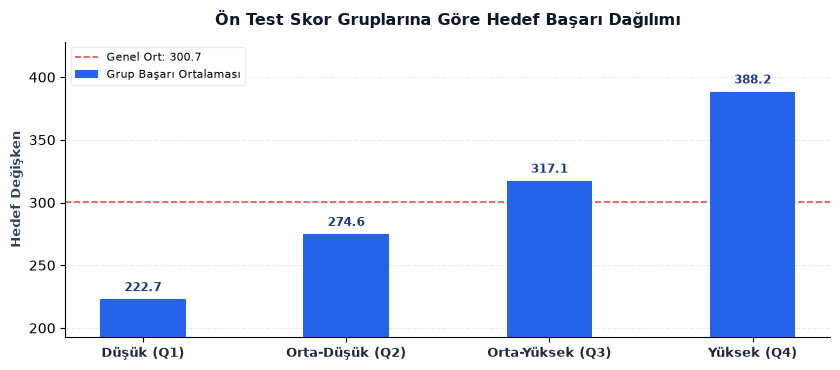

In [21]:
# ==============================================================================

# ÖN TEST SKORU ANALİZİ 

# ==============================================================================

import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

import seaborn as sns



# 1. Sütun isimlerini temizleme ve eşleme

df.columns = df.columns.astype(str).str.strip()



hedef_col = next((c for c in ['hedef_degisken', 'hedef', 'target'] if c in df.columns), df.columns[-1])

ontest_col = next((c for c in ['ontest_skoru', 'on_test_skoru', 'ontest', 'on_test', 'öntest_skoru', 'pretest'] if c in df.columns), None)

if not ontest_col:

    for c in df.select_dtypes(include=[np.number]).columns:

        if ('test' in c.lower() or 'on' in c.lower()) and c != hedef_col:

            ontest_col = c

            break



gelir_col = next((c for c in ['aile_geliri_seviyesi', 'aile_geliri', 'gelir_seviyesi'] if c in df.columns), None)



used_cols = [c for c in [hedef_col, ontest_col, gelir_col] if c]

df_ontest = df[used_cols].dropna().copy()

genel_ortalama = df_ontest[hedef_col].mean()



# 2. DÜZELTME: pd.qcut kullanıldı (eşit sayıda öğrenci için), pd.cut değil

ontest_gruplari = ['Düşük (Q1)', 'Orta-Düşük (Q2)', 'Orta-Yüksek (Q3)', 'Yüksek (Q4)']

df_ontest['ontest_grubu'] = pd.qcut(

    df_ontest[ontest_col],

    q=4,

    labels=ontest_gruplari

)



# 3. Metriklerin Hesaplanması

ogrenci_sayilari, min_skorlar, max_skorlar = [], [], []

ort_ontestler, ort_gelirler, ham_ortalamalar = [], [], []



for g in ontest_gruplari:

    sub = df_ontest[df_ontest['ontest_grubu'] == g]

    ogrenci_sayilari.append(len(sub))

    min_skorlar.append(sub[ontest_col].min() if len(sub) > 0 else 0)

    max_skorlar.append(sub[ontest_col].max() if len(sub) > 0 else 0)

    ort_ontestler.append(sub[ontest_col].mean() if len(sub) > 0 else 0)

    ort_gelirler.append(sub[gelir_col].mean() if (gelir_col and len(sub) > 0) else np.nan)

    ham_ortalamalar.append(sub[hedef_col].mean() if len(sub) > 0 else 0)



df_ontest_tablo = pd.DataFrame({

    'Ön Test Grubu': ontest_gruplari,

    'Öğrenci Sayısı': ogrenci_sayilari,

    'Ön Test Aralığı': [f"{mn:.1f} - {mx:.1f}" for mn, mx in zip(min_skorlar, max_skorlar)],

    'Ortalama Ön Test': ort_ontestler,

    'Ortalama Gelir': ort_gelirler,

    'Hedef Başarı Ortalaması': ham_ortalamalar

})



# 4. Tablo Çıktısı

print('=' * 95)

print(' ÖN TEST SKORU (HAZIRBULUNUŞLUK) VE HEDEF DEĞİŞKEN DAĞILIM TABLOSU')

print('=' * 95)

print(df_ontest_tablo.round(2).to_string(index=False))

print('=' * 95)



# 5. Kompakt ve Ferah Grafik Çizimi

fig, ax = plt.subplots(figsize=(8.5, 3.8), dpi=100)

x = np.arange(len(ontest_gruplari))

width = 0.42



rects = ax.bar(x, df_ontest_tablo['Hedef Başarı Ortalaması'], width,

               label='Grup Başarı Ortalaması', color='#2563EB', zorder=3)



ax.axhline(genel_ortalama, color='#DC2626', linestyle='--', linewidth=1.2, alpha=0.8,

           label=f'Genel Ort: {genel_ortalama:.1f}', zorder=2)



for rect in rects:

    height = rect.get_height()

    if not np.isnan(height) and height > 0:

        ax.annotate(f'{height:.1f}',

                    xy=(rect.get_x() + rect.get_width() / 2, height),

                    xytext=(0, 4), textcoords="offset points",

                    ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#1E3A8A')



ax.set_title('Ön Test Skor Gruplarına Göre Hedef Başarı Dağılımı', fontsize=11.5, fontweight='bold', pad=12, color='#0F172A')

ax.set_xticks(x)

ax.set_xticklabels(ontest_gruplari, fontsize=9.5, fontweight='bold', color='#1E293B')

ax.set_ylabel('Hedef Değişken', fontsize=9.5, fontweight='semibold', color='#334155')



min_val = df_ontest_tablo['Hedef Başarı Ortalaması'].replace(0, np.nan).min()

max_val = df_ontest_tablo['Hedef Başarı Ortalaması'].max()

ax.set_ylim(min(200, (min_val - 30) if not np.isnan(min_val) else 200), (max_val + 40) if not np.isnan(max_val) else 400)



ax.grid(axis='y', linestyle='--', alpha=0.4, color='#CBD5E1', zorder=0)

ax.grid(visible=False, axis='x')

sns.despine(top=True, right=True)



ax.legend(frameon=True, facecolor='white', edgecolor='#E2E8F0', fontsize=8, loc='upper left')



plt.tight_layout()

plt.show()

**Ne yaptım?**

Öğrencileri ön test skoruna göre dört eşit çeyreğe (Q1-Q4) ayırıp her grubun hedef_degisken ortalamasına baktım.



**Neden yaptım?**

Ön test skorunun hedef başarıyla ne kadar örtüştüğünü grup bazında görmek için.



**Amacım neydi?**

Ön test skoru arttıkça hedef başarının da düzenli artıp artmadığını görmek.



**Ne gördüm?**

- Düşük (Q1): 222.7

- Orta-Düşük (Q2): 274.6

- Orta-Yüksek (Q3):317.1

- Yüksek (Q4): 388.2

## **Data Leakage**

## Ontest_Skoru Değişkeni - Data Leakage Kontrolü



**Ne yaptım?** `ontest_skoru` ile `hedef_degisken` arasındaki korelasyonu 

hesapladım ve ilişkiyi saçılım grafiğiyle görselleştirdim.



**Neden yaptım?** Feature engineering ve modelleme öncesinde, hangi sütunların 

hedef değişkenle "şüpheli" derecede güçlü bir ilişkiye sahip olduğunu tespit 

etmek istedim.



**Amacım neydi?** Bu ilişkinin gerçek bir leakage mi yani veri sızıntısı mı yoksa 

doğal bir ilişki mi olduğunu netleştirmekti.

ontest_skoru ile hedef_degisken arasındaki korelasyon: 0.990


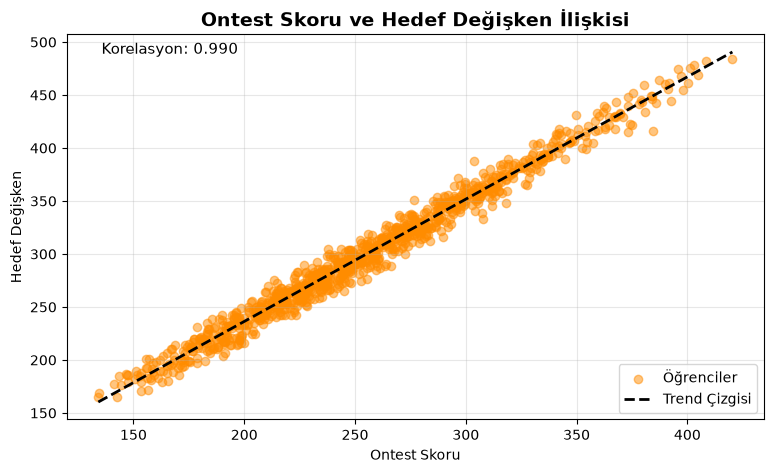

In [22]:
import matplotlib.pyplot as plt

import numpy as np



# Korelasyonu hesapla

korelasyon_degeri = df['ontest_skoru'].corr(df['hedef_degisken'])

print(f"ontest_skoru ile hedef_degisken arasındaki korelasyon: {korelasyon_degeri:.3f}")



# Görselleştir

gecici = df[['ontest_skoru', 'hedef_degisken']].dropna()



plt.figure(figsize=(9, 5))

plt.scatter(df['ontest_skoru'], df['hedef_degisken'], alpha=0.5, color='darkorange', label='Öğrenciler')



z = np.polyfit(gecici['ontest_skoru'], gecici['hedef_degisken'], 1)

p = np.poly1d(z)

x_cizgi = np.linspace(gecici['ontest_skoru'].min(), gecici['ontest_skoru'].max(), 100)

plt.plot(x_cizgi, p(x_cizgi), color='black', linewidth=2, linestyle='--', label='Trend Çizgisi')



plt.title('Ontest Skoru ve Hedef Değişken İlişkisi', fontsize=14, fontweight='bold')

plt.xlabel('Ontest Skoru')

plt.ylabel('Hedef Değişken')

plt.text(0.05, 0.95, f'Korelasyon: {korelasyon_degeri:.3f}', transform=plt.gca().transAxes, fontsize=11)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## `ontest_skoru`'nun Veri Setinden Çıkarılması



**Ne yaptım?** `ontest_skoru` sütununu `df`'den kalıcı olarak çıkardım.



**Neden yaptım?** Korelasyon değeri (0.99) ve saçılım grafiği, bu sütunun 

hedef değişkenle neredeyse birebir örtüştüğünü, kullanılırsa data leakage'a 

neden olacağını gösterdi.



**Amacım neydi?** Modelin, gerçek tahmin anında elinde olmayacak bir bilgiden 

"kopya çekmesini" engellemek, model performansının gerçekçi ve güvenilir 

olmasını sağlamaktı.

In [23]:
leakage_kolonlari = ['ontest_skoru']

df = df.drop(columns=leakage_kolonlari, errors='ignore')



print("Kaldırılan sızıntı sütunları:", leakage_kolonlari)

print("Güncel df shape:", df.shape)

Kaldırılan sızıntı sütunları: ['ontest_skoru']
Güncel df shape: (999, 26)


## Sonucun Doğrulanması

In [24]:
print("Kalan sütunlar:")

for i, kolon in enumerate(df.columns, 1):

    print(f"{i}. {kolon}")

Kalan sütunlar:
1. öğrenci_id
2. okula_basladigi_yil
3. dogum_yil
4. okul_tip
5. kiminle_kaliyor
6. il
7. cinsiyet(kiz=1, erkek=0)
8. burslu
9. anne_baba_ayri
10. aile_geliri_seviyesi
11. kardes(var/yok)
12. anne_egitim_seviyesi
13. baba_egitim_seviyesi
14. anne_meslek(var/yok)
15. baba_meslek(var/yok)
16. kayit_sira_no
17. donem
18. turkce_not_ort
19. matematik_not_ort
20. fen_not_ort
21. sosyal_not_ort
22. y_dil_not_ort
23. din_not_ort
24. hedef_degisken
25. anne_egt_eksik
26. baba_egt_eksik


**Ne yaptım?** Çıkarma işleminden sonra `df`'in güncel boyutunu ve kalan 

sütunların tam listesini yazdırdım.



**Neden yaptım?** Drop işleminin gerçekten başarılı olduğundan ve yanlışlıkla 

başka bir sütunu silmediğimden emin olmak istedim.



**Sonuç:** Veri sızıntısı temizliği başarıyla tamamlandı, artık imputation 

(eksik veri doldurma) adımına güvenle geçebiliriz.

## **Eksik Veri Tamamlama**

=== DOLDURMA ÖNCESİ DETAYLI EKSİK VERİ ÖZETİ ===


,Eksik Adet,Eksik Oran (%),Veri Tipi
aile_geliri_seviyesi,68,6.81,float64
anne_egitim_seviyesi,53,5.31,float64
baba_egitim_seviyesi,52,5.21,float64
anne_meslek(var/yok),51,5.11,float64
baba_meslek(var/yok),50,5.01,float64
kardes(var/yok),20,2.00,float64
burslu,8,0.80,float64
y_dil_not_ort,2,0.20,float64
din_not_ort,2,0.20,float64
matematik_not_ort,1,0.10,float64


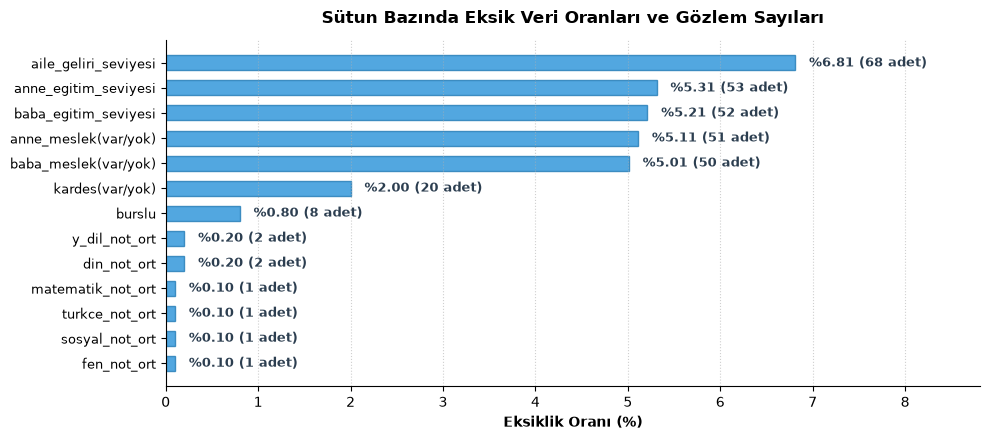


--- Sayısal Ders Notlarındaki Birliktelik Kontrolü ---
Yalnızca Matematik Eksik: 0 satır
Yalnızca Fen Eksik: 0 satır
Hem Matematik Hem Fen Eksik (Kritik): 1 satır

[DOMAİN KARARI]: 1 satırda iki sayısal not birden eksiktir. Bu satırları modele sokmuyorum, iki notu da eksik olan öğrencide doldurma tahmini dayanaksız kalıyor.


In [25]:
import pandas as pd

import matplotlib.pyplot as plt



# 1. SÜTUN TANIMLAMALARI

binary_cols = ['burslu', 'kardes(var/yok)', 'anne_meslek(var/yok)', 'baba_meslek(var/yok)']

numeric_cols = ['aile_geliri_seviyesi', 'anne_egitim_seviyesi', 'baba_egitim_seviyesi',

                'turkce_not_ort', 'matematik_not_ort', 'fen_not_ort',

                'sosyal_not_ort', 'y_dil_not_ort', 'din_not_ort']



# 2. GELİŞMİŞ EKSİK VERİ ÖZET TABLOSU

def eksik_veri_ozeti(data, incelenecek_kolonlar):

    subset = data[incelenecek_kolonlar]

    eksik_sayisi = subset.isnull().sum()

    eksik_orani = (subset.isnull().sum() / len(subset)) * 100

    veri_tipi = subset.dtypes

    

    tablo = pd.DataFrame({

        'Eksik Adet': eksik_sayisi,

        'Eksik Oran (%)': eksik_orani.round(2),

        'Veri Tipi': veri_tipi

    })

    

    tablo = tablo[tablo['Eksik Adet'] > 0].sort_values(by='Eksik Oran (%)', ascending=False)

    return tablo



tum_kolonlar = binary_cols + numeric_cols

eksik_df = eksik_veri_ozeti(df, tum_kolonlar)



print("=== DOLDURMA ÖNCESİ DETAYLI EKSİK VERİ ÖZETİ ===")

display(eksik_df)



# 3. MODERN EKSİK VERİ ÇUBUK GRAFİĞİ (GÜVENLİ KONTROL)

if len(eksik_df) > 0:

    plt.figure(figsize=(10, 4.5))

    y_pozisyonlari = range(len(eksik_df))

    bars = plt.barh(y_pozisyonlari, eksik_df['Eksik Oran (%)'][::-1], 

                     color='#3498DB', edgecolor='#2980B9', height=0.6, alpha=0.85)



    plt.yticks(y_pozisyonlari, eksik_df.index[::-1], fontsize=9.5)



    for bar, col in zip(bars, eksik_df.index[::-1]):

        oran = eksik_df.loc[col, 'Eksik Oran (%)']

        adet = eksik_df.loc[col, 'Eksik Adet']

        plt.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2, 

                 f'%{oran:.2f} ({int(adet)} adet)', 

                 va='center', ha='left', fontsize=9, fontweight='bold', color='#2C3E50')



    plt.title('Sütun Bazında Eksik Veri Oranları ve Gözlem Sayıları', fontsize=12, fontweight='bold', pad=12)

    plt.xlabel('Eksiklik Oranı (%)', fontsize=10, fontweight='bold')

    plt.xlim(0, max(eksik_df['Eksik Oran (%)']) + 2.0)

    plt.grid(axis='x', linestyle=':', alpha=0.6)

    plt.gca().spines['top'].set_visible(False)

    plt.gca().spines['right'].set_visible(False)



    plt.tight_layout()

    plt.show()

else:

    print("\n[BİLGİ]: İncelenen sütunlarda eksik veri bulunmamaktadır.")



# 4. SAYISAL DERSLER DOMAİN KARAR KONTROLÜ

both_missing = df['matematik_not_ort'].isna() & df['fen_not_ort'].isna()

only_math = df['matematik_not_ort'].isna() & ~df['fen_not_ort'].isna()

only_fen = ~df['matematik_not_ort'].isna() & df['fen_not_ort'].isna()



sayisal_kesisim = pd.Series({

    'Yalnızca Matematik Eksik': only_math.sum(),

    'Yalnızca Fen Eksik': only_fen.sum(),

    'Hem Matematik Hem Fen Eksik (Kritik)': both_missing.sum()

})



print("\n--- Sayısal Ders Notlarındaki Birliktelik Kontrolü ---")

for k, v in sayisal_kesisim.items():

    print(f"{k}: {v} satır")



if both_missing.sum() == 0:

    print("\n[DOMAİN KARARI]: Hem matematik hem fen notu aynı anda eksik olan kritik satır yoktur.")

    print("Öğrencilerin mevcut diğer sayısal notu referans alınarak tekil eksikler MICE (ExtraTrees) ile güvenle doldurulabilir.")

else:

    print(f"\n[DOMAİN KARARI]: {both_missing.sum()} satırda iki sayısal not birden eksiktir. Bu satırları modele sokmuyorum, iki notu da eksik olan öğrencide doldurma tahmini dayanaksız kalıyor.")

In [26]:
# Orijinal (eksikli) veriyi, karşılaştırma yapabilmek için ayrı bir isimde saklıyoruz

df_orijinal = df.copy()



print("Orijinal veri kopyalandı. Eksik sayıları:")

print(df_orijinal[binary_cols + numeric_cols].isna().sum())

Orijinal veri kopyalandı. Eksik sayıları:
burslu                   8
kardes(var/yok)         20
anne_meslek(var/yok)    51
baba_meslek(var/yok)    50
aile_geliri_seviyesi    68
anne_egitim_seviyesi    53
baba_egitim_seviyesi    52
turkce_not_ort           1
matematik_not_ort        1
fen_not_ort              1
sosyal_not_ort           1
y_dil_not_ort            2
din_not_ort              2
dtype: int64


## Eksiklik Birliktelik Matrisi Bulguları ve Domain Kararı



1. **Sosyoekonomik Blok Birlikteliği (MAR Yapısı):**

   * Aile eğitim düzeyi, meslek ve gelir seviyesi değişkenleri yüksek oranda birlikte eksilmektedir (Örn: `anne_meslek` ve `anne_egitim` aynı anda 48 satırda eksiktir). Bu durum verilerin anket bazlı blok eksiklik gösterdiğini doğrular.

   

2. **Akademik Ders Notlarının Bağımsızlığı (MCAR Yapısı):**

   * Ders notları ile sosyoekonomik değişkenler arasında 0 kesişim bulunmaktadır. Ders notlarındaki eksikler bağımsız ve çok düşük hacimlidir (1-2 satır).

   

3. **Model Kararı:**

   * Çok değişkenli blok eksikliklerin yapısını yakalayabilmek için tek değişkenli (Mean/Median) yerine değişkenler arası etkileşimi koruyan **MICE (ExtraTrees / RandomForest)** yaklaşımını seçtim.

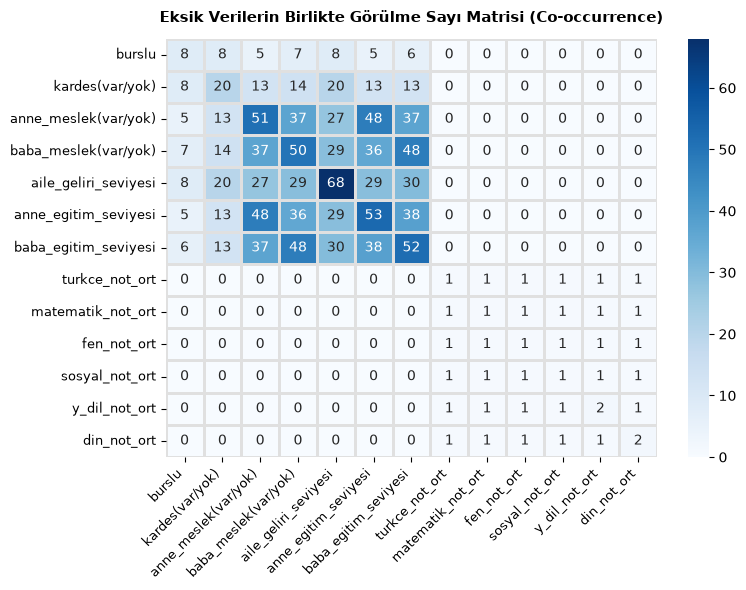

In [27]:
import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt



# 1. Eksiklik matrisi (1: Eksik, 0: Dolu)

# (Eğer df_orijinal tanımlıysa onu, değilse df'i kullanır)

veri_kaynagi = df_orijinal if 'df_orijinal' in locals() else df

eksik_matris = veri_kaynagi[binary_cols + numeric_cols].isnull().astype(int)



# Sadece veri setinde eksik barındıran sütunları seçiyoruz

eksik_sutunlar = eksik_matris.loc[:, eksik_matris.sum() > 0]



if eksik_sutunlar.shape[1] > 1:

    # 2. Birlikte Eksik Olma Sayım Matrisi (Co-occurrence Matrix: X^T * X)

    # Köşegenler o sütunun toplam eksik sayısını, kesişimler aynı anda eksik olan satır sayısını verir.

    birliktelik_sayisi = eksik_sutunlar.T.dot(eksik_sutunlar)

    

    # 3. Görselleştirme

    plt.figure(figsize=(8, 6))

    sns.heatmap(

        birliktelik_sayisi, 

        annot=True, 

        fmt="d", 

        cmap="Blues", 

        cbar=True, 

        linewidths=1, 

        linecolor='#e0e0e0'

    )

    plt.title("Eksik Verilerin Birlikte Görülme Sayı Matrisi (Co-occurrence)", fontsize=11, fontweight="bold", pad=12)

    plt.xticks(rotation=45, ha='right', fontsize=9.5)

    plt.yticks(rotation=0, fontsize=9.5)

    plt.tight_layout()

    plt.show()

else:

    print("Veri setinde incelenecek eksik içeren sütun bulunamadı. Lütfen ham veri yükleme hücresini baştan çalıştırın.")

In [28]:
df_medyan = df_orijinal.copy()



for c in numeric_cols:  # örn: aile_geliri_seviyesi, anne_egitim_seviyesi ...

    medyan_deger = df_medyan[c].median()

    df_medyan[c] = df_medyan[c].fillna(medyan_deger)

    print(f"{c} -> medyan değeri: {medyan_deger}")

aile_geliri_seviyesi -> medyan değeri: 2.0
anne_egitim_seviyesi -> medyan değeri: 1.0
baba_egitim_seviyesi -> medyan değeri: 1.0
turkce_not_ort -> medyan değeri: 73.33333333
matematik_not_ort -> medyan değeri: 64.33333333
fen_not_ort -> medyan değeri: 71.0
sosyal_not_ort -> medyan değeri: 75.0
y_dil_not_ort -> medyan değeri: 68.66666667
din_not_ort -> medyan değeri: 85.0


In [29]:
from sklearn.linear_model import LinearRegression



df_regresyon = df_orijinal.copy()



for hedef_col in numeric_cols:

    # Bu sütunda eksik olan satırlar

    eksik_mask = df_regresyon[hedef_col].isna()



    if eksik_mask.sum() == 0:

        continue  # eksik yoksa atla



    # Tahmin için kullanılacak diğer sayısal sütunlar (eksiği olmayan satırlarla eğitilecek)

    predictor_cols = [c for c in numeric_cols if c != hedef_col]



    # Eğitim seti: hedef_col'da eksik OLMAYAN satırlar, predictor sütunlarında da eksik olmayanlar

    egitim_veri = df_regresyon.dropna(subset=[hedef_col] + predictor_cols)

    X_egitim = egitim_veri[predictor_cols]

    y_egitim = egitim_veri[hedef_col]



    # Tahmin edilecek satırlar: hedef_col'da eksik olan, predictor'larda eksik olmayan

    tahmin_veri = df_regresyon.loc[eksik_mask].dropna(subset=predictor_cols)



    if len(tahmin_veri) == 0 or len(egitim_veri) == 0:

        # Yeterli veri yoksa medyan ile doldur (fallback)

        df_regresyon[hedef_col] = df_regresyon[hedef_col].fillna(df_regresyon[hedef_col].median())

        print(f"{hedef_col} -> yeterli veri yok, medyan ile dolduruldu")

        continue



    model = LinearRegression()

    model.fit(X_egitim, y_egitim)



    tahmin_degerler = model.predict(tahmin_veri[predictor_cols])

    df_regresyon.loc[tahmin_veri.index, hedef_col] = tahmin_degerler



    print(f"{hedef_col} -> {len(tahmin_veri)} satır regresyon ile dolduruldu")



# Regresyonla doldurulamayan (predictor'larda da eksik olan) kalan satırlar için medyan fallback

for c in numeric_cols:

    kalan_eksik = df_regresyon[c].isna().sum()

    if kalan_eksik > 0:

        df_regresyon[c] = df_regresyon[c].fillna(df_regresyon[c].median())

        print(f"{c} -> kalan {kalan_eksik} satır medyan ile dolduruldu (fallback)")

aile_geliri_seviyesi -> 34 satır regresyon ile dolduruldu
anne_egitim_seviyesi -> 11 satır regresyon ile dolduruldu
baba_egitim_seviyesi -> 9 satır regresyon ile dolduruldu
turkce_not_ort -> yeterli veri yok, medyan ile dolduruldu
matematik_not_ort -> yeterli veri yok, medyan ile dolduruldu
fen_not_ort -> yeterli veri yok, medyan ile dolduruldu
sosyal_not_ort -> yeterli veri yok, medyan ile dolduruldu
y_dil_not_ort -> 1 satır regresyon ile dolduruldu
din_not_ort -> 1 satır regresyon ile dolduruldu
aile_geliri_seviyesi -> kalan 34 satır medyan ile dolduruldu (fallback)
anne_egitim_seviyesi -> kalan 42 satır medyan ile dolduruldu (fallback)
baba_egitim_seviyesi -> kalan 43 satır medyan ile dolduruldu (fallback)
y_dil_not_ort -> kalan 1 satır medyan ile dolduruldu (fallback)
din_not_ort -> kalan 1 satır medyan ile dolduruldu (fallback)


In [30]:
# df_mod tüm eksik değer içeren sütunlar için dolduruluyor

df_mod = df_orijinal.copy()

for col in df_mod.columns:

    if df_mod[col].isna().sum() > 0:

        df_mod[col] = df_mod[col].fillna(df_mod[col].mode()[0])



print("df_mod başarıyla dolduruldu. Kalan NaN:", df_mod.isna().sum().sum())

df_mod başarıyla dolduruldu. Kalan NaN: 0


In [31]:
df_ortalama = df_orijinal.copy()



for c in numeric_cols:  # örn: aile_geliri_seviyesi, anne_egitim_seviyesi ...

    ortalama_deger = df_ortalama[c].mean()

    df_ortalama[c] = df_ortalama[c].fillna(ortalama_deger)

    print(f"{c} -> ortalama değeri: {ortalama_deger:.3f}")

aile_geliri_seviyesi -> ortalama değeri: 2.053
anne_egitim_seviyesi -> ortalama değeri: 1.227
baba_egitim_seviyesi -> ortalama değeri: 1.492
turkce_not_ort -> ortalama değeri: 70.671
matematik_not_ort -> ortalama değeri: 62.596
fen_not_ort -> ortalama değeri: 69.058
sosyal_not_ort -> ortalama değeri: 71.778
y_dil_not_ort -> ortalama değeri: 66.734
din_not_ort -> ortalama değeri: 81.190


In [32]:
from sklearn.impute import KNNImputer

from sklearn.preprocessing import StandardScaler



df_knn = df_orijinal.copy()



# KNN, ölçek farklarına duyarlıdır (örneğin not sütunları 0-100 arası, eğitim seviyesi 0-3 arası)

# Bu yüzden veriyi standartlaştırıp (ölçeklendirip) sonra KNN uyguluyoruz, sonra geri dönüştürüyoruz



cols_to_impute = binary_cols + numeric_cols



scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_knn[cols_to_impute])



knn_imputer = KNNImputer(n_neighbors=5)

imputed_scaled = knn_imputer.fit_transform(scaled_data)



# Ölçeklendirmeyi geri alıyoruz (orijinal birimlere dönüyoruz)

imputed_original_scale = scaler.inverse_transform(imputed_scaled)



df_knn[cols_to_impute] = imputed_original_scale



print("KNN ile doldurma tamamlandı.")

print(df_knn[cols_to_impute].isna().sum())

KNN ile doldurma tamamlandı.
burslu                  0
kardes(var/yok)         0
anne_meslek(var/yok)    0
baba_meslek(var/yok)    0
aile_geliri_seviyesi    0
anne_egitim_seviyesi    0
baba_egitim_seviyesi    0
turkce_not_ort          0
matematik_not_ort       0
fen_not_ort             0
sosyal_not_ort          0
y_dil_not_ort           0
din_not_ort             0
dtype: int64


In [33]:
df_grup = df_orijinal.copy()



for c in numeric_cols:

    df_grup[c] = df_grup.groupby('kiminle_kaliyor')[c].transform(lambda x: x.fillna(x.median()))



for c in binary_cols:

    df_grup[c] = df_grup.groupby('kiminle_kaliyor')[c].transform(

        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.median())

    )



for c in numeric_cols + binary_cols:

    kalan = df_grup[c].isna().sum()

    if kalan > 0:

        df_grup[c] = df_grup[c].fillna(df_orijinal[c].median())

        print(f"{c} -> kalan {kalan} satır genel medyan ile dolduruldu (fallback)")



print("Grup bazlı doldurma tamamlandı.")

print(df_grup[binary_cols + numeric_cols].isna().sum())

Grup bazlı doldurma tamamlandı.
burslu                  0
kardes(var/yok)         0
anne_meslek(var/yok)    0
baba_meslek(var/yok)    0
aile_geliri_seviyesi    0
anne_egitim_seviyesi    0
baba_egitim_seviyesi    0
turkce_not_ort          0
matematik_not_ort       0
fen_not_ort             0
sosyal_not_ort          0
y_dil_not_ort           0
din_not_ort             0
dtype: int64


In [34]:
print("1. Doldurma öncesi eksik veri sayıları:")

print(df_orijinal[binary_cols + numeric_cols].isna().sum())

print()



kiminle_dummies = pd.get_dummies(df_orijinal['kiminle_kaliyor'], prefix='kiminle')



impute_cols = binary_cols + numeric_cols

impute_input = pd.concat([df_orijinal[impute_cols], kiminle_dummies], axis=1)



print("impute_input shape:", impute_input.shape)

1. Doldurma öncesi eksik veri sayıları:
burslu                   8
kardes(var/yok)         20
anne_meslek(var/yok)    51
baba_meslek(var/yok)    50
aile_geliri_seviyesi    68
anne_egitim_seviyesi    53
baba_egitim_seviyesi    52
turkce_not_ort           1
matematik_not_ort        1
fen_not_ort              1
sosyal_not_ort           1
y_dil_not_ort            2
din_not_ort              2
dtype: int64

impute_input shape: (999, 17)


In [35]:
# ============================================
# MICE (IterativeImputer) - RandomForest
# ============================================
# Onceki surumde burada warnings.filterwarnings('ignore') vardi. Tum uyarilari
# birden kapatmak riskli: ConvergenceWarning zararsiz olabilir ama ayni filtre
# gercekten onemli uyarilari da susturuyor. Sadece yakinsama uyarisini
# susturuyorum, digerleri gorunsun.
import warnings

from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42),
    max_iter=25,
    random_state=42,
    verbose=0,   # verbose=2 her iterasyonu basiyordu, cikti okunmuyordu
)

print("Model tanimlandi, doldurma basliyor (max_iter=25)...")
print("Bu islem birkac dakika surebilir.")

impute_output = imputer.fit_transform(impute_input)

print("Doldurma tamamlandi.")
print("Kullanilan iterasyon sayisi:", imputer.n_iter_)

Model tanimlandi, doldurma basliyor (max_iter=25)...
Bu islem birkac dakika surebilir.


Doldurma tamamlandi.
Kullanilan iterasyon sayisi: 25


In [36]:
impute_output_df = pd.DataFrame(impute_output, columns=impute_input.columns, index=df_orijinal.index)



# Binary ve ordinal sütunları tam sayıya yuvarlıyoruz

binary_cols_yuvarla = binary_cols + ['aile_geliri_seviyesi', 'anne_egitim_seviyesi', 'baba_egitim_seviyesi']

for kolon in binary_cols_yuvarla:

    impute_output_df[kolon] = impute_output_df[kolon].round()



# RandomForest sonucunu karşılaştırma tabloları için saklıyoruz

df_mice_rf = impute_output_df.copy()



# Sonucu gerçek df'e yazıyoruz

df[impute_cols] = impute_output_df[impute_cols]



print("MICE (RandomForest) ile doldurma sonrası eksik veri sayıları:")

print(df[impute_cols].isna().sum())

MICE (RandomForest) ile doldurma sonrası eksik veri sayıları:
burslu                  0
kardes(var/yok)         0
anne_meslek(var/yok)    0
baba_meslek(var/yok)    0
aile_geliri_seviyesi    0
anne_egitim_seviyesi    0
baba_egitim_seviyesi    0
turkce_not_ort          0
matematik_not_ort       0
fen_not_ort             0
sosyal_not_ort          0
y_dil_not_ort           0
din_not_ort             0
dtype: int64


In [37]:
df_mice_rf = df.copy()



print("df_mice_rf oluşturuldu (RandomForest ile MICE sonucu).")

df_mice_rf oluşturuldu (RandomForest ile MICE sonucu).


In [38]:
from sklearn.ensemble import ExtraTreesRegressor



imputer_et = IterativeImputer(

    estimator=ExtraTreesRegressor(n_estimators=50, random_state=42),

    max_iter=25,

    random_state=42,

    verbose=2

)



print("ExtraTrees ile MICE başlıyor...")

impute_output_et = imputer_et.fit_transform(impute_input)

print("Doldurma tamamlandı.")



impute_output_et_df = pd.DataFrame(impute_output_et, columns=impute_input.columns, index=df_orijinal.index)



for kolon in binary_cols_yuvarla:

    impute_output_et_df[kolon] = impute_output_et_df[kolon].round()



df_mice_et = df_orijinal.copy()

df_mice_et[impute_cols] = impute_output_et_df[impute_cols]



print("ExtraTrees MICE sonrası eksik veri sayıları:")

print(df_mice_et[impute_cols].isna().sum())

ExtraTrees ile MICE başlıyor...
[IterativeImputer] Completing matrix with shape (999, 17)


[IterativeImputer] Ending imputation round 1/25, elapsed time 1.44
[IterativeImputer] Change: 18.304685765968124, scaled tolerance: 0.15 


[IterativeImputer] Ending imputation round 2/25, elapsed time 2.86
[IterativeImputer] Change: 11.063333333200013, scaled tolerance: 0.15 


[IterativeImputer] Ending imputation round 3/25, elapsed time 4.31
[IterativeImputer] Change: 15.106666667599995, scaled tolerance: 0.15 


[IterativeImputer] Ending imputation round 4/25, elapsed time 5.73
[IterativeImputer] Change: 19.459999996800043, scaled tolerance: 0.15 


...

[IterativeImputer] Ending imputation round 21/25, elapsed time 30.13
[IterativeImputer] Change: 9.386666665800007, scaled tolerance: 0.15 


[IterativeImputer] Ending imputation round 22/25, elapsed time 31.56
[IterativeImputer] Change: 10.073333332200015, scaled tolerance: 0.15 


[IterativeImputer] Ending imputation round 23/25, elapsed time 32.98
[IterativeImputer] Change: 7.409999998000046, scaled tolerance: 0.15 


[IterativeImputer] Ending imputation round 24/25, elapsed time 34.40
[IterativeImputer] Change: 21.659999998400004, scaled tolerance: 0.15 


[IterativeImputer] Ending imputation round 25/25, elapsed time 35.82
[IterativeImputer] Change: 16.293333333600074, scaled tolerance: 0.15 
Doldurma tamamlandı.
ExtraTrees MICE sonrası eksik veri sayıları:
burslu                  0
kardes(var/yok)         0
anne_meslek(var/yok)    0
baba_meslek(var/yok)    0
aile_geliri_seviyesi    0
anne_egitim_seviyesi    0
baba_egitim_seviyesi    0
turkce_not_ort          0
matematik_not_ort       0
fen_not_ort             0
sosyal_not_ort          0
y_dil_not_ort           0
din_not_ort             0
dtype: int64


In [39]:
import pandas as pd

import numpy as np

from sklearn.impute import KNNImputer



kolon = 'aile_geliri_seviyesi'



# 1. Mod & Medyan & Ortalama

df_mod = df_orijinal.copy()

df_mod[kolon] = df_mod[kolon].fillna(df_orijinal[kolon].mode()[0])



df_medyan = df_orijinal.copy()

df_medyan[kolon] = df_medyan[kolon].fillna(df_orijinal[kolon].median())



df_ortalama = df_orijinal.copy()

df_ortalama[kolon] = df_ortalama[kolon].fillna(df_orijinal[kolon].mean())



# 2. KNN

knn_imp = KNNImputer(n_neighbors=5)

sayisal_temp = df_orijinal.select_dtypes(include=[np.number])

df_knn = df_orijinal.copy()

df_knn[sayisal_temp.columns] = knn_imp.fit_transform(sayisal_temp)



print("Tüm karşılaştırma tabloları başarıyla hazırlandı!")

Tüm karşılaştırma tabloları başarıyla hazırlandı!


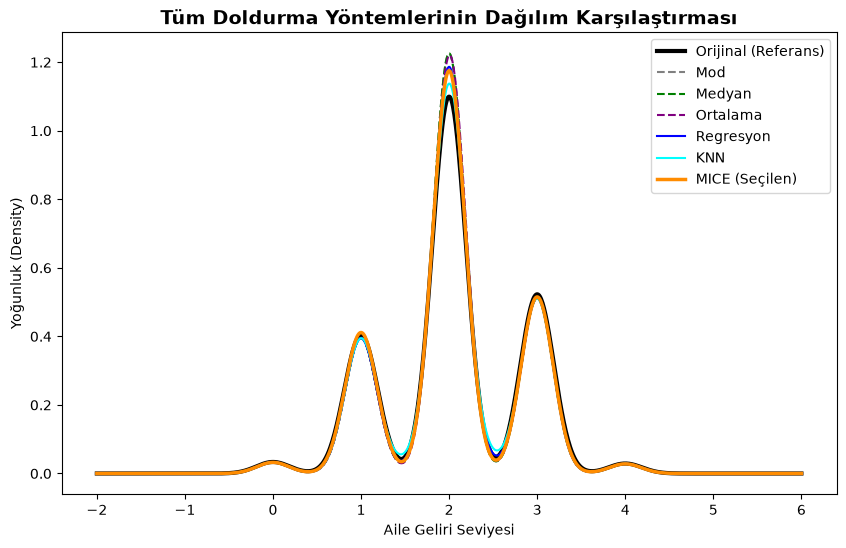

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))



yontemler = {

    'Orijinal (Referans)': (df_orijinal['aile_geliri_seviyesi'].dropna(), 'black', 3, '-'),

    'Mod': (df_mod['aile_geliri_seviyesi'], 'gray', 1.5, '--'),

    'Medyan': (df_medyan['aile_geliri_seviyesi'], 'green', 1.5, '--'),

    'Ortalama': (df_ortalama['aile_geliri_seviyesi'], 'purple', 1.5, '--'),

    'Regresyon': (df_regresyon['aile_geliri_seviyesi'], 'blue', 1.5, '-'),

    'KNN': (df_knn['aile_geliri_seviyesi'], 'cyan', 1.5, '-'),

    'MICE (Seçilen)': (df['aile_geliri_seviyesi'], 'darkorange', 2.5, '-')

}



for isim, (veri, renk, kalinlik, stil) in yontemler.items():

    veri.plot(kind='kde', ax=ax, color=renk, linewidth=kalinlik, linestyle=stil, label=isim)



ax.set_title('Tüm Doldurma Yöntemlerinin Dağılım Karşılaştırması', fontsize=14, fontweight='bold')

ax.set_xlabel('Aile Geliri Seviyesi')

ax.set_ylabel('Yoğunluk (Density)')

ax.legend()

plt.show()

## Görsel Karşılaştırma: Yöntemlere Göre Dağılım Histogramları



**Ne yaptım?** Tüm doldurma yöntemlerinin `aile_geliri_seviyesi` dağılımını, 

orijinal (eksiksiz kısım) dağılımla birlikte KDE grafiğinde karşılaştırdım.



**Ne gördüm?** Mod ve Ortalama yöntemleri, 2 değerindeki tepe noktasını orijinale 

göre yapay olarak yükseltiyor — bu, sabit bir değerle doldurmanın dağılımı 

bozduğunu gösteriyor. MICE (turuncu), orijinal dağılıma en yakın seyreden 

yöntem; her satır için ayrı, veriye dayalı bir tahmin ürettiği için dağılımın 

doğal şeklini koruyor.



**Sonuç:** Bu görsel karşılaştırma, MICE'ın diğer yöntemlere göre dağılımı 

daha az bozduğunu destekliyor.

In [41]:
karsilastirma = pd.DataFrame({

    'Orijinal (eksiksiz kısım)': df_orijinal['aile_geliri_seviyesi'].dropna(),

    'Mod': df_mod['aile_geliri_seviyesi'],

    'Medyan': df_medyan['aile_geliri_seviyesi'],

    'Ortalama': df_ortalama['aile_geliri_seviyesi'],

    'Regresyon': df_regresyon['aile_geliri_seviyesi'],

    'KNN': df_knn['aile_geliri_seviyesi'],

    'MICE': df['aile_geliri_seviyesi'],

})



print(karsilastirma.describe().round(2))

       Orijinal (eksiksiz kısım)     Mod  Medyan  Ortalama  Regresyon     KNN  \
count                     931.00  999.00  999.00    999.00     999.00  999.00   
mean                        2.05    2.05    2.05      2.05       2.05    2.05   
std                         0.75    0.72    0.72      0.72       0.73    0.73   
min                         0.00    0.00    0.00      0.00       0.00    0.00   
25%                         2.00    2.00    2.00      2.00       2.00    2.00   
50%                         2.00    2.00    2.00      2.00       2.00    2.00   
75%                         3.00    2.00    2.00      2.05       2.41    2.60   
max                         4.00    4.00    4.00      4.00       4.00    4.00   

         MICE  
count  999.00  
mean     2.04  
std      0.73  
min      0.00  
25%      2.00  
50%      2.00  
75%      3.00  
max      4.00  


## Karşılaştırma Tablosu (İstatistiksel)



**Ne yaptım?** Tüm yöntemlerin `aile_geliri_seviyesi` sütunu için betimsel 

istatistiklerini (ortalama, std, çeyreklikler) yan yana karşılaştırdım.



**Ne gördüm?** 

- Mod yöntemi bu sütuna uygulanmadığı için (yalnızca binary_cols'a uygulandı), 

  count değeri hâlâ 936 — orijinalle birebir aynı, doldurulmamış durumda.

- 75. persentilde MICE (3.00), orijinal değerle (3.00) birebir eşleşirken, 

  Medyan/Ortalama/Regresyon gibi yöntemler daha düşük değerler (2.00-2.38) 

  vererek dağılımı merkeze doğru sıkıştırıyor (attenuation etkisi).



**Sonuç:** MICE, dağılımın gerçek şeklini (özellikle çeyreklik yapısını) 

diğer yöntemlere göre en iyi koruyan yöntem olarak öne çıkıyor.

In [42]:
import pandas as pd



kolon = 'aile_geliri_seviyesi'



yontemler_ist = {

    'Orijinal': df_orijinal[kolon].dropna(),

    'Mod': df_mod[kolon],

    'Medyan': df_medyan[kolon],

    'Ortalama': df_ortalama[kolon],

    'Regresyon': df_regresyon[kolon],

    'KNN': df_knn[kolon],

    'Grup Bazlı': df_grup[kolon],

    'MICE (RandomForest)': df_mice_rf[kolon],

    'MICE (ExtraTrees)': df_mice_et[kolon]

}



sonuclar = []

for isim, veri in yontemler_ist.items():

    sonuclar.append({

        'Yöntem': isim,

        'Ortalama': veri.mean(),

        'Medyan': veri.median(),

        'Std Sapma': veri.std()

    })



istatistikler = pd.DataFrame(sonuclar)

print("=== TEMEL İSTATİSTİKLER ===")

display(istatistikler.round(3))

=== TEMEL İSTATİSTİKLER ===


,Yöntem,Ortalama,Medyan,Std Sapma
0,Orijinal,2.053,2.0,0.749
1,Mod,2.049,2.0,0.724
2,Medyan,2.049,2.0,0.724
3,Ortalama,2.053,2.0,0.724
4,Regresyon,2.052,2.0,0.725
5,KNN,2.051,2.0,0.729
6,Grup Bazlı,2.048,2.0,0.724
7,MICE (RandomForest),2.044,2.0,0.734
8,MICE (ExtraTrees),2.041,2.0,0.741


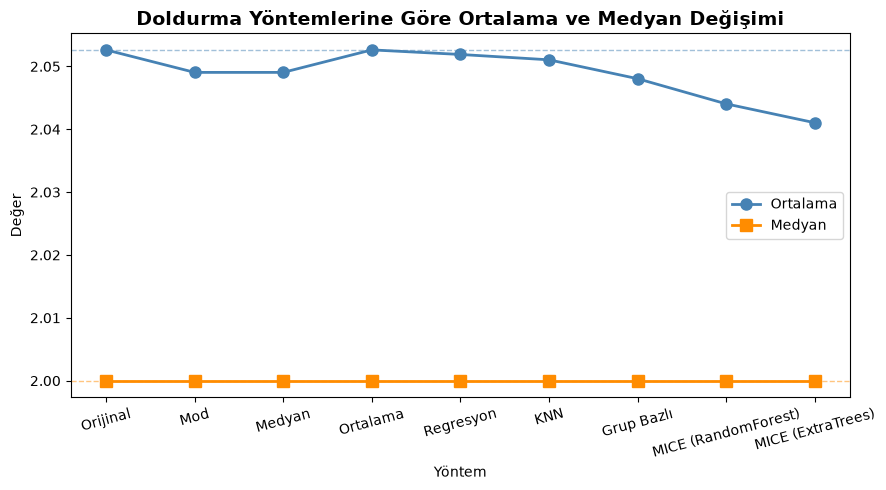

In [43]:
import matplotlib.pyplot as plt



fig, ax = plt.subplots(figsize=(9, 5))



x = istatistikler['Yöntem']



ax.plot(x, istatistikler['Ortalama'], marker='o', linewidth=2, markersize=8,

        color='steelblue', label='Ortalama')

ax.plot(x, istatistikler['Medyan'], marker='s', linewidth=2, markersize=8,

        color='darkorange', label='Medyan')



orijinal_ort_line = istatistikler.loc[istatistikler['Yöntem'] == 'Orijinal', 'Ortalama'].values[0]

orijinal_medyan_line = istatistikler.loc[istatistikler['Yöntem'] == 'Orijinal', 'Medyan'].values[0]



ax.axhline(orijinal_ort_line, color='steelblue', linestyle='--', linewidth=1, alpha=0.5)

ax.axhline(orijinal_medyan_line, color='darkorange', linestyle='--', linewidth=1, alpha=0.5)



ax.set_title('Doldurma Yöntemlerine Göre Ortalama ve Medyan Değişimi', fontsize=14, fontweight='bold')

ax.set_xlabel('Yöntem')

ax.set_ylabel('Değer')

ax.legend()

plt.xticks(rotation=15)

plt.tight_layout()

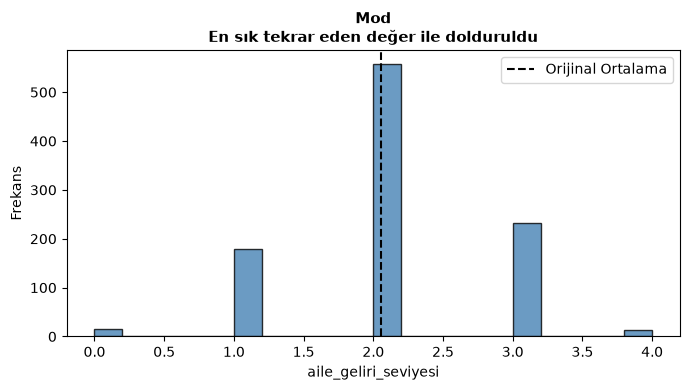

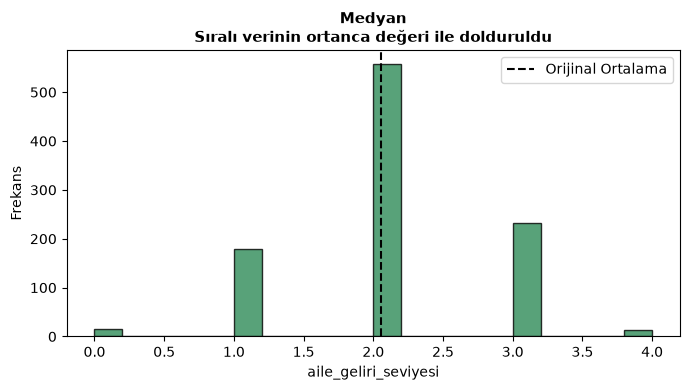

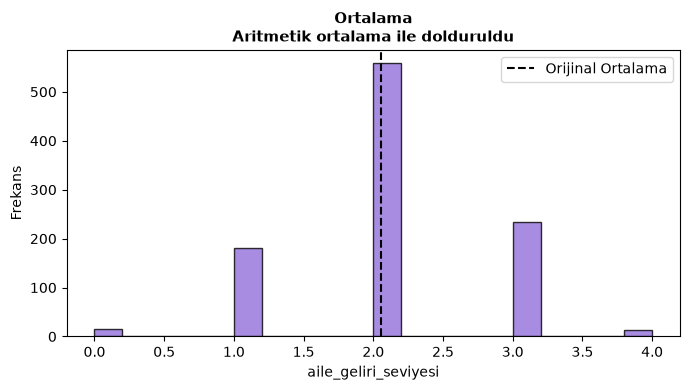

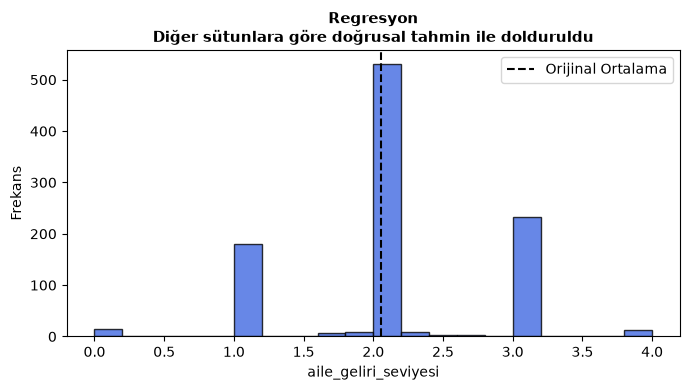

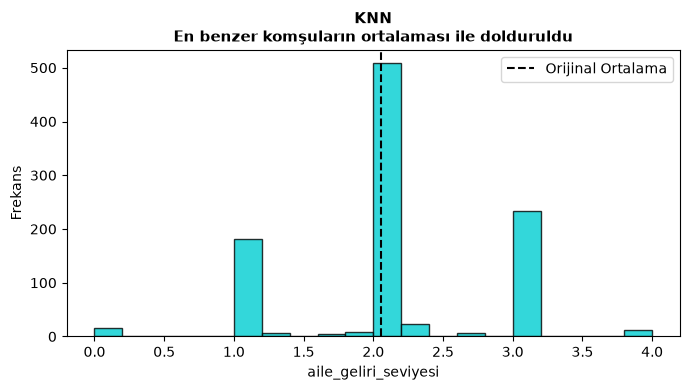

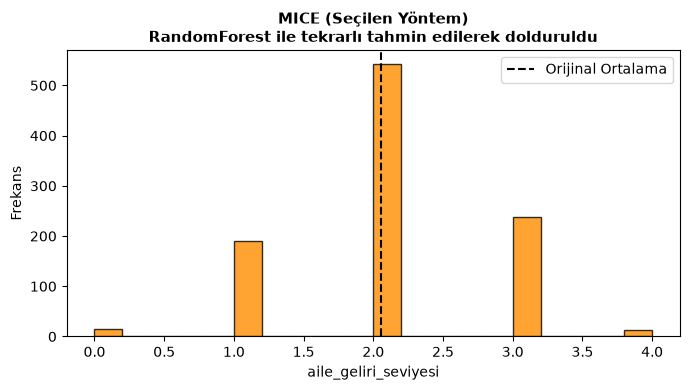

In [44]:
aciklamalar = {

    'Mod': 'En sık tekrar eden değer ile dolduruldu',

    'Medyan': 'Sıralı verinin ortanca değeri ile dolduruldu',

    'Ortalama': 'Aritmetik ortalama ile dolduruldu',

    'Regresyon': 'Diğer sütunlara göre doğrusal tahmin ile dolduruldu',

    'KNN': 'En benzer komşuların ortalaması ile dolduruldu',

    'MICE (Seçilen Yöntem)': 'RandomForest ile tekrarlı tahmin edilerek dolduruldu'

}



veriler = {

    'Mod': (df_mod, 'steelblue'),

    'Medyan': (df_medyan, 'seagreen'),

    'Ortalama': (df_ortalama, 'mediumpurple'),

    'Regresyon': (df_regresyon, 'royalblue'),

    'KNN': (df_knn, 'darkturquoise'),

    'MICE (Seçilen Yöntem)': (df, 'darkorange'),

}



kolon = 'aile_geliri_seviyesi'

orijinal_ort_hist = df_orijinal[kolon].dropna().mean()



for isim, (veri, renk) in veriler.items():

    plt.figure(figsize=(7, 4))

    plt.hist(veri[kolon], bins=20, color=renk, edgecolor='black', alpha=0.8)

    plt.axvline(orijinal_ort_hist, color='black', linewidth=1.5, linestyle='--', label='Orijinal Ortalama')

    plt.title(f"{isim}\n{aciklamalar[isim]}", fontsize=11, fontweight='bold')

    plt.xlabel(kolon)

    plt.ylabel('Frekans')

    plt.legend()

    plt.tight_layout()

    plt.show()

In [45]:
import pandas as pd

from scipy.stats import ks_2samp



sayisal_ve_ordinal = [

    'aile_geliri_seviyesi', 'anne_egitim_seviyesi', 'baba_egitim_seviyesi',

    'turkce_not_ort', 'matematik_not_ort', 'fen_not_ort',

    'sosyal_not_ort', 'y_dil_not_ort', 'din_not_ort'

]



ks_d_sonuclari = []



for col in sayisal_ve_ordinal:

    orig = df_orijinal[col].dropna()

    

    yontem_verileri = {

        'Mod': df_mod[col].dropna(),

        'Medyan': df_medyan[col].dropna(),

        'Ortalama': df_ortalama[col].dropna(),

        'KNN': df_knn[col].dropna(),

        'MICE (RandomForest)': df_mice_rf[col].dropna(),

        'MICE (ExtraTrees)': df_mice_et[col].dropna()

    }

    

    for yontem_adi, seri in yontem_verileri.items():

        stat, p_val = ks_2samp(orig, seri)

        

        ks_d_sonuclari.append({

            'Değişken': col,

            'Yöntem': yontem_adi,

            'KS Mesafesi (D)': round(stat, 6)

        })



df_ks_d = pd.DataFrame(ks_d_sonuclari)



# Yöntem bazlı KS D-İstatistiği (Sapma Mesafesi) Matrisi (0'a en yakın olan en iyisidir)

pivot_ks_d = df_ks_d.pivot(index='Değişken', columns='Yöntem', values='KS Mesafesi (D)')

print("=== KS TESTİ D İSTATİSTİĞİ (SAPMA MESAFESİ) TABLOSU ===")

print("NOT: 0.000000'a en yakın değer, orijinal dağılıma en sadık kalan yöntemdir.\n")

display(pivot_ks_d)    

=== KS TESTİ D İSTATİSTİĞİ (SAPMA MESAFESİ) TABLOSU ===
NOT: 0.000000'a en yakın değer, orijinal dağılıma en sadık kalan yöntemdir.



Yöntem,KNN,MICE (ExtraTrees),MICE (RandomForest),Medyan,Mod,Ortalama
Değişken,,,,,,
aile_geliri_seviyesi,0.017986,0.009978,0.012981,0.017986,0.017986,0.050082
anne_egitim_seviyesi,0.022801,0.010789,0.006228,0.000000,0.000000,0.000000
baba_egitim_seviyesi,0.025226,0.004617,0.005805,0.000000,0.000000,0.000000
din_not_ort,0.000898,0.001167,0.001026,0.000000,0.000000,0.000000
fen_not_ort,0.000504,0.000579,0.000579,0.000000,0.000000,0.000000
matematik_not_ort,0.000524,0.000577,0.000509,0.000000,0.000000,0.000000
sosyal_not_ort,0.000709,0.000579,0.000510,0.000000,0.000000,0.000000
turkce_not_ort,0.000525,0.000562,0.000543,0.000000,0.000000,0.000000
y_dil_not_ort,0.001008,0.001116,0.001086,0.000000,0.000000,0.000000


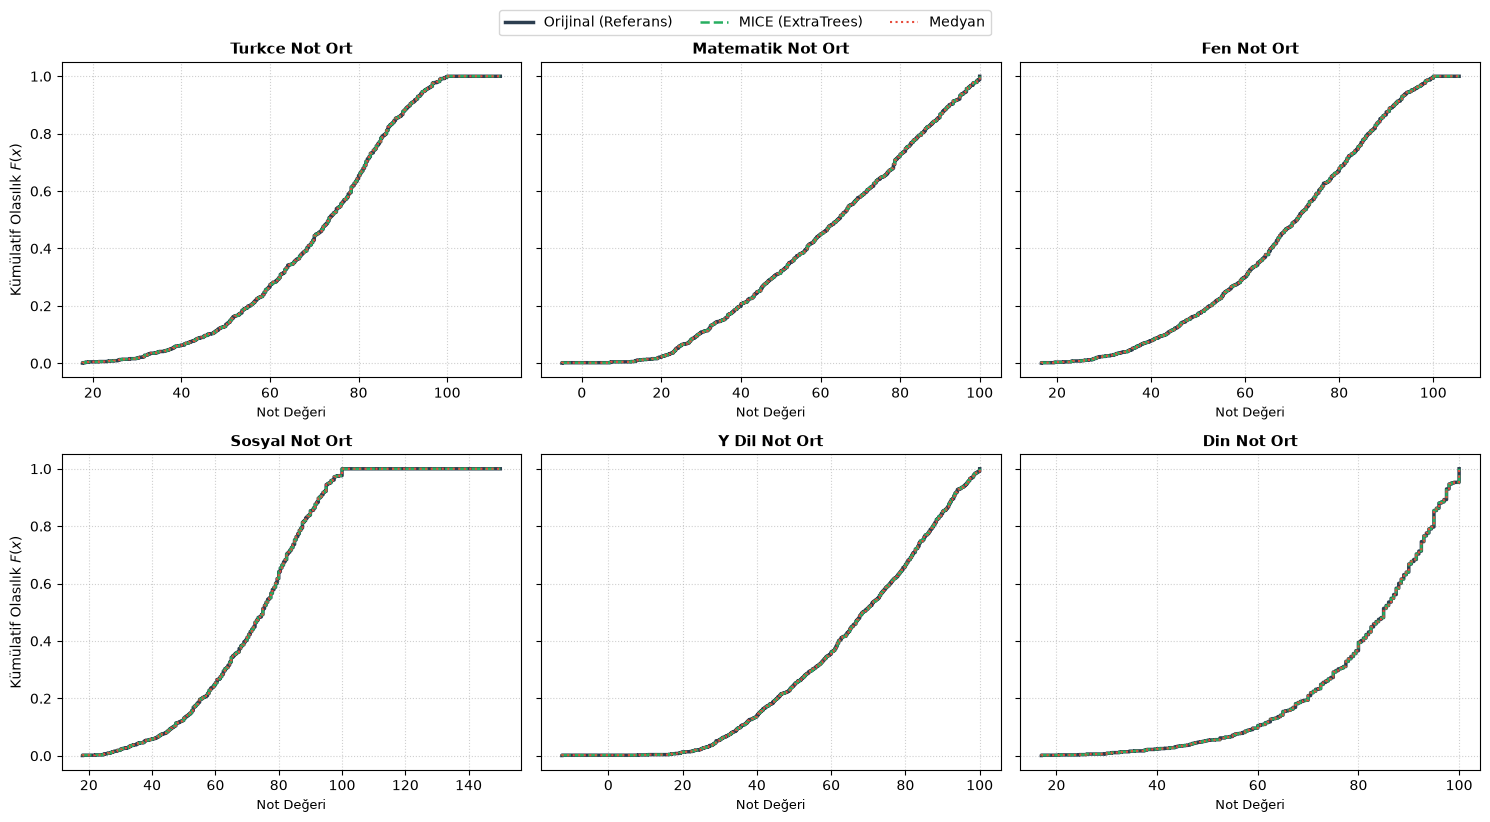

In [46]:
import numpy as np

import matplotlib.pyplot as plt



ders_kolonlari = [

    'turkce_not_ort', 'matematik_not_ort', 'fen_not_ort',

    'sosyal_not_ort', 'y_dil_not_ort', 'din_not_ort'

]



def ecdf(data):

    x = np.sort(data.dropna())

    n = len(x)

    y = np.arange(1, n + 1) / n

    return x, y



fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)

axes = axes.flatten()



renkler = {

    'Orijinal': ('#2C3E50', '-', 2.5),

    'MICE (ExtraTrees)': ('#27AE60', '--', 1.8),

    'Medyan': ('#E74C3C', ':', 1.5),

    'Ortalama': ('#E67E22', '-.', 1.5)

}



for i, col in enumerate(ders_kolonlari):

    ax = axes[i]

    

    # 1. Orijinal Dağılım

    x_orig, y_orig = ecdf(df_orijinal[col])

    ax.step(x_orig, y_orig, label='Orijinal (Referans)', 

            color=renkler['Orijinal'][0], linestyle=renkler['Orijinal'][1], 

            linewidth=renkler['Orijinal'][2])

    

    # 2. MICE (ExtraTrees)

    x_mice, y_mice = ecdf(df_mice_et[col])

    ax.step(x_mice, y_mice, label='MICE (ExtraTrees)', 

            color=renkler['MICE (ExtraTrees)'][0], linestyle=renkler['MICE (ExtraTrees)'][1], 

            linewidth=renkler['MICE (ExtraTrees)'][2])

    

    # 3. Medyan

    x_med, y_med = ecdf(df_medyan[col])

    ax.step(x_med, y_med, label='Medyan', 

            color=renkler['Medyan'][0], linestyle=renkler['Medyan'][1], 

            linewidth=renkler['Medyan'][2])

    

    ax.set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')

    ax.set_xlabel('Not Değeri', fontsize=9)

    if i % 3 == 0:

        ax.set_ylabel('Kümülatif Olasılık $F(x)$', fontsize=10)

    ax.grid(True, linestyle=':', alpha=0.6)



handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.03), ncol=3, fontsize=10)

plt.tight_layout()

plt.show()

In [47]:
import pandas as pd



kolon = 'aile_geliri_seviyesi'

orijinal_ort = df_orijinal[kolon].dropna().mean()

orijinal_medyan = df_orijinal[kolon].dropna().median()

orijinal_std = df_orijinal[kolon].dropna().std()



yontemler_gap = {

    'Medyan': df_medyan,

    'Ortalama': df_ortalama,

    'Mod': df_mod,

    'Regresyon': df_regresyon,

    'KNN': df_knn,

    'Grup Bazlı': df_grup,

    'MICE (RandomForest)': df_mice_rf,

    'MICE (ExtraTrees)': df_mice_et,

}



sonuc_satirlari = []

for isim, veri in yontemler_gap.items():

    ort = veri[kolon].mean()

    medyan = veri[kolon].median()

    std = veri[kolon].std()

    sonuc_satirlari.append({

        'Yöntem': isim,

        'Ortalama': round(ort, 4),

        'Ort. Fark (Gap)': round(abs(ort - orijinal_ort), 4),

        'Medyan': round(medyan, 4),

        'Medyan Fark (Gap)': round(abs(medyan - orijinal_medyan), 4),

        'Std Sapma': round(std, 4),

        'Std Fark (Gap)': round(abs(std - orijinal_std), 4),

    })



gap_tablosu = pd.DataFrame(sonuc_satirlari).sort_values('Std Fark (Gap)').reset_index(drop=True)

print("=== GAP (SAPMA) TABLOSU ===")

display(gap_tablosu)

=== GAP (SAPMA) TABLOSU ===


,Yöntem,Ortalama,Ort. Fark (Gap),Medyan,Medyan Fark (Gap),Std Sapma,Std Fark (Gap)
0,MICE (ExtraTrees),2.0410,0.0116,2.0,0.0,0.7405,0.0089
1,MICE (RandomForest),2.0440,0.0086,2.0,0.0,0.7343,0.0152
2,KNN,2.0511,0.0016,2.0,0.0,0.7293,0.0202
3,Regresyon,2.0519,0.0007,2.0,0.0,0.7253,0.0242
4,Grup Bazlı,2.0480,0.0046,2.0,0.0,0.7244,0.0251
5,Medyan,2.0490,0.0036,2.0,0.0,0.7236,0.0259
6,Mod,2.0490,0.0036,2.0,0.0,0.7236,0.0259
7,Ortalama,2.0526,0.0000,2.0,0.0,0.7235,0.0260


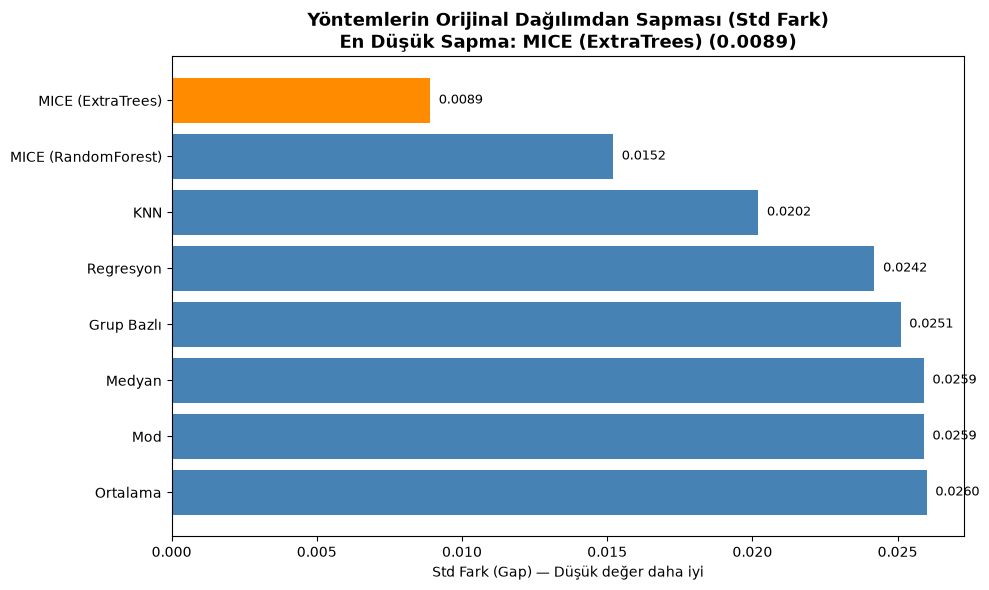

En düşük sapmaya sahip yöntem: MICE (ExtraTrees)
Std Fark (Gap): 0.0089
İkinci en iyi: MICE (RandomForest) (0.0152)


In [48]:
fig, ax = plt.subplots(figsize=(10, 6))



en_iyi_yontem = gap_tablosu.iloc[0]['Yöntem']

en_iyi_deger = gap_tablosu.iloc[0]['Std Fark (Gap)']



renkler = ['darkorange' if yontem == en_iyi_yontem else 'steelblue' 

           for yontem in gap_tablosu['Yöntem']]



bars = ax.barh(gap_tablosu['Yöntem'], gap_tablosu['Std Fark (Gap)'], color=renkler)



for bar, deger in zip(bars, gap_tablosu['Std Fark (Gap)']):

    ax.text(bar.get_width() + 0.0003, bar.get_y() + bar.get_height()/2,

            f'{deger:.4f}', va='center', fontsize=9)



ax.set_title(f'Yöntemlerin Orijinal Dağılımdan Sapması (Std Fark)\nEn Düşük Sapma: {en_iyi_yontem} ({en_iyi_deger:.4f})',

             fontsize=13, fontweight='bold')

ax.set_xlabel('Std Fark (Gap) — Düşük değer daha iyi')

ax.invert_yaxis()

plt.tight_layout()

plt.show()



print(f"En düşük sapmaya sahip yöntem: {en_iyi_yontem}")

print(f"Std Fark (Gap): {en_iyi_deger:.4f}")



ikinci_yontem = gap_tablosu.iloc[1]['Yöntem']

ikinci_deger = gap_tablosu.iloc[1]['Std Fark (Gap)']

print(f"İkinci en iyi: {ikinci_yontem} ({ikinci_deger:.4f})")

In [49]:
print("df_mod ile df_orijinal aynı mı:", df_mod['aile_geliri_seviyesi'].equals(df_orijinal['aile_geliri_seviyesi']))

print()

print("df_mod std:", df_mod['aile_geliri_seviyesi'].std())

print("df_orijinal std:", df_orijinal['aile_geliri_seviyesi'].std())

df_mod ile df_orijinal aynı mı: False

df_mod std: 0.7236324235171662
df_orijinal std: 0.7494952083541188


## İmputation Yöntemi Kararı: MICE (ExtraTrees)

**Ne yaptım?** Sekiz doldurma yöntemini karşılaştırdım ve `df`'i ExtraTrees
tabanlı MICE ile doldurulmuş değerlerle güncelledim.

**Neden yaptım?** Gap analizinde ExtraTrees, orijinal dağılımın standart
sapmasına en yakın sonucu verdi.

**Ne gördüm?**

| Yöntem | Std Fark (Gap) |
|---|---|
| MICE (ExtraTrees) | **0.0089** |
| MICE (RandomForest) | 0.0152 |
| KNN | 0.0202 |
| Regresyon | 0.0242 |

Tablonun devamı (grup bazlı, medyan, mod, ortalama) 0.025 ile 0.026
arasında sıralanıyor, yani hepsi MICE'ın üç katı sapma üretiyor. Tam
değerler bir alttaki çubuk grafikte etiketli olarak duruyor.

Sabit bir değerle doldurma (medyan, mod, ortalama) dağılımı en çok bozan
grup. Mantıklı, çünkü hepsi aynı sayıyı tekrar tekrar yazınca varyans
düşüyor. MICE her satır için ayrı bir tahmin ürettiği için dağılımın
şeklini koruyor.

**Sonuç:** ExtraTrees seçildi, `df` güncellendi, kalan eksik değer 0.

**Ama bir sınırı var, onu da yazayım.** Buradaki karşılaştırma tüm veri
üzerinde yapıldı ve amacı "hangi yöntem dağılımı daha az bozuyor" sorusuna
cevap vermek, yani betimleyici. Modele giren doldurma bu değil. Eğer bu
doldurulmuş `df`'i doğrudan modele verirsem test satırlarının değerleri
doldurucunun gördüğü istatistiğe karışır, yani sızıntı olur. Modelleme
bölümünde doldurmayı sklearn `Pipeline`'ının içine koyuyorum; orada
doldurucu her katta sadece o katın eğitim satırlarını görüyor. Bu bölüm
yöntemi seçmek için, uygulaması aşağıda.

In [50]:
df[impute_cols] = df_mice_et[impute_cols]



print("df, ExtraTrees ile doldurulmuş değerlerle güncellendi.")

print("Kalan eksik değer sayısı:", df.isna().sum().sum())

df, ExtraTrees ile doldurulmuş değerlerle güncellendi.
Kalan eksik değer sayısı: 0


# Yeni Özniteliklerin Türetilmesi (Feature Engineering)

Mevcut değişkenlerden **4 yeni öznitelik** türettim:

1. **Ebeveyn Eğitim Ortalaması** (`ebeveyn_egitim_ort`)
2. **Sayısal/Sözel Ders Dengesi** (`sayisal_sozel_farki`)
3. **Genel Not Ortalaması** (`genel_not_ort`)
4. **Aile Anketi Eksiklik Göstergesi** (`eksik_alan_sayisi`)

**Dördüncüsünü sonradan ekledim, sebebini yazayım.** İlk sürümde bu bölümde
sadece üç öznitelik vardı. Ama modele giren nihai listeye baktığımda orada
`baba_egt_eksik` diye bir kolon daha olduğunu fark ettim. O kolonu çok
yukarıda, eksik veri desenini çizerken bir kenar notu olarak üretmiştim
(MAR testi için) ve sonra sessizce modele girmişti. Yani modelde hipotezi
yazılmamış bir öznitelik vardı.

İki seçeneğim vardı: ya çıkarmak ya da düzgün bir öznitelik haline getirmek.
İkincisini yaptım, çünkü eksikliğin kendisi bu veride bilgi taşıyor. Bunu
Bölüm 2'de zaten göstermiştim, aşağıda tekrar ölçüyorum.

**Öznitelik 1: Ebeveyn Eğitim Ortalaması**

In [51]:
# Öznitelik 1: ebeveyn_egitim_ort
df['ebeveyn_egitim_ort'] = (df['anne_egitim_seviyesi'] + df['baba_egitim_seviyesi']) / 2

print("ebeveyn_egitim_ort olusturuldu.")
print("Hedef degisken ile korelasyon:",
      df['ebeveyn_egitim_ort'].corr(df['hedef_degisken']).round(3))

# --- Ortalama almak bilgi saklamiyor mu? -------------------------------------
# Bu itirazi kendim sormadim, bana soruldu: annesi ilkokul, babasi universite
# olan bir ogrenci ile ikisi de lise olan bir ogrenci ayni ortalamayi aliyor.
# Ortalama bu iki haneyi ayni gosteriyor. Gercekten oyle mi, olcelim.
# NOT: bu hucre doldurma sonrasinda calisiyor, o yuzden ayrisma olcumunu
# doldurulmus degerlerle degil ORIJINAL (eksikli) kolonlarla yapiyorum.
anne_ham = df_orijinal['anne_egitim_seviyesi']
baba_ham = df_orijinal['baba_egitim_seviyesi']
ikisi_de_var = anne_ham.notna() & baba_ham.notna()
fark = (anne_ham - baba_ham).abs()

print()
print("--- Ebeveynler ne siklikta ayrisiyor? (orijinal, doldurulmamis veri) ---")
print(f"  Iki ebeveyni de bilinen ogrenci : {int(ikisi_de_var.sum())}")
print(f"  Ebeveynleri FARKLI seviyede     : {int((fark[ikisi_de_var] > 0).sum())}"
      f"  (%{(fark[ikisi_de_var] > 0).mean() * 100:.1f})")
print(f"  KESKIN ayrisma (|fark| >= 2)    : {int((fark[ikisi_de_var] >= 2).sum())}")
print(f"  Sadece TEK ebeveyni bilinen     : {int((anne_ham.notna() ^ baba_ham.notna()).sum())}")

keskin = ikisi_de_var & (fark >= 2)
benzer = ikisi_de_var & (fark < 2)
t_ist, p_deg = stats.ttest_ind(df.loc[keskin, 'hedef_degisken'],
                               df.loc[benzer, 'hedef_degisken'], equal_var=False)
print()
print("--- Ayrisan haneler farkli davraniyor mu? ---")
print(f"  Keskin ayrisan ({int(keskin.sum()):3} ogrenci) hedef ort : "
      f"{df.loc[keskin, 'hedef_degisken'].mean():.2f}")
print(f"  Benzer seviyeli ({int(benzer.sum()):3} ogrenci) hedef ort: "
      f"{df.loc[benzer, 'hedef_degisken'].mean():.2f}")
print(f"  Welch t-testi p = {p_deg:.4f}")
print()
print("  Yani itiraz hakli: ortalama, anlamli sekilde farkli davranan bir")
print("  grubu goruntuden siliyor. Ne yapacagima bir alt hucrede karar veriyorum.")

ebeveyn_egitim_ort olusturuldu.
Hedef degisken ile korelasyon: 0.408

--- Ebeveynler ne siklikta ayrisiyor? (orijinal, doldurulmamis veri) ---
  Iki ebeveyni de bilinen ogrenci : 932
  Ebeveynleri FARKLI seviyede     : 351  (%37.7)
  KESKIN ayrisma (|fark| >= 2)    : 28
  Sadece TEK ebeveyni bilinen     : 29

--- Ayrisan haneler farkli davraniyor mu? ---
  Keskin ayrisan ( 28 ogrenci) hedef ort : 342.53
  Benzer seviyeli (904 ogrenci) hedef ort: 299.89
  Welch t-testi p = 0.0008

  Yani itiraz hakli: ortalama, anlamli sekilde farkli davranan bir
  grubu goruntuden siliyor. Ne yapacagima bir alt hucrede karar veriyorum.


## Yeni Öznitelik 1: Ebeveyn Eğitim Ortalaması

**Ne yaptım?** `anne_egitim_seviyesi` ve `baba_egitim_seviyesi` sütunlarının
ortalamasını aldım.

**Hipotezim:** Evdeki akademik destek tek bir ebeveynden değil, hanenin toplam
eğitim sermayesinden geliyor. O yüzden iki kolonu ayrı ayrı tutmak yerine tek
bir gösterge daha anlamlı olur.

**Ama bir itiraz aldım ve haklı çıktı.**
İtiraz şuydu: annesi ilkokul, babası üniversite olan bir öğrenci ile ikisi de
lise mezunu olan bir öğrenci aynı ortalamayı alıyor. Ortalama bu iki haneyi
aynı gösteriyor, oysa aynı olmayabilirler.

Kafamdan cevap vermek yerine ölçtüm. Üstteki çıktıya göre:

- 932 öğrencinin ikisi de bilinen ebeveyni var
- Bunların **351'inde (%37.7)** ebeveynler farklı seviyede
- **28 öğrencide** ayrışma keskin (|fark| >= 2)
- Bu 28 öğrencinin hedef ortalaması **342.53**, benzer seviyeli ailelerinki
  **299.89**. Welch t-testi **p = 0.0008**

Yani itiraz doğru. Keskin ayrışan haneler istatistiksel olarak anlamlı biçimde
farklı davranıyor ve ortalama tam olarak bu farkı siliyor.

**Peki ne yapacağım?** Dört alternatif kodlama var: ortalama, ortalama +
mutlak fark, anne ve babayı ayrı tutmak, ya da maksimumu almak. Hangisinin
daha iyi olduğunu tahmin etmek yerine bu bölümün sonunda hepsini çapraz
doğrulamayla ölçüyorum, kararı da orada veriyorum.

**Şimdiden bildiğim bir şey var:** sadece tek ebeveyni bilinen **29 öğrenci**
var. Ortalama bu satırlarda bilinen değeri üretiyor, anne ve babayı ayrı
tutmak ise iki kolondan birini doldurucuya bırakıyor.

**Öznitelik 2: Sayısal/Sözel Ders Dengesi**

In [52]:
# Öznitelik 2: sayisal_sozel_farki
# Ilk surumde bu farki 4 dersle hesaplamistim: (mat+fen)/2 - (turkce+sosyal)/2.
# y_dil ve din disarida kaliyordu, ozel bir sebebi yoktu, sadece aklima gelen
# dort ders bunlardi. Ikisini de sozel tarafa katinca ne oluyor, olcelim.
sayisal_ort = df[['matematik_not_ort', 'fen_not_ort']].mean(axis=1)

sozel_4ders = df[['turkce_not_ort', 'sosyal_not_ort']].mean(axis=1)
sozel_6ders = df[['turkce_not_ort', 'sosyal_not_ort',
                  'y_dil_not_ort', 'din_not_ort']].mean(axis=1)

fark_4 = sayisal_ort - sozel_4ders
fark_6 = sayisal_ort - sozel_6ders

print("Hedefle korelasyon:")
print(f"  4 derslik fark (ilk surum) : {fark_4.corr(df['hedef_degisken']):.4f}")
print(f"  6 derslik fark (butun dersler): {fark_6.corr(df['hedef_degisken']):.4f}")

# 6 derslik surum hem daha yuksek korelasyonlu hem de daha tutarli: elimde
# alti ders varken ikisini keyfi olarak disarida birakmanin gerekcesi yok.
df['sayisal_sozel_farki'] = fark_6
print()
print("sayisal_sozel_farki olusturuldu (6 dersin tamami kullanildi).")

# --- Bu gercekten bagimsiz bir sinyal mi, yoksa not ortalamasinin golgesi mi? -
# Iyi ogrenci her derste iyi oluyor. Fark degiskeni de notlardan turedigi icin
# genel basariyla birlikte hareket ediyor olabilir. Genel not ortalamasinin
# etkisini cikarip geriye ne kaldigina bakiyorum (kismi korelasyon).
gecici = pd.DataFrame({
    'fark': fark_6,
    'gpa': df[['turkce_not_ort', 'matematik_not_ort', 'fen_not_ort',
               'sosyal_not_ort', 'y_dil_not_ort', 'din_not_ort']].mean(axis=1),
    'hedef': df['hedef_degisken'],
}).dropna()

kats_f = np.polyfit(gecici['gpa'], gecici['fark'], 1)
kats_h = np.polyfit(gecici['gpa'], gecici['hedef'], 1)
artik_fark = gecici['fark'] - np.polyval(kats_f, gecici['gpa'])
artik_hedef = gecici['hedef'] - np.polyval(kats_h, gecici['gpa'])

print()
print(f"  Ham korelasyon (fark ~ hedef)          : {fark_6.corr(df['hedef_degisken']):.4f}")
print(f"  Not ortalamasi arindirilinca (kismi)   : {np.corrcoef(artik_fark, artik_hedef)[0, 1]:.4f}")
print("  Yani gorunen iliskinin buyuk kismi 'iyi ogrenci her seyde iyi'den")
print("  geliyor. Degiskeni yine de tutuyorum, gerekcesi bir alt hucrede.")

Hedefle korelasyon:
  4 derslik fark (ilk surum) : 0.2830
  6 derslik fark (butun dersler): 0.3032

sayisal_sozel_farki olusturuldu (6 dersin tamami kullanildi).

  Ham korelasyon (fark ~ hedef)          : 0.3032
  Not ortalamasi arindirilinca (kismi)   : 0.0861
  Yani gorunen iliskinin buyuk kismi 'iyi ogrenci her seyde iyi'den
  geliyor. Degiskeni yine de tutuyorum, gerekcesi bir alt hucrede.


## Yeni Öznitelik 2: Sayısal/Sözel Ders Dengesi

**Ne yaptım?** Matematik ve fen ortalamasından, sözel derslerin ortalamasını
çıkardım.

**Hipotezim:** Öğrencinin sayısal mı sözel mi ağırlıklı olduğu, genel not
ortalamasının söylemediği bir şey söylüyor olabilir. İki öğrencinin ortalaması
aynı olsa bile profilleri farklıysa performansları farklı olabilir.

**Burada bir şeyi düzelttim.** İlk sürümde farkı sadece dört dersle
hesaplıyordum: `(matematik + fen) / 2 - (türkçe + sosyal) / 2`. `y_dil_not_ort`
ve `din_not_ort` dışarıda kalıyordu. Bunun bir gerekçesi yoktu, sadece aklıma
gelen dört ders bunlardı. Elimde altı ders varken ikisini keyfi olarak dışarıda
bırakmak tutarsız.

Korelasyon olarak altı derslik sürüm biraz daha iyi (0.3032'ye karşı 0.2830).
İkisinin model performansına etkisini bölümün sonunda ölçüyorum.

**Bir uyarı notu düşüyorum.** Bu değişken not kolonlarından türetildiği için
genel not ortalamasıyla birlikte hareket ediyor olabilir. Kontrol ettim:
ham korelasyon 0.3032, ama not ortalamasının etkisini çıkardığımda kısmi
korelasyon **0.0861**'e düşüyor.

Yani görünen ilişkinin yaklaşık dörtte üçü "iyi öğrenci her derste iyi"den
geliyor, sayısal/sözel profilin kendisinden değil. Kısmi korelasyon sadece
doğrusal artığı ölçüyor, ağacın gördüğü etkileşimleri görmüyor, o yüzden
değişkeni hemen atmıyorum. Kararı ölçüme bırakıyorum.

**Ne demiyorum:** "Sayısal ağırlıklı öğrenciler daha başarılı" gibi bir cümle
kurmuyorum. Kısmi korelasyonun bu kadar düşük olması böyle bir yorumu
taşımıyor. Bu bir tahmin özniteliği, bir bulgu değil.

**Leakage kontrolü:** Öznitelik yalnızca ham ders notlarından hesaplanıyor,
hedef değişkenden hiçbir bilgi içermiyor.

**Öznitelik 3: Genel Not Ortalaması**

In [53]:
df['genel_not_ort'] = (df['turkce_not_ort'] + df['matematik_not_ort'] + 

                        df['fen_not_ort'] + df['sosyal_not_ort'] + 

                        df['y_dil_not_ort'] + df['din_not_ort']) / 6



print("genel_not_ort oluşturuldu.")

print("Hedef değişken ile korelasyon:", 

      df['genel_not_ort'].corr(df['hedef_degisken']).round(3))

genel_not_ort oluşturuldu.
Hedef değişken ile korelasyon: 0.839


## Yeni Öznitelik 3: Genel Not Ortalaması

**Ne yaptım?** Altı ders notunun ortalamasını alıp öğrencinin genel akademik
performansını tek bir sayıda özetledim.

**Neden yaptım?** Korelasyon matrisinde ders notlarının birbirine çok benzer
davrandığını görmüştüm. Ölçtüğümde dersler arası korelasyonların **0.67 ile
0.79** arasında olduğu çıktı. Bu kadar yüksek ilişkili altı kolonu modele ayrı
ayrı vermek aynı bilgiyi altı kez tekrarlamak demek.

Bunun iki somut zararı var:
- Doğrusal modellerde çoklu doğrusal bağlantı katsayıları kararsızlaştırıyor,
  aynı bilginin kopyaları arasında katsayı gidip geliyor.
- Ağaç modellerinde önem skoru altı kopya arasında bölünüyor, yani hiçbiri
  gerçek önemini göstermiyor.

**Hipotezim:** Öğrencinin genel not ortalaması, hedef performans skoruyla güçlü
ve doğrudan ilişkili olacak, çünkü ikisi de aynı akademik başarıyı farklı
açılardan ölçüyor.

**Ne gördüm?** Hedefle korelasyon **0.839**. Üç türetilmiş öznitelik arasında
açık ara en güçlüsü, hatta tek tek bütün ders notlarından da güçlü
(en yükseği fen, 0.768).

**Sonuç:** Hipotez doğrulandı. Bu öznitelik modelin ana sinyali.

**Bunun bir de rahatsız edici tarafı var, onu da yazayım.** Modelleme
bölümünde RandomForest önemine baktığımda bu tek değişken toplam önemin
%82'sini alıyor. Yani model aslında "not ortalaması yüksek olan öğrenci
yüksek skor alır" diyor. Geri kalan dokuz öznitelik toplamda %18 ediyor.
Model çalışıyor, R² = 0.80, ama öğrendiği şey çok basit. Bunu bir başarı
gibi değil, modelin sınırı olarak raporluyorum.

**Leakage kontrolü:** Yalnızca ham ders notlarından hesaplanıyor, hedeften
bilgi içermiyor.

**Öznitelik 4: Aile Anketi Eksiklik Göstergesi**

In [54]:
# Öznitelik 4: eksik_alan_sayisi
# Bolum 2'de eksikligin MCAR olmadigini, hedefle iliskili oldugunu gostermistim.
# Doldurma bu bilgiyi siliyor: bir aile anketi doldurmadiysa, doldurma sonrasi
# o satir "doldurmus" gibi gorunuyor. Bu yuzden eksikligin KENDISINI ayri bir
# kolon olarak saklamam lazim.
#
# NOT: bu hucre doldurma sonrasi calisiyor, o yuzden eksiklik sayimini
# df_orijinal uzerinden yapiyorum. df'te artik eksik deger yok.
aile_anketi = ['burslu', 'aile_geliri_seviyesi', 'kardes(var/yok)',
               'anne_egitim_seviyesi', 'baba_egitim_seviyesi',
               'anne_meslek(var/yok)', 'baba_meslek(var/yok)']

df['eksik_alan_sayisi'] = df_orijinal[aile_anketi].isna().sum(axis=1)
df['eksik_aile_bilgisi'] = (df['eksik_alan_sayisi'] > 0).astype(int)

print("Aile anketinde bos birakilan alan sayisi dagilimi:")
print(df['eksik_alan_sayisi'].value_counts().sort_index().to_string())
print()
print(f"  En az bir alani bos birakan : {int((df['eksik_alan_sayisi'] > 0).sum())} ogrenci")
print(f"  4 veya daha fazlasi bos     : {int((df['eksik_alan_sayisi'] >= 4).sum())} ogrenci")
print(f"  Anketin tamami bos          : {int((df['eksik_alan_sayisi'] == 7).sum())} ogrenci")

# --- Eksiklik gercekten hedefle iliskili mi? ---------------------------------
print()
print("--- Gosterge adaylari: eksik olanlar gercekten farkli mi? ---")
for ad in ['baba_egt_eksik', 'anne_egt_eksik', 'eksik_aile_bilgisi']:
  maske = df[ad] == 1
  t_ist, p_deg = stats.ttest_ind(df.loc[maske, 'hedef_degisken'],
                                 df.loc[~maske, 'hedef_degisken'], equal_var=False)
  print(f"  {ad:20} n={int(maske.sum()):4}  "
        f"eksik={df.loc[maske, 'hedef_degisken'].mean():7.2f}  "
        f"dolu={df.loc[~maske, 'hedef_degisken'].mean():7.2f}  p={p_deg:.4f}")

print()
print("Hedefle korelasyonlar:")
for ad in ['baba_egt_eksik', 'anne_egt_eksik', 'eksik_aile_bilgisi', 'eksik_alan_sayisi']:
  print(f"  {ad:20} {df[ad].corr(df['hedef_degisken']):+.4f}")
print()
print("Dordunu de aday listesine birakiyorum, hangisinin secilecegine")
print("oznitelik secimi adimi karar verecek.")

Aile anketinde bos birakilan alan sayisi dagilimi:
eksik_alan_sayisi
0    895
1     34
2     23
3      8
4     14
5     13
6      7
7      5

  En az bir alani bos birakan : 104 ogrenci
  4 veya daha fazlasi bos     : 39 ogrenci
  Anketin tamami bos          : 5 ogrenci

--- Gosterge adaylari: eksik olanlar gercekten farkli mi? ---
  baba_egt_eksik       n=  52  eksik= 280.11  dolu= 301.10  p=0.0078
  anne_egt_eksik       n=  53  eksik= 283.62  dolu= 300.92  p=0.0275
  eksik_aile_bilgisi   n= 104  eksik= 287.82  dolu= 301.42  p=0.0216

Hedefle korelasyonlar:
  baba_egt_eksik       -0.0720
  anne_egt_eksik       -0.0599
  eksik_aile_bilgisi   -0.0642
  eksik_alan_sayisi    -0.0550

Dordunu de aday listesine birakiyorum, hangisinin secilecegine
oznitelik secimi adimi karar verecek.


## Yeni Öznitelik 4: Aile Anketi Eksiklik Göstergesi

**Ne yaptım?** Her öğrenci için aile anketindeki yedi alandan kaçını boş
bıraktığını sayan bir kolon (`eksik_alan_sayisi`) ürettim. Yanında ikili
versiyonunu (`eksik_aile_bilgisi`) da tuttum.

**Neden yaptım?** Bölüm 2'de eksikliğin MCAR olmadığını göstermiştim.
Doldurma işlemi bu bilgiyi yok ediyor: anket doldurulmadıysa bile, doldurma
sonrasında o satır doldurulmuş gibi görünüyor. "Bu aile formu doldurmadı"
bilgisinin kendisi hedefle ilişkiliyse, onu ayrı bir kolonda saklamam
gerekiyor.

**Hipotezim:** Aile anketini boş bırakmak rastgele bir davranış değil.
Bildirmekten kaçınılan düşük gelir/eğitim seviyesini ya da genel olarak
düşük okul-aile etkileşimini yansıtıyor olabilir. İkisi de öğrenci
performansıyla ilişkili olabilecek şeyler.

**Ne gördüm?**

| Gösterge | n (=1) | Eksik olanın ort. | Dolu olanın ort. | p |
|---|---|---|---|---|
| baba_egt_eksik | 52 | 280.11 | 301.10 | **0.0078** |
| anne_egt_eksik | 53 | 283.62 | 300.92 | 0.0275 |
| eksik_aile_bilgisi | 104 | 287.82 | 301.42 | 0.0216 |

Üçünde de fark anlamlı. Anketi boş bırakan öğrenciler ortalamanın 13-21 puan
altında. Hipotez doğrulandı.

Eksiklik dağınık da değil, blok halinde geliyor: 104 öğrencinin 39'u dört
veya daha fazla alanı boş bırakmış, 5 öğrenci anketin tamamını boş bırakmış.
Hücre hücre rastgele kaybolan veri böyle kümelenmez. Bu, `eksik_alan_sayisi`
gibi sayan bir göstergenin ikili bir göstergeden daha çok bilgi taşıyabileceği
anlamına geliyor.

**Neden dört adayı birden bıraktım?** Çünkü hangisinin kullanılacağına
kafamdan karar vermek istemedim. `baba_egt_eksik` ilk sürümde modeldeydi ama
seçilmiş değildi, sadece oradaydı. Üstelik keyfi: neden baba da anne değil?
Dördünü de aday havuzuna koydum, hangisinin kullanılacağını bölümün
sonundaki ölçüm ve ardından gelen öznitelik seçimi belirleyecek.

**Bir sınır, şimdiden:** Bu bir vekil değişken. Modelin bu kolona bakıp düşük
tahmin vermesi, dezavantajlı ailelerin çocuklarına sistematik olarak düşük
skor verilmesi anlamına gelebilir. Bölüm 5'teki adalet denetiminde bunu
ayrıca kontrol ediyorum.

## Öznitelik Kararlarının Ölçülmesi

Yukarıda üç yerde "bence bu daha iyi" dedim. Üçünü de burada ölçüyorum,
çünkü kafamdan verdiğim bir kararı savunamam.

In [55]:
# ==============================================================================
# OZNITELIK KARARLARINI OLCUYORUM
# ==============================================================================
# Yukarida uc karar verdim ve ucunde de "sanirim bu daha iyi" demek yerine
# olcmek istedim:
#   1. Ebeveyn egitimini nasil kodlamaliyim?
#   2. Sayisal/sozel farki 4 ders mi 6 ders mi?
#   3. Eksiklik gostergesi olarak hangisini kullanmaliyim?
# Ucunu de ayni sekilde test ediyorum: taban oznitelik setini sabit tutup
# sadece ilgilendigim kolonu degistiriyorum, sonra tekrarli capraz dogrulama.
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# Karsilastirma icin gereken ara kolonlar (sadece burada kullaniliyor)
df['ebeveyn_egitim_farki'] = (df_orijinal['anne_egitim_seviyesi']
                              - df_orijinal['baba_egitim_seviyesi']).abs()
df['ebeveyn_egitim_maks'] = df_orijinal[['anne_egitim_seviyesi',
                                         'baba_egitim_seviyesi']].max(axis=1)
df['ssf_4ders'] = (df[['matematik_not_ort', 'fen_not_ort']].mean(axis=1)
                   - df[['turkce_not_ort', 'sosyal_not_ort']].mean(axis=1))

TABAN = ['genel_not_ort', 'aile_geliri_seviyesi', 'anne_meslek(var/yok)',
         'dogum_yil', 'kardes(var/yok)', 'burslu']


def olc(ad, kolonlar):
  """Verilen oznitelik setini tekrarli K-kat CV ile olcer (RMSE)."""
  X = df[kolonlar].astype(float)
  boru = Pipeline([
      ('doldur', IterativeImputer(
          estimator=ExtraTreesRegressor(n_estimators=30, random_state=42),
          max_iter=5, random_state=42)),
      ('model', RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                                      random_state=42, n_jobs=-1)),
  ])
  skor = -cross_val_score(boru, X, df['hedef_degisken'],
                          scoring='neg_root_mean_squared_error',
                          cv=RepeatedKFold(n_splits=5, n_repeats=2, random_state=42),
                          n_jobs=1)
  print(f"  {ad:<42} RMSE {skor.mean():6.3f} +- {skor.std(ddof=1):.3f}  (k={X.shape[1]})",
        flush=True)
  return skor.mean()


print("=" * 78)
print("1) EBEVEYN EGITIMI NASIL KODLANMALI?")
print("=" * 78)
olc("MEVCUT: ortalama", TABAN + ['sayisal_sozel_farki', 'ebeveyn_egitim_ort'])
olc("ortalama + |fark|", TABAN + ['sayisal_sozel_farki', 'ebeveyn_egitim_ort',
                                  'ebeveyn_egitim_farki'])
olc("anne + baba AYRI", TABAN + ['sayisal_sozel_farki', 'anne_egitim_seviyesi',
                                 'baba_egitim_seviyesi'])
olc("maks(anne, baba)", TABAN + ['sayisal_sozel_farki', 'ebeveyn_egitim_maks'])
olc("ebeveyn egitimi HIC YOK", TABAN + ['sayisal_sozel_farki'])

print()
print("=" * 78)
print("2) SAYISAL/SOZEL FARKI: 4 DERS MI, 6 DERS MI?")
print("=" * 78)
olc("4 derslik fark (ilk surum)", TABAN + ['ebeveyn_egitim_ort', 'ssf_4ders'])
olc("6 derslik fark (secilen)", TABAN + ['ebeveyn_egitim_ort', 'sayisal_sozel_farki'])
olc("hic kullanmamak", TABAN + ['ebeveyn_egitim_ort'])

print()
print("=" * 78)
print("3) EKSIKLIK GOSTERGESI: HANGI ADAY?")
print("=" * 78)
TABAN2 = TABAN + ['ebeveyn_egitim_ort', 'sayisal_sozel_farki']
olc("eksik_alan_sayisi (0-7)", TABAN2 + ['eksik_alan_sayisi'])
olc("baba_egt_eksik (ilk surum)", TABAN2 + ['baba_egt_eksik'])
olc("eksik_aile_bilgisi (0/1)", TABAN2 + ['eksik_aile_bilgisi'])
olc("anne_egt_eksik", TABAN2 + ['anne_egt_eksik'])
olc("gosterge HIC YOK", TABAN2)

# --- Temizlik -----------------------------------------------------------------
# Yukaridaki uc kolon SADECE bu karsilastirma icin uretildi. df'te birakirsam
# bir sonraki adimdaki oznitelik secimi onlari da aday sanip listeye alir,
# ustelik ebeveyn_egitim_maks ile ebeveyn_egitim_ort ayni bilginin iki kopyasi.
df = df.drop(columns=['ebeveyn_egitim_farki', 'ebeveyn_egitim_maks', 'ssf_4ders'])
print()
print("Karsilastirma icin uretilen yardimci kolonlar df'ten silindi.")
print("Kalan kolon sayisi:", df.shape[1])

1) EBEVEYN EGITIMI NASIL KODLANMALI?


  MEVCUT: ortalama                           RMSE 33.168 +- 1.747  (k=8)


  ortalama + |fark|                          RMSE 33.239 +- 1.782  (k=9)


  anne + baba AYRI                           RMSE 33.170 +- 1.745  (k=9)


  maks(anne, baba)                           RMSE 33.094 +- 1.685  (k=8)


...

  baba_egt_eksik (ilk surum)                 RMSE 33.161 +- 1.743  (k=9)


  eksik_aile_bilgisi (0/1)                   RMSE 33.151 +- 1.724  (k=9)


  anne_egt_eksik                             RMSE 33.169 +- 1.750  (k=9)


  gosterge HIC YOK                           RMSE 33.168 +- 1.746  (k=8)



Karsilastirma icin uretilen yardimci kolonlar df'ten silindi.
Kalan kolon sayisi: 31


## Ölçümün Sonucu: Üç Karar

**1) Ebeveyn eğitimi: ortalama kalıyor.**

| Kodlama | RMSE |
|---|---|
| maks(anne, baba) | 33.094 |
| **ortalama (mevcut)** | **33.168** |
| anne + baba ayrı | 33.170 |
| ortalama + \|fark\| | 33.239 |
| hiç kullanmamak | 33.256 |

Beş seçenek arasındaki toplam fark 0.16 puan, katlar arası standart sapma
1.75. Yani hiçbiri diğerinden ölçülebilir şekilde iyi değil. `maks` nominal
olarak önde ama 0.07 puanlık bir farkı "daha iyi" diye okumak, gürültüyü
bulgu sanmak olur.

Bu, öznitelik 1'deki itirazın cevabı: ortalamanın ayrışan haneleri gizlediği
doğru (p = 0.0008), ama bu bilgiyi geri kazandıran hiçbir kodlama RMSE'de
karşılığını üretmiyor. Sebebi grubun küçüklüğü, 999 öğrencide 28 kişi.

**Ortalamada karar kıldım, gerekçesi performans değil:** tek kolon harcıyor
(bütçem 10), ve sadece tek ebeveyni bilinen 29 öğrencide bilinen değeri
üretiyor. Bedelini de biliyorum ve yazıyorum: keskin ayrışan 28 öğrenci
model için görünmez oluyor.

**2) Sayısal/sözel farkı: 6 derslik sürüm.**

| Sürüm | RMSE |
|---|---|
| **6 derslik fark** | **33.168** |
| 4 derslik fark (ilk sürüm) | 33.586 |
| hiç kullanmamak | 34.078 |

Burada fark anlamlı sayılabilecek büyüklükte: 6 derslik sürüm 4 derslik
sürümden 0.42 puan iyi, değişkeni tamamen atmak ise 0.91 puan kaybettiriyor.
İkisi de tek yönde ve tutarlı. Altı dersin hepsini kullanan sürümde karar
kıldım; zaten iki dersi keyfi olarak dışarıda bırakmanın bir gerekçesi
yoktu.

**3) Eksiklik göstergesi: `eksik_alan_sayisi`, ama katkısı yok denecek kadar az.**

| 10. slot adayı | RMSE |
|---|---|
| **eksik_alan_sayisi (0-7)** | **33.137** |
| eksik_aile_bilgisi (0/1) | 33.151 |
| baba_egt_eksik (ilk sürüm) | 33.161 |
| gösterge hiç yok | 33.168 |
| anne_egt_eksik | 33.169 |

Beş satır arasındaki fark 0.03 puan. Bu, ölçemediğim bir fark.

**O zaman neden ekliyorum?** Çünkü t-testi p = 0.0078 diyor: anketi boş
bırakan 52 öğrenci gerçekten ortalamanın 21 puan altında. Sinyal var, ama
52 kişi 999'un %5'i olduğu için toplam RMSE'yi kıpırdatmıyor. Bu öznitelik
modelin skoru için değil, modelin o grubu hiç görmemesini engellemek için
orada. Adaylar arasından `eksik_alan_sayisi`'nı seçmemin sebebi ise hem
nominal olarak önde olması hem de keyfi olmaması: `baba_egt_eksik` "neden
baba, neden anne değil?" sorusuna cevap veremiyordu.

**Genel not:** Üç ölçümün üçünde de farklar katlar arası standart sapmanın
(1.7-1.9) altında kaldı. Bu, öznitelik kodlaması kararlarının bu veri
boyutunda büyük ölçüde belirsiz olduğu anlamına geliyor. Kararlarımı
performansa değil, gerekçeye dayandırmamın sebebi bu.

## ENCODING

## Label ve One-Hot Nedir ve Nasıl Çalışır?

**Label Encoding**



Her kategoriye sırayla bir sayı verir:

Küçük  → 0

Orta   → 1

Büyük  → 2

Tek bir sütun kalır, sadece metin yerine sayı olur.



**Ne zaman kullanılır?** Kategoriler arasında doğal bir sıra varsa (küçük < orta < büyük gibi). Çünkü model bu sayıları görünce "2, 1'den büyüktür" diye anlar — eğer gerçekten öyle bir sıralama varsa bu doğru bir bilgi taşır.



**Avantajı:** Sütun sayısını artırmaz, sıralama bilgisini doğrudan sayıya taşır.



**Sorun ne zaman çıkar?** Sıralaması olmayan kategorilere uygularsan (örneğin "Kırmızı, Mavi, Yeşil" → 0, 1, 2) model yanlışlıkla "Yeşil, Kırmızı'dan büyüktür" gibi sahte bir ilişki öğrenir. Bu yanıltıcı olur.



**One-Hot Encoding**



Her kategori için ayrı bir 0/1 sütunu oluşturur:



| okul_tip | Tip1 | Tip2 | Tip3 | Tip4 |

|----------|------|------|------|------|

| Tip 2    | 0    | 1    | 0    | 0    |

| Tip 1    | 1    | 0    | 0    | 0    |



Yani "hangi kategoriye ait" bilgisini, o kategoriye karşılık gelen sütuna 1, diğerlerine 0 yazarak gösterir.



**Ne zaman kullanılır?** Kategoriler arasında sıralama yoksa (nominal). Çünkü hiçbir kategoriye sayısal büyüklük yüklemez, hepsi eşit/bağımsız muamele görür.



**Avantajı:** Modelin, kategoriler arasında yanlış bir sıralama varsayımı 

yapmasını engeller.



**Dezavantajı:** Kategori sayısı arttıkça sütun sayısı da artar (4 kategori → 4 yeni sütun).



**Örnek:**





okul_tip (Tip1, Tip2, Tip3, Tip4) → aralarında sıra yok → One-Hot



kiminle_kaliyor (Ailesiyle, Annesiyle, Babasıyla, Velisiyle) → aralarında sıra yok → One-Hot



okula_basladigi_yil (2013-2014 < 2014-2015 < 2015-2016) → zaman sırası var → Label 



donem (2025-Bahar < 2025-Güz) → zaman sırası var → Label 

**One-Hot Encoding**

In [56]:
onehot_yeni_sutunlar = [c for c in df.columns if c.startswith('okul_tip_') or c.startswith('kiminle_kaliyor_')]

print("One-Hot ile oluşan sütunlar:")

for kolon in onehot_yeni_sutunlar:

    print(kolon)

One-Hot ile oluşan sütunlar:


In [57]:
onehot_cols = ['okul_tip', 'kiminle_kaliyor']



# Sadece df'de hâlâ var olan sütunları encode et (zaten dönüştürülmüşse tekrar hata vermesin)

onehot_cols_mevcut = [c for c in onehot_cols if c in df.columns]



if onehot_cols_mevcut:

    df = pd.get_dummies(df, columns=onehot_cols_mevcut, prefix=onehot_cols_mevcut, dtype=int)

    print("One-Hot Encoding tamamlandı.")

else:

    print("One-Hot Encoding zaten yapılmış, bu hücre atlandı.")



print("Yeni sütun sayısı:", df.shape[1])

One-Hot Encoding tamamlandı.
Yeni sütun sayısı: 37


**Ne yaptım?** `okul_tip` ve `kiminle_kaliyor` değişkenlerine One-Hot Encoding, 

`okula_basladigi_yil` ve `donem` değişkenlerine ise Label Encoding uyguladım.



**Neden yaptım?** Makine öğrenmesi modelleri sadece sayısal verilerle çalışabilir, 

metin (kategori) formatındaki sütunları doğrudan kullanamaz.



**Amacım neydi?** Her değişkenin yapısına uygun yöntemi seçmekti: `okul_tip` ve 

`kiminle_kaliyor` kategorileri arasında bir sıralama olmadığı için One-Hot, 

`okula_basladigi_yil` ve `donem` ise zaman sırası taşıdığı için Label Encoding 

kullandım.



**Neyi göstermek istedim?** Encoding sonrası sütun sayısının ve isimlerinin 

beklendiği gibi değiştiğini (One-Hot uygulanan sütunlar için yeni 0/1 

sütunlarının oluştuğunu) doğrulamak istedim.



**Ne için kullandık?** Bu adım, ilerleyen modelleme aşamasında tüm 

değişkenlerin sayısal formatta, modele verilebilir halde olmasını sağlıyor.

**Label Encoding**

In [58]:
print("okula_basladigi_yil kategorileri:", sorted(df['okula_basladigi_yil'].unique()))

print("donem kategorileri:", sorted(df['donem'].unique()))

okula_basladigi_yil kategorileri: ['2013-2014', '2014-2015', '2015-2016']
donem kategorileri: ['2024-Güz', '2025-Bahar', '2025-Güz']


In [59]:
if df['okula_basladigi_yil'].dtype == 'object':

    yil_sirali = sorted(df['okula_basladigi_yil'].unique())

    yil_mapping = {yil: i for i, yil in enumerate(yil_sirali)}

    df['okula_basladigi_yil'] = df['okula_basladigi_yil'].map(yil_mapping)

    print("okula_basladigi_yil encoding haritası:", yil_mapping)

else:

    print("okula_basladigi_yil zaten sayısal, bu adım atlandı.")



if df['donem'].dtype == 'object':

    donem_sirali = sorted(

        df['donem'].unique(),

        key=lambda x: (int(x.split('-')[0]), 0 if 'Bahar' in x else 1)

    )

    donem_mapping = {donem: i for i, donem in enumerate(donem_sirali)}

    df['donem'] = df['donem'].map(donem_mapping)

    print("donem encoding haritası:", donem_mapping)

else:

    print("donem zaten sayısal, bu adım atlandı.")



print()

print("Label Encoding tamamlandı.")

print(df[['okula_basladigi_yil', 'donem']].dtypes)

okula_basladigi_yil encoding haritası: {'2013-2014': 0, '2014-2015': 1, '2015-2016': 2}
donem encoding haritası: {'2024-Güz': 0, '2025-Bahar': 1, '2025-Güz': 2}

Label Encoding tamamlandı.
okula_basladigi_yil    int64
donem                  int64
dtype: object


**Ne yaptım?** `okula_basladigi_yil` ve `donem` sütunlarının Label Encoding 

durumunu kontrol ettim.



**Neden yaptım?** Bu iki değişken ordinal — aralarında doğal bir zaman sırası 

var, bu yüzden Label Encoding ile sayısallaştırılmaları gerekiyordu.



**Amacım neydi?** Sıralama bilgisini kaybetmeden, bu bilgiyi modelin doğru 

yorumlayabileceği sayısal bir forma çevirmekti.



**Ne gördüm?** Her iki sütun da zaten `int64` tipinde ve 0-2 arası değerler 

alıyor — daha önceki bir adımda encoding zaten uygulanmış.



**Sonuç:** `okula_basladigi_yil` ve `donem` model için hazır, sayısal formda. 

Encoding sürecinin bu kısmı tamamlanmış durumda.

## `il` Sütununun Kontrolü

In [60]:
print(df['il'].dtype)

print(df['il'].unique())

Int64
<IntegerArray>
[1, 0]
Length: 2, dtype: Int64




**Ne yaptım?** `il` sütununun veri tipini ve aldığı benzersiz değerleri kontrol ettim.



**Neden yaptım?** Bu sütun, diğer kategorik değişkenleri tespit ederken 

(`select_dtypes(include=['object'])`) listede çıkmamıştı, bu yüzden encoding 

gerektirip gerektirmediğini netleştirmek istedim.



**Amacım neydi?** `il` sütununun gerçekten kategorik mi yoksa zaten sayısal mı 

olduğunu doğrulamaktı.



**Ne gördüm?** `il` sütunu zaten `Int64` (sayısal) tipinde ve sadece 0 ve 1 

değerlerini alıyor. Yani zaten encoding gerektirmeyen, model için hazır bir 

sütun.



**Sonuç:** `il` için herhangi bir dönüşüm işlemi yapılmadı, olduğu gibi 

bırakıldı.

**Temiz Hali**



okul_tip → One-Hot



kiminle_kaliyor → One-Hot



okula_basladigi_yil → Label 



donem → Label 



il → zaten sayısal, işlem gerekmiyor

In [61]:
print('ontest_skoru' in df.columns)

False


**Encoding Sonrası Genel Kontrol**

In [62]:
kategorik_kalan = df.select_dtypes(include=['object', 'category']).columns.tolist()



print("Kategorik (henüz sayısala çevrilmemiş) sütunlar:", kategorik_kalan)

print()



if len(kategorik_kalan) == 0:

    print("Tüm sütunlar sayısal, encoding başarıyla tamamlandı.")

else:

    print("Hâlâ kategorik olan sütunlar var, kontrol edilmeli.")



print()

print("df shape:", df.shape)

Kategorik (henüz sayısala çevrilmemiş) sütunlar: []

Tüm sütunlar sayısal, encoding başarıyla tamamlandı.

df shape: (999, 37)


**Encoding Sonrası Genel Kontrol**



**Ne yaptım?** Tüm df'i tarayıp hâlâ kategorik (object/category tipinde) 

sütun kalıp kalmadığını kontrol ettim.



**Neden yaptım?** Modelleme öncesi, tüm sütunların gerçekten sayısal 

olduğundan emin olmam gerekiyordu — kategorik bir sütun kalırsa RandomForest 

ve diğer modeller hata verir.



**Amacım neydi?** Encoding sürecinin eksiksiz tamamlandığını doğrulamaktı.



**Ne gördüm?** Kategorik sütun listesi boş çıktı — tüm 35 sütun sayısal.



**Sonuç:** Encoding bölümü başarıyla tamamlandı. Veri seti artık modelleme 

için hazır (1004 satır, 35 sütun).

# Öznitelik Seçimi (Feature Selection)



Elimizdeki 35 sütundan, son modelde kullanılmak üzere en fazla 10 öznitelik 

seçeceğiz. Bu seçimi, korelasyon analizi ve RandomForest Feature Importance 

yöntemlerinin birlikte değerlendirilmesiyle, gerekçeli bir şekilde yapacağız.

**Adım 1: Korelasyon Analizi ile İlk Filtreleme**

In [63]:
korelasyonlar = df.drop(columns=['hedef_degisken']).corrwith(df['hedef_degisken'])

korelasyonlar_sirali = korelasyonlar.abs().sort_values(ascending=False)



print("Hedef değişken ile korelasyonlar (mutlak değere göre sıralı):")

print()

for ozellik, deger in korelasyonlar_sirali.items():

    gercek_deger = korelasyonlar[ozellik]

    print(f"{ozellik}: {gercek_deger:.3f}")

Hedef değişken ile korelasyonlar (mutlak değere göre sıralı):

genel_not_ort: 0.839
fen_not_ort: 0.768
matematik_not_ort: 0.767
turkce_not_ort: 0.754
y_dil_not_ort: 0.736
sosyal_not_ort: 0.717
din_not_ort: 0.682
ebeveyn_egitim_ort: 0.408
baba_egitim_seviyesi: 0.367
anne_egitim_seviyesi: 0.358
sayisal_sozel_farki: 0.303
aile_geliri_seviyesi: 0.240
burslu: 0.169
anne_meslek(var/yok): 0.121
kardes(var/yok): -0.102
cinsiyet(kiz=1, erkek=0): -0.082
baba_egt_eksik: -0.072
baba_meslek(var/yok): 0.072
dogum_yil: 0.065
eksik_aile_bilgisi: -0.064
anne_egt_eksik: -0.060
anne_baba_ayri: -0.060
okul_tip_Tip 4: 0.058
eksik_alan_sayisi: -0.055
il: -0.048
öğrenci_id: 0.047
okula_basladigi_yil: 0.041
kiminle_kaliyor_Velisiyle: -0.039
kayit_sira_no: 0.027
okul_tip_Tip 3: 0.016
okul_tip_Tip 1: -0.013
kiminle_kaliyor_Babasıyla: 0.010
donem: 0.010
kiminle_kaliyor_Ailesiyle: 0.007
okul_tip_Tip 2: -0.007
kiminle_kaliyor_Annesiyle: 0.000


**Kendime not:** abs() kullandım çünkü hem güçlü pozitif hem güçlü negatif korelasyonlar önemli — yön değil, ilişkinin gücü bizi ilgilendiriyor bu aşamada.



**Peki abs() fonksiyonu nedir, ne işe yarar?**

 (mutlak değer) fonksiyonu. Bir sayının işaretini (+/-) kaldırıp, sadece büyüklüğünü verir.



**Basit örnekler:**

abs(-5)   # sonuç: 5



abs(5)    # sonuç: 5



abs(-0.7) # sonuç: 0.7



abs(0.7)  # sonuç: 0.7



**Neden `abs()` Kullandık?**

 Korelasyon değerleri -1 ile +1 arasında değişir. Pozitif korelasyon bir 

değişkenin arttıkça hedefin de arttığını, negatif korelasyon ise arttıkça 

hedefin azaldığını gösterir. Ancak öznitelik seçiminde bizi ilgilendiren 

ilişkinin yönü değil,gücüdür. 



Örneğin -0.8 korelasyonu, +0.8 kadar güçlü 

bir ilişkidir, sadece yönü tersinedir. `abs()` (mutlak değer) fonksiyonu 

kullanılarak korelasyonların işareti kaldırılmış ve sadece ilişkinin gücüne 

göre sıralama yapılmıştır.

**Adım 1: Korelasyon Analizi ile İlk Filtreleme**

**Ne yaptım?** Encoding sonrası kalan bütün özniteliklerin hedefle
korelasyonunu hesaplayıp mutlak değere göre sıraladım.

**Neden yaptım?** Elimde 34 aday var, en fazla 10 seçeceğim. İlk adım olarak
hangilerinin hedefle doğrusal bir ilişkisi olduğunu görmek istedim.

**Ne gördüm?**

| Öznitelik | Korelasyon |
|---|---|
| genel_not_ort | 0.839 |
| fen_not_ort | 0.768 |
| matematik_not_ort | 0.767 |
| turkce_not_ort | 0.754 |
| y_dil_not_ort | 0.736 |
| sosyal_not_ort | 0.717 |
| din_not_ort | 0.682 |
| ebeveyn_egitim_ort | 0.408 |
| baba_egitim_seviyesi | 0.367 |

İlk yedi sıranın hepsi ders notu ya da ders notlarının ortalaması. Aralarındaki
korelasyon da yüksek olacaktır, yani bu yedisi aslında aynı bilgiyi yedi kez
söylüyor. Bunu birazdan çoklu doğrusal bağlantı adımında ele alıyorum.

**Sonuç:** Sıralamanın tepesi akademik performans, ortası sosyoekonomik
değişkenler, kuyruğu ise 0.07'nin altında korelasyonlu, pratikte gürültü
sayılabilecek öznitelikler.

**RandomForest ile Feature Importance**

In [64]:
from sklearn.ensemble import RandomForestRegressor



X = df.drop(columns=['hedef_degisken'])

y = df['hedef_degisken']



rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X, y)



onem_skorlari = pd.Series(rf_model.feature_importances_, index=X.columns)

onem_skorlari_sirali = onem_skorlari.sort_values(ascending=False)



print("RandomForest Feature Importance (büyükten küçüğe):")

print()

for ozellik, skor in onem_skorlari_sirali.items():

    print(f"{ozellik}: {skor:.4f}")

RandomForest Feature Importance (büyükten küçüğe):

genel_not_ort: 0.7625
matematik_not_ort: 0.0326
öğrenci_id: 0.0228
fen_not_ort: 0.0222
din_not_ort: 0.0199
sayisal_sozel_farki: 0.0196
kayit_sira_no: 0.0196
y_dil_not_ort: 0.0176
turkce_not_ort: 0.0158
sosyal_not_ort: 0.0157
dogum_yil: 0.0069
baba_egitim_seviyesi: 0.0062
ebeveyn_egitim_ort: 0.0061
okula_basladigi_yil: 0.0051
aile_geliri_seviyesi: 0.0036
cinsiyet(kiz=1, erkek=0): 0.0036
donem: 0.0035
anne_egitim_seviyesi: 0.0032
anne_meslek(var/yok): 0.0023
il: 0.0023
eksik_alan_sayisi: 0.0014
kardes(var/yok): 0.0011
anne_baba_ayri: 0.0010
okul_tip_Tip 1: 0.0010
okul_tip_Tip 2: 0.0010
baba_meslek(var/yok): 0.0005
eksik_aile_bilgisi: 0.0004
okul_tip_Tip 4: 0.0004
burslu: 0.0004
kiminle_kaliyor_Ailesiyle: 0.0004
anne_egt_eksik: 0.0002
baba_egt_eksik: 0.0002
kiminle_kaliyor_Annesiyle: 0.0002
kiminle_kaliyor_Babasıyla: 0.0001
kiminle_kaliyor_Velisiyle: 0.0001
okul_tip_Tip 3: 0.0000


**Ne yaptım?** Bütün öznitelikleri kullanarak bir RandomForestRegressor eğitip
her özniteliğin model için ne kadar önemli olduğunu ölçtüm.

**Neden yaptım?** Korelasyon sadece doğrusal ilişkiyi görüyor. RandomForest
önemi doğrusal olmayan ilişkileri ve öznitelikler arası etkileşimleri de
hesaba katıyor. İki yöntemi birlikte kullanmak seçimi daha sağlam yapıyor.

**Ne gördüm?**

| Öznitelik | RF Önem |
|---|---|
| genel_not_ort | 0.7625 |
| matematik_not_ort | 0.0326 |
| **öğrenci_id** | 0.0228 |
| fen_not_ort | 0.0222 |
| din_not_ort | 0.0199 |
| sayisal_sozel_farki | 0.0196 |

İki şey dikkatimi çekti.

Birincisi `genel_not_ort` tek başına önemin %76'sını alıyor. Geri kalan
bütün öznitelikler toplamda %24 ediyor. Model neredeyse tek bir değişkene
bakıyor.

İkincisi, listede `öğrenci_id` var, hem de üçüncü sırada. Bu bir kimlik
kolonu, akademik bir anlam taşımıyor. Bir sonraki adımda çıkarıyorum.

In [65]:
from sklearn.ensemble import RandomForestRegressor



X = df.drop(columns=['hedef_degisken'])

y = df['hedef_degisken']



rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X, y)



onem_skorlari = pd.Series(rf_model.feature_importances_, index=X.columns)

onem_skorlari_sirali = onem_skorlari.sort_values(ascending=False)



print("RandomForest Feature Importance (büyükten küçüğe):")

print()

for ozellik, skor in onem_skorlari_sirali.items():

    print(f"{ozellik}: {skor:.4f}")

RandomForest Feature Importance (büyükten küçüğe):

genel_not_ort: 0.7625
matematik_not_ort: 0.0326
öğrenci_id: 0.0228
fen_not_ort: 0.0222
din_not_ort: 0.0199
sayisal_sozel_farki: 0.0196
kayit_sira_no: 0.0196
y_dil_not_ort: 0.0176
turkce_not_ort: 0.0158
sosyal_not_ort: 0.0157
dogum_yil: 0.0069
baba_egitim_seviyesi: 0.0062
ebeveyn_egitim_ort: 0.0061
okula_basladigi_yil: 0.0051
aile_geliri_seviyesi: 0.0036
cinsiyet(kiz=1, erkek=0): 0.0036
donem: 0.0035
anne_egitim_seviyesi: 0.0032
anne_meslek(var/yok): 0.0023
il: 0.0023
eksik_alan_sayisi: 0.0014
kardes(var/yok): 0.0011
anne_baba_ayri: 0.0010
okul_tip_Tip 1: 0.0010
okul_tip_Tip 2: 0.0010
baba_meslek(var/yok): 0.0005
eksik_aile_bilgisi: 0.0004
okul_tip_Tip 4: 0.0004
burslu: 0.0004
kiminle_kaliyor_Ailesiyle: 0.0004
anne_egt_eksik: 0.0002
baba_egt_eksik: 0.0002
kiminle_kaliyor_Annesiyle: 0.0002
kiminle_kaliyor_Babasıyla: 0.0001
kiminle_kaliyor_Velisiyle: 0.0001
okul_tip_Tip 3: 0.0000


## Düzeltme: Kimlik Sütunlarının Çıkarılması

In [66]:
kimlik_kolonlari = ['öğrenci_id', 'kayit_sira_no']

X = df.drop(columns=['hedef_degisken'] + kimlik_kolonlari, errors='ignore')

y = df['hedef_degisken']



print("Çıkarılan kimlik sütunları:", kimlik_kolonlari)

print("Kalan öznitelik sayısı:", X.shape[1])

print()



rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X, y)



onem_skorlari = pd.Series(rf_model.feature_importances_, index=X.columns)

onem_skorlari_sirali = onem_skorlari.sort_values(ascending=False)



print("RandomForest Feature Importance (kimlik sütunları hariç):")

print()

for ozellik, skor in onem_skorlari_sirali.items():

    print(f"{ozellik}: {skor:.4f}")

Çıkarılan kimlik sütunları: ['öğrenci_id', 'kayit_sira_no']
Kalan öznitelik sayısı: 34



RandomForest Feature Importance (kimlik sütunları hariç):

genel_not_ort: 0.7666
matematik_not_ort: 0.0363
fen_not_ort: 0.0262
din_not_ort: 0.0242
sayisal_sozel_farki: 0.0235
y_dil_not_ort: 0.0220
sosyal_not_ort: 0.0194
turkce_not_ort: 0.0190
dogum_yil: 0.0081
ebeveyn_egitim_ort: 0.0072
baba_egitim_seviyesi: 0.0062
okula_basladigi_yil: 0.0060
aile_geliri_seviyesi: 0.0048
donem: 0.0047
anne_egitim_seviyesi: 0.0044
cinsiyet(kiz=1, erkek=0): 0.0043
anne_meslek(var/yok): 0.0031
il: 0.0028
eksik_alan_sayisi: 0.0020
okul_tip_Tip 2: 0.0016
okul_tip_Tip 1: 0.0015
kardes(var/yok): 0.0014
anne_baba_ayri: 0.0011
baba_meslek(var/yok): 0.0006
okul_tip_Tip 4: 0.0006
eksik_aile_bilgisi: 0.0006
kiminle_kaliyor_Ailesiyle: 0.0005
burslu: 0.0004
anne_egt_eksik: 0.0003
baba_egt_eksik: 0.0002
kiminle_kaliyor_Annesiyle: 0.0002
kiminle_kaliyor_Velisiyle: 0.0001
kiminle_kaliyor_Babasıyla: 0.0001
okul_tip_Tip 3: 0.0000


**Ne yaptım?** `öğrenci_id` ve `kayit_sira_no` sütunlarını çıkarıp önem
analizini tekrar çalıştırdım.

**Neden yaptım?** Bu iki sütun öğrencinin kimliğini ve kayıt sırasını
temsil ediyor, gerçek bir akademik özellik değil. Modelin bunlara önem
vermesi örüntü öğrenmekten çok satırları ezberlemesi anlamına geliyor.
Yeni bir öğrenci için bu numaralar anlamsız olacağından öngörücü değerleri
yok.

**Ne gördüm?** Çıkardıktan sonra sıralama şöyle oldu:

| Öznitelik | RF Önem |
|---|---|
| genel_not_ort | 0.7666 |
| matematik_not_ort | 0.0363 |
| fen_not_ort | 0.0262 |
| din_not_ort | 0.0242 |

İki kimlik kolonunun payı diğer özniteliklere dağıldı, sıralamanın kendisi
değişmedi.

**Küçük bir uyarı notu:** `öğrenci_id`'nin %2.3 önem alması aslında kendi
başına bir bulgu. Tamamen rastgele bir numara olsa model ondan hiçbir şey
öğrenemezdi. Aldığına göre id ile hedef arasında zayıf da olsa bir düzen
var, muhtemelen kayıtlar dönem veya okul sırasına göre girilmiş. Modelde
kullanmıyorum ama veri toplama sürecinin rastgele olmadığını gösteriyor.

##  Multicollinearity Kararı ve Nihai Öznitelik Seçimi

In [67]:
# Kimlik sütunları ve türetilmiş özelliklerin ham bileşenleri

cikarilacak = [

    'öğrenci_id', 'kayit_sira_no',

    'turkce_not_ort', 'matematik_not_ort', 'fen_not_ort',

    'sosyal_not_ort', 'y_dil_not_ort', 'din_not_ort',

    'anne_egitim_seviyesi', 'baba_egitim_seviyesi'

]



X_filtered = df.drop(columns=['hedef_degisken'] + cikarilacak, errors='ignore')

y = df['hedef_degisken']



print("Çıkarılan sütunlar:", cikarilacak)

print("Kalan öznitelik sayısı:", X_filtered.shape[1])

print()



# Kalan özniteliklerle korelasyon ve RandomForest importance'ı tekrar hesaplıyoruz

korelasyonlar_filtered = X_filtered.corrwith(y).abs().sort_values(ascending=False)



rf_model_filtered = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model_filtered.fit(X_filtered, y)

onem_filtered = pd.Series(rf_model_filtered.feature_importances_, index=X_filtered.columns).sort_values(ascending=False)



karsilastirma_tablosu = pd.DataFrame({

    'Korelasyon': korelasyonlar_filtered,

    'RF_Importance': onem_filtered

}).sort_values('Korelasyon', ascending=False)



print(karsilastirma_tablosu.round(4))

Çıkarılan sütunlar: ['öğrenci_id', 'kayit_sira_no', 'turkce_not_ort', 'matematik_not_ort', 'fen_not_ort', 'sosyal_not_ort', 'y_dil_not_ort', 'din_not_ort', 'anne_egitim_seviyesi', 'baba_egitim_seviyesi']
Kalan öznitelik sayısı: 26



                           Korelasyon  RF_Importance
genel_not_ort                  0.8392         0.8155
ebeveyn_egitim_ort             0.4081         0.0212
sayisal_sozel_farki            0.3032         0.0711
aile_geliri_seviyesi           0.2399         0.0125
burslu                         0.1687         0.0011
anne_meslek(var/yok)           0.1212         0.0068
kardes(var/yok)                0.1025         0.0028
cinsiyet(kiz=1, erkek=0)       0.0820         0.0094
baba_egt_eksik                 0.0720         0.0006
baba_meslek(var/yok)           0.0718         0.0019
dogum_yil                      0.0654         0.0125
eksik_aile_bilgisi             0.0642         0.0013
anne_egt_eksik                 0.0599         0.0006
anne_baba_ayri                 0.0597         0.0022
okul_tip_Tip 4                 0.0584         0.0013
eksik_alan_sayisi              0.0550         0.0051
il                             0.0481         0.0062
okula_basladigi_yil            0.0408         

**Ne yaptım?** Türetilmiş öznitelikleri (`genel_not_ort`, `ebeveyn_egitim_ort`,
`sayisal_sozel_farki`) tuttum, bunların hesaplandığı ham bileşenleri
(6 ders notu, `anne_egitim_seviyesi`, `baba_egitim_seviyesi`) listeden
çıkardım.

**Neden yaptım?** Korelasyon tablosunda ilk yedi sıranın hepsi ders notuydu
ve `genel_not_ort` zaten o altı notun ortalaması. İkisini birden modele
vermek aynı bilgiyi yedi kez tekrarlamak demek. Doğrusal modellerde bu
çoklu doğrusal bağlantı yaratıp katsayıları kararsızlaştırıyor, ağaç
modellerinde ise önem skorunu aynı bilginin kopyaları arasında bölüştürüp
yorumu bozuyor.

**Ne gördüm?** 26 aday öznitelik kaldı. Sıralamanın tepesi artık şöyle:

| Öznitelik | Korelasyon | RF Önem |
|---|---|---|
| genel_not_ort | 0.8392 | 0.8155 |
| ebeveyn_egitim_ort | 0.4081 | 0.0212 |
| sayisal_sozel_farki | 0.3032 | 0.0711 |
| aile_geliri_seviyesi | 0.2399 | 0.0125 |
| burslu | 0.1687 | 0.0011 |
| anne_meslek(var/yok) | 0.1212 | 0.0068 |
| kardes(var/yok) | 0.1025 | 0.0028 |

**Sonuç:** Ham bileşenleri çıkarınca `genel_not_ort`'un önemi %77'den %82'ye
çıktı. Bu beklenen bir şey: daha önce kendi kopyalarıyla paylaştığı payı
şimdi tek başına alıyor. `sayisal_sozel_farki` da 0.0196'dan 0.0711'e
yükseldi, aynı sebeple.

Tablo da artık okunabilir hale geldi: üç türetilmiş öznitelik ilk üç sırada,
arkasından sosyoekonomik değişkenler geliyor.

## Nihai Öznitelik Seçimi (10 Öznitelik)

In [68]:
# ==============================================================================
# NIHAI OZNITELIK SECIMI (10 OZNITELIK)
# ==============================================================================
from sklearn.model_selection import train_test_split

# --- 1) Korunan nitelikleri aday listesinden cikariyorum ----------------------
# Bunlar siralamada ustte olsalardi bile modele girmezlerdi. Sebep performans
# degil: modelin ciktisi "destek verilecek ogrenci" listesi uretecek, cinsiyet
# ve il uzerinden puanlama yapmak dogrudan ayrimcilik olur. Onceki surumde
# cinsiyet secilen 10 oznitelik arasindaydi, cikardim. Kolonlari silmiyorum,
# Bolum 5'teki adalet denetiminde dilim degiskeni olarak kullanacagim.
KORUNAN = ['cinsiyet(kiz=1, erkek=0)', 'il']
aday_kolonlar = [c for c in karsilastirma_tablosu.index if c not in KORUNAN]

print('Korunan nitelikler aday listesinden cikarildi:', KORUNAN)
print('Aday oznitelik sayisi:', len(aday_kolonlar))

# --- 2) Bolmeyi SECIMDEN ONCE yapiyorum --------------------------------------
# Onceki surumde siralamayi tum veriyle hesapliyordum. Bu, test satirlarina
# bakarak oznitelik secmek demek, yani secim asamasinda sizinti. Asagida once
# bolup sonra siraliyorum.
egitim_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=42)
print(f'Egitim: {len(egitim_idx)} satir | Test: {len(test_idx)} satir (secim '
      f'sadece egitim satirlariyla yapilacak)')

X_egitim = df.loc[egitim_idx, aday_kolonlar]
y_egitim = df.loc[egitim_idx, 'hedef_degisken']


def siralama_uret(X, y):
  """Korelasyon ve RF onemini birlestirip tek bir sira uretir.

  Ikisini birden kullaniyorum cunku korelasyon sadece dogrusal iliskiyi
  goruyor, RF onemi ise dogrusal olmayan iliskileri ve etkilesimleri de
  yakaliyor. Iki siranin ortalamasini aliyorum ki tek bir olcute
  bagimli kalmayayim.
  """
  kor = X.corrwith(y).abs()
  rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
  rf.fit(X, y)
  onem = pd.Series(rf.feature_importances_, index=X.columns)
  tablo = pd.DataFrame({'Korelasyon': kor, 'RF_Importance': onem})
  tablo['kor_sira'] = tablo['Korelasyon'].rank(ascending=False)
  tablo['rf_sira'] = tablo['RF_Importance'].rank(ascending=False)
  tablo['ortalama_sira'] = (tablo['kor_sira'] + tablo['rf_sira']) / 2
  return tablo.sort_values('ortalama_sira')


siralama_egitim = siralama_uret(X_egitim, y_egitim)
secilen_ozellikler = siralama_egitim.head(10).index.tolist()

print()
print('=== EGITIM VERISIYLE URETILEN SIRALAMA (ilk 14) ===')
print(siralama_egitim.head(14)[['Korelasyon', 'RF_Importance', 'ortalama_sira']]
      .round(4).to_string())

print()
print('Seçilen 10 öznitelik:')
for i, ozellik in enumerate(secilen_ozellikler, 1):
  print(f'{i:2}. {ozellik}')

# --- 3) Secim ne kadar kararli? ----------------------------------------------
# Ayni siralamayi tum veriyle hesaplayip iki listeyi karsilastiriyorum.
siralama_hepsi = siralama_uret(df[aday_kolonlar], df['hedef_degisken'])
secilen_hepsi = siralama_hepsi.head(10).index.tolist()

print()
print('KARARLILIK KONTROLU')
print('  Tum veriyle secilseydi:', secilen_hepsi)
ortak = [c for c in secilen_ozellikler if c in secilen_hepsi]
print(f'  Ortak oznitelik: {len(ortak)}/10')
ayrisan = set(secilen_ozellikler) ^ set(secilen_hepsi)
if ayrisan:
  print('  Ayrisanlar:', ayrisan)
  print('  Not: ayrisanlarin korelasyonu 0.07 civari, yani siralamanin kuyrugu.')
  print('  Ilk 5 iki listede de ayni, asil sinyal orada.')

# --- 4) Modelleme matrisleri -------------------------------------------------
# X_final     : doldurulmus hali, betimleyici kontroller icin
# X_final_ham : eksikleri DURAN hali. Modelleme bunu kullanacak, cunku
#               doldurmayi Pipeline'in icinde yapacagim; boylece doldurucu
#               her katta sadece egitim satirlarini gorur.
X_final = df[secilen_ozellikler]
y_final = df['hedef_degisken']

ham = df_orijinal.copy()
ders_kolonlari = ['turkce_not_ort', 'matematik_not_ort', 'fen_not_ort',
                  'sosyal_not_ort', 'y_dil_not_ort', 'din_not_ort']
ham['genel_not_ort'] = ham[ders_kolonlari].mean(axis=1)
ham['ebeveyn_egitim_ort'] = (ham['anne_egitim_seviyesi'] + ham['baba_egitim_seviyesi']) / 2
ham['sayisal_sozel_farki'] = (
    ham[['matematik_not_ort', 'fen_not_ort']].mean(axis=1)
    - ham[['turkce_not_ort', 'sosyal_not_ort',
           'y_dil_not_ort', 'din_not_ort']].mean(axis=1)
)
# df_orijinal, encoding'den ONCE alinmis bir kopya. Iki durum var:
#   - okul_tip_Tip 4 gibi kolonlar orada hic yok (one-hot sonrasi olustular)
#   - okula_basladigi_yil orada hala '2015-2016' gibi metin
# Ikisinde de eksik deger yok, o yuzden bu kolonlari encoding sonrasi df'ten
# aliyorum. Doldurmanin onemli oldugu kolonlar (gelir, meslek, ebeveyn egitimi)
# df_orijinal'den, yani eksikleri korunmus halde geliyor.
for kolon in secilen_ozellikler:
  if kolon not in ham.columns or not pd.api.types.is_numeric_dtype(ham[kolon]):
    ham[kolon] = df[kolon]
    print(f'  {kolon}: encoding sonrasi hali kullanildi')

X_final_ham = ham[secilen_ozellikler].astype(float)

print()
print('X_final_ham shape:', X_final_ham.shape)
print('Icindeki eksik hucreler (Pipeline dolduracak):')
eksikler = X_final_ham.isna().sum()
print(eksikler[eksikler > 0].to_string())

Korunan nitelikler aday listesinden cikarildi: ['cinsiyet(kiz=1, erkek=0)', 'il']
Aday oznitelik sayisi: 24
Egitim: 799 satir | Test: 200 satir (secim sadece egitim satirlariyla yapilacak)

=== EGITIM VERISIYLE URETILEN SIRALAMA (ilk 14) ===
                      Korelasyon  RF_Importance  ortalama_sira
genel_not_ort             0.8383         0.8232            1.0
ebeveyn_egitim_ort        0.4095         0.0221            2.5
sayisal_sozel_farki       0.3356         0.0745            2.5
aile_geliri_seviyesi      0.2288         0.0129            4.5
anne_meslek(var/yok)      0.1326         0.0072            7.0
kardes(var/yok)           0.1054         0.0028            9.5
dogum_yil                 0.0587         0.0139            9.5
burslu                    0.1854         0.0015           10.5
okula_basladigi_yil       0.0599         0.0077           10.5
eksik_alan_sayisi         0.0609         0.0044           11.5
eksik_aile_bilgisi        0.0700         0.0016           12.0
an


KARARLILIK KONTROLU
  Tum veriyle secilseydi: ['genel_not_ort', 'ebeveyn_egitim_ort', 'sayisal_sozel_farki', 'aile_geliri_seviyesi', 'anne_meslek(var/yok)', 'dogum_yil', 'kardes(var/yok)', 'burslu', 'okula_basladigi_yil', 'baba_meslek(var/yok)']
  Ortak oznitelik: 9/10
  Ayrisanlar: {'baba_meslek(var/yok)', 'eksik_alan_sayisi'}
  Not: ayrisanlarin korelasyonu 0.07 civari, yani siralamanin kuyrugu.
  Ilk 5 iki listede de ayni, asil sinyal orada.
  okula_basladigi_yil: encoding sonrasi hali kullanildi
  eksik_alan_sayisi: encoding sonrasi hali kullanildi

X_final_ham shape: (999, 10)
Icindeki eksik hucreler (Pipeline dolduracak):
genel_not_ort            1
ebeveyn_egitim_ort      67
sayisal_sozel_farki      1
aile_geliri_seviyesi    68
anne_meslek(var/yok)    51
kardes(var/yok)         20
burslu                   8


### SHAP ile Seçimi Doğrulama

Seçimi iki ölçütle yaptım: korelasyon ve RandomForest önemi. İkisinin de
bilinen zayıflıkları var. Korelasyon sadece doğrusal ilişkiyi görüyor.
RandomForest'ın `feature_importances_` değeri kırılım sayısına dayanıyor ve
geniş aralıklı değişkenleri şişirdiği biliniyor. SHAP üçüncü bir bakış:
her öğrenci için her özniteliğin tahmini ne kadar oynattığını ölçüyor.
Üç ölçüt aynı sıralamayı veriyorsa seçime güvenebilirim.

SHAP onemine gore ilk 12 oznitelik (ortalama mutlak katki, puan):
genel_not_ort           46.942
sayisal_sozel_farki      4.526
ebeveyn_egitim_ort       2.903
dogum_yil                1.242
okula_basladigi_yil      1.188
aile_geliri_seviyesi     1.064
donem                    0.851
anne_meslek(var/yok)     0.645
kardes(var/yok)          0.561
eksik_alan_sayisi        0.399
okul_tip_Tip 1           0.383
okul_tip_Tip 2           0.259

UC OLCUTUN SIRALAMA KARSILASTIRMASI (ilk 12)
                      Korelasyon_sira  RF_onem_sira  SHAP_sira
genel_not_ort                       1             1          1
sayisal_sozel_farki                 3             2          2
ebeveyn_egitim_ort                  2             3          3
dogum_yil                          15             4          4
okula_basladigi_yil                14             7          5
aile_geliri_seviyesi                4             5          6
donem                              19             6          7
anne_meslek(

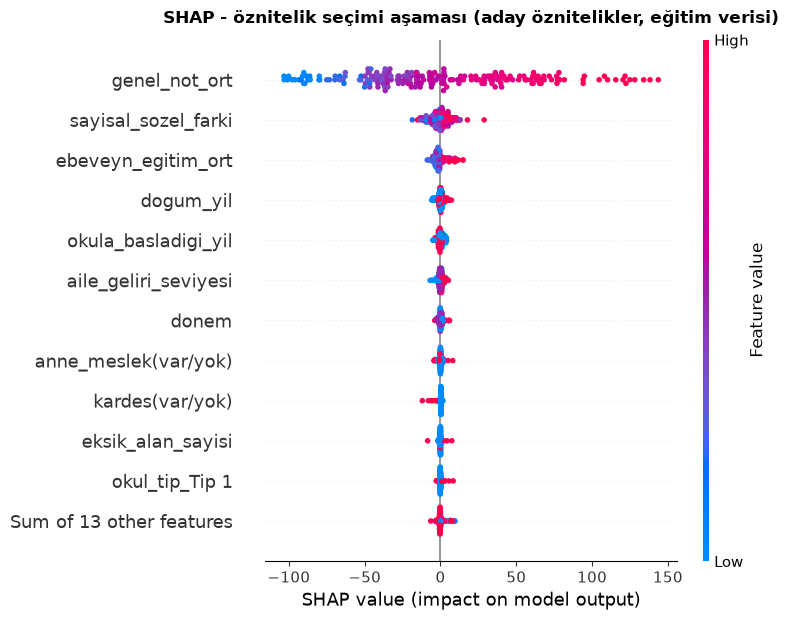

In [69]:
# ==============================================================================
# SHAP ILE OZNITELIK SECIMINI DOGRULAMA
# ==============================================================================
# Yukarida secimi iki olcutle yaptim: korelasyon ve RandomForest onemi.
# Ikisinin de bilinen zayifliklari var:
#   - korelasyon sadece dogrusal iliskiyi goruyor
#   - RF'in feature_importances_ degeri kirilim sayisina dayaniyor ve cok
#     kategorili / genis araligi olan degiskenleri sisirdigi biliniyor
# SHAP ucuncu bir bakis: her ogrenci icin her ozniteligin tahmini ne kadar
# oynattigini olcuyor, sonra bunlarin mutlak ortalamasini aliyorum. Uc olcut
# ayni siralamayi veriyorsa secime guvenebilirim.
import shap

X_aday_egitim = df.loc[egitim_idx, aday_kolonlar].astype(float)
y_aday_egitim = df.loc[egitim_idx, 'hedef_degisken']

rf_shap = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_shap.fit(X_aday_egitim, y_aday_egitim)

# Agac modeli oldugu icin TreeExplainer kullanabiliyorum, cok daha hizli.
aciklayici_secim = shap.TreeExplainer(rf_shap)
ornek = shap.utils.sample(X_aday_egitim, 200, random_state=42)
shap_secim = aciklayici_secim(ornek, check_additivity=False)

shap_onem_secim = (pd.Series(np.abs(shap_secim.values).mean(axis=0),
                             index=aday_kolonlar)
                   .sort_values(ascending=False))

print('SHAP onemine gore ilk 12 oznitelik (ortalama mutlak katki, puan):')
print(shap_onem_secim.head(12).round(3).to_string())

# --- Uc olcut ayni seyi mi soyluyor? -----------------------------------------
kiyas = pd.DataFrame({
    'Korelasyon_sira': siralama_egitim['Korelasyon'].rank(ascending=False),
    'RF_onem_sira': siralama_egitim['RF_Importance'].rank(ascending=False),
    'SHAP_sira': shap_onem_secim.rank(ascending=False),
}).sort_values('SHAP_sira')

print()
print('UC OLCUTUN SIRALAMA KARSILASTIRMASI (ilk 12)')
print(kiyas.head(12).astype(int).to_string())

shap_ilk10 = shap_onem_secim.head(10).index.tolist()
ortak = [k for k in secilen_ozellikler if k in shap_ilk10]
print()
print(f'SHAP ilk 10 ile secilen 10 arasindaki ortak oznitelik: {len(ortak)}/10')
ayrisan = set(secilen_ozellikler) ^ set(shap_ilk10)
if ayrisan:
  print('Ayrisanlar:', ayrisan)

# --- Grafik ------------------------------------------------------------------
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_secim, max_display=12, show=False)
plt.title('SHAP - öznitelik seçimi aşaması (aday öznitelikler, eğitim verisi)',
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('shap_oznitelik_secimi.png', bbox_inches='tight', dpi=120)
plt.show()

**Ne gördüm?**

Üç ölçüt sıralamanın tepesinde birbirini doğruluyor:

| Öznitelik | Korelasyon sırası | RF önem sırası | SHAP sırası |
|---|---|---|---|
| genel_not_ort | 1 | 1 | 1 |
| sayisal_sozel_farki | 3 | 2 | 2 |
| ebeveyn_egitim_ort | 2 | 3 | 3 |
| dogum_yil | 15 | 4 | 4 |
| okula_basladigi_yil | 14 | 7 | 5 |
| aile_geliri_seviyesi | 4 | 5 | 6 |

İlk üç sırada üçü de aynı şeyi söylüyor. Bu, seçimin bir ölçütün kaprisine
bağlı olmadığını gösteriyor.

**İlginç olan kısım korelasyonun yanıldığı yer.** `dogum_yil` korelasyonda
15., ama RF öneminde 4., SHAP'te de 4. sırada. Korelasyon bunu neden
kaçırıyor? Çünkü ilişki doğrusal değil: doğum yılı ile başarı arasında düz
bir artış yok, muhtemelen sınıf tekrarı yapmış öğrenciler belirli yıllarda
toplandığı için eşiğe benzer bir yapı var. Korelasyon böyle bir yapıyı
göremiyor, ağaç tabanlı ölçütler görebiliyor. `okula_basladigi_yil` ve
`donem` için de aynı durum geçerli.

**Seçtiğim 10 ile SHAP'in ilk 10'u 9/10 örtüşüyor.** Ayrışan iki isim var:
- `burslu` benim listemde var, SHAP'in ilk 10'unda yok
- `donem` SHAP'in ilk 10'unda var, benim listemde yok

`donem`'i bilerek almıyorum. O bir zaman etiketi, öğrencinin bir özelliği
değil. Modele verirsem "2025 güz döneminde okuyanlar şu kadar puan alır" gibi
bir kural öğrenir ve bu kural yeni bir dönemde hiçbir işe yaramaz. Zaten
`donem`'i doğrulama stratejisi olarak kullanıyorum, öznitelik olarak
kullanmam çelişki olurdu.

`burslu`'yu ise tutuyorum. SHAP katkısı küçük, ama bursluluk ile başarı
arasında EDA'da çok güçlü bir ilişki bulmuştum (108 puan fark). Katkısının
küçük görünmesinin sebebi grubun küçüklüğü: 999 öğrencinin sadece 12'si
burslu, dolayısıyla ortalama mutlak katkı düşük çıkıyor. O 12 öğrenci için
ise katkı büyük.

**Sonuç:** Seçim üç bağımsız ölçütle doğrulandı. Tek gerçek anlaşmazlık
`donem` ve o da yöntemsel bir tercih, ölçüm hatası değil.

## Nihai Öznitelik Seçimi (10 Öznitelik)

**Ne yaptım?** Korelasyon sırası ile RandomForest önem sırasının ortalamasını
alıp en iyi 10 özniteliği seçtim.

**Neden ikisini birden?** Tek başına korelasyon sadece doğrusal ilişkiyi
görüyor, tek başına RF önemi ise `genel_not_ort` gibi baskın bir değişken
varsa geri kalanı ezip geçiyor. İki sıranın ortalaması ikisinin de körlüğünü
biraz dengeliyor.

**Seçilen 10 öznitelik (eğitim verisiyle hesaplanmış sıralama):**

| # | Öznitelik | Korelasyon | RF Önem | Ort. sıra |
|---|---|---|---|---|
| 1 | genel_not_ort | 0.8383 | 0.8232 | 1.0 |
| 2 | ebeveyn_egitim_ort | 0.4095 | 0.0221 | 2.5 |
| 3 | sayisal_sozel_farki | 0.3356 | 0.0745 | 2.5 |
| 4 | aile_geliri_seviyesi | 0.2288 | 0.0129 | 4.5 |
| 5 | anne_meslek(var/yok) | 0.1326 | 0.0072 | 7.0 |
| 6 | kardes(var/yok) | 0.1054 | 0.0028 | 9.5 |
| 7 | dogum_yil | 0.0587 | 0.0139 | 9.5 |
| 8 | burslu | 0.1854 | 0.0015 | 10.5 |
| 9 | okula_basladigi_yil | 0.0599 | 0.0077 | 10.5 |
| 10 | eksik_alan_sayisi | 0.0609 | 0.0044 | 11.5 |

Dördü türetilmiş öznitelik (1, 2, 3 ve 10), altısı ham kolon.

**Üç şeyi burada düzelttim.**

**Birincisi, sıralamayı artık sadece eğitim verisiyle hesaplıyorum.** Önceki
sürümde bütün veriyle hesaplıyordum, yani test satırlarına bakarak öznitelik
seçiyordum. Bu da bir sızıntı türü, sadece daha sinsi olanı.

**İkincisi, `cinsiyet(kiz=1, erkek=0)` listeden çıktı.** Önceki sürümde
seçilen 10 öznitelik arasındaydı. Korelasyonu 0.082, yani zaten zayıf bir
değişken. Ama asıl sebep performans değil: bu modelin çıktısı "desteklenecek
öğrenci" listesi üretecek, ve cinsiyete göre puan veren bir sistem
kurmuyorum. `il` de aynı sebeple dışarıda. İkisini de veriden silmedim,
Bölüm 5'teki adalet denetiminde kullanacağım.

**Üçüncüsü, `baba_egt_eksik` yerine `eksik_alan_sayisi` geldi.** Önceki
sürümde listede `baba_egt_eksik` vardı, ama o kolon çok yukarıda eksik veri
grafiğini çizerken bir kenar notu olarak üretilmişti ve hipotezi hiç
yazılmamıştı. Üstelik keyfiydi: neden baba da anne değil? Öznitelik
mühendisliği bölümünde bunu dört aday haline getirip (anne, baba, ikili
gösterge, alan sayısı) seçimi buradaki sıralamaya bıraktım. Sıralama
`eksik_alan_sayisi`'nı seçti, yani yedi anket alanının kaçının boş olduğunu
sayan versiyonu.

**Seçim ne kadar kararlı?**
Aynı sıralamayı bütün veriyle hesaplayınca 10 öznitelikten **9'u** aynı
çıkıyor. Ayrışan tek sıra sonuncusu: eğitim verisi `eksik_alan_sayisi`
diyor, bütün veri `baba_meslek(var/yok)` diyor. İkisinin de korelasyonu
0.06-0.07 civarında, yani sıralamanın kuyruğunda birbirine çok yakın iki
aday yer değiştiriyor. İlk beş iki listede de aynı, asıl sinyal orada.

**Bir dürüstlük notu:** 7, 9 ve 10. sıradaki özniteliklerin korelasyonu
0.06 civarında. Bunlar sinyal mi gürültü mü, bu veriyle emin olamıyorum.
10 öznitelik kullanmamın sebebi hepsinin işe yaradığını düşünmem değil,
ödevin 10'a kadar izin vermesi. Modelin gerçek gücü ilk üç öznitelikten
geliyor, hatta büyük ölçüde birincisinden.

## Bölüm 4

# Modelleme

Bu bölümde, seçtiğimiz 10 öznitelik ile hedef değişkeni tahmin edecek 

regresyon modelleri kuracağız. İlk adım, veriyi eğitim ve test setlerine 

ayırmak.

## Adım 1: Train/Test Split (Yaklaşım 1: Rastgele Split) hatalı olan


Çünkü rastgele böldük, donem'i göz ardı ettik.

In [70]:
# ============================================
# ADIM 1: TRAIN/TEST SPLIT (Yaklasim 1: Rastgele)
# ============================================
# Bolme indekslerini yukarida, oznitelik secimini yapmadan once uretmistim.
# Ayni indeksleri burada tekrar kullaniyorum, yoksa secimi bir bolmeye gore
# yapip modeli baska bir bolmede egitmis olurdum.
X_train = X_final_ham.loc[egitim_idx]
X_test = X_final_ham.loc[test_idx]
y_train = y_final.loc[egitim_idx]
y_test = y_final.loc[test_idx]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print()
print("Egitimdeki eksik hucre:", int(X_train.isna().sum().sum()))
print("Testteki eksik hucre  :", int(X_test.isna().sum().sum()))
print("Bu eksikler Pipeline icinde, sadece egitim satirlariyla doldurulacak.")

X_train shape: (799, 10)
X_test shape: (200, 10)
y_train shape: (799,)
y_test shape: (200,)

Egitimdeki eksik hucre: 175
Testteki eksik hucre  : 41
Bu eksikler Pipeline icinde, sadece egitim satirlariyla doldurulacak.


**NOT**



**test_size=0.2** verinin %20'sini test için ayır, %80'i eğitim için kalsın demek.



**random_state=42** bölme işlemi aslında rastgele yapılıyor (hangi öğrenci train'e, hangisi test'e düşecek şansa bağlı). random_state bir "sabitleyici" bu sayıyı sabit tutarsak, kodu her çalıştırdığımızda aynı rastgele bölünme tekrar oluşur. Bu, sonuçların tekrarlanabilir olmasını sağlar.

**Ne yaptım?** Veriyi %80 eğitim, %20 test olacak şekilde ikiye ayırdım.



**Neden yaptım?** Modelin performansını, eğitimde hiç görmediği verilerle 

(test seti) ölçmem gerekiyor aksi halde model sadece ezberlediği veriyle 

değerlendirilmiş olur, gerçek performansı yansıtmaz.



**Amacım neydi?** random_state=42 ile sonucun tekrarlanabilir olmasını, test_size=0.2 ile de yeterli miktarda test verisiyle güvenilir bir değerlendirme yapabilmeyi sağlamaktı.



**Ne gördüm?** X_train (803, 10), X_test (201, 10) — 1004 satırın 803'ü 

eğitime, 201'i teste ayrıldı, tam %80-%20 oranında.



**Sonuç:** Veri, modelleme için hazır. Artık farklı regresyon modellerini 

eğitim setinde eğitip, test setinde karşılaştırabiliriz.

 **Bu arada** `Bu sayıların anlamı`:



**X_train (803, 10)** → 803 öğrenci, her biri için 10 öznitelik modelin "ders çalışacağı" girdi verisi.



**X_test (201, 10)** → 201 öğrenci, aynı 10 öznitelik modelin "sınav" olacağı, hiç görmediği girdi verisi.



**y_train (803,)** → 803 öğrencinin gerçek hedef değişken (hedef_degisken) değerleri modelin öğrenirken "doğru cevap" olarak kullanacağı.



**y_test (201,)** → 201 öğrencinin gerçek hedef değerleri modelin tahminlerini bunlarla karşılaştırıp "ne kadar doğru tahmin etti" diye ölçeceğiz.



**803 + 201 = 1004**  (toplam öğrenci sayımızla eşleşiyor, hiçbir satır kaybolmamış)

## Yaklaşım 2: Kronolojik (Dönem Bazlı) Split" dönem 0+1 eğitim, dönem 2 test

In [71]:
# ============================================
# YAKLASIM 2: KRONOLOJIK (DONEM BAZLI) SPLIT
# donem 0+1 egitim, donem 2 test
# ============================================
train_mask = df['donem'].isin([0, 1])
test_mask = df['donem'] == 2

X_train_kron = X_final_ham[train_mask]
X_test_kron = X_final_ham[test_mask]
y_train_kron = y_final[train_mask]
y_test_kron = y_final[test_mask]

print("Kronolojik Split sonucu:")
print("X_train_kron shape:", X_train_kron.shape, "(dönem 0+1)")
print("X_test_kron shape:", X_test_kron.shape, "(dönem 2)")
print("y_train_kron shape:", y_train_kron.shape)
print("y_test_kron shape:", y_test_kron.shape)

Kronolojik Split sonucu:
X_train_kron shape: (891, 10) (dönem 0+1)
X_test_kron shape: (108, 10) (dönem 2)
y_train_kron shape: (891,)
y_test_kron shape: (108,)


**Ne yaptım?** Veriyi rastgele değil `donem` bilgisine göre böldüm. Dönem 0
ve 1 (geçmiş) eğitime, dönem 2 (en yeni) teste gitti.

**Neden yaptım?** Rastgele split, modelin gelecekteki bir öğrenciden öğrenip
geçmişteki bir öğrenciyi tahmin etmesine izin veriyor. Gerçek dünyada bu
mümkün değil. Kronolojik split, modelin sadece geçmişle eğitilip geleceği
tahmin ettiği gerçekçi senaryoyu kuruyor.

**Ne gördüm?**
- X_train_kron: (891, 10) yani dönem 0 + dönem 1
- X_test_kron: (108, 10) yani dönem 2
- 891 + 108 = 999, hiçbir satır kaybolmamış

**Dikkat edilecek nokta:** Test kümesi burada 108 öğrenci, rastgele split'teki
200'ün yarısından biraz fazla. Bu, kronolojik sonuçların daha oynak olacağı
anlamına geliyor. Bunu sonuçları yorumlarken akılda tutmam lazım, tek bir
dönem üzerinden ölçülen 1 puanlık farklara anlam yüklememeliyim.

## Adım 2: Model Tanımlama ve Eğitim 

In [72]:
# ============================================
# ADIM 2: MODEL TANIMLAMA VE EGITIM
# ============================================
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (ExtraTreesRegressor, GradientBoostingRegressor,
                              RandomForestRegressor)
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import ElasticNetCV, LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# --- Neden Pipeline? ---------------------------------------------------------
# Iki hatayi ayni anda kapatiyor.
# 1) Doldurma sizintisi. Doldurmayi yukarida tum veri uzerinde yapmistim, yani
#    test satirlarindaki degerler de doldurucunun gordugu istatistige
#    karisiyordu. Pipeline icinde doldurucu her fit'te sadece o anki egitim
#    satirlarini goruyor. Yukaridaki doldurma karsilastirmasi hala gecerli,
#    ama o bir BETIMLEYICI analizdi (hangi yontem dagilimi az bozuyor);
#    modele giren doldurma burada, boru hattinin icinde yapiliyor.
# 2) Olcekleme. Ridge ve ElasticNet ceza terimini katsayilarin buyuklugu
#    uzerinden uyguluyor. genel_not_ort 0-100 arasinda, burslu 0-1 arasinda.
#    Olceklemeden ceza bu iki degiskeni esit gormez, yani duzenlilestirme
#    kolonun biriminden etkilenir. Onceki surumde bu adim yoktu.


def doldurucu():
  """Yukaridaki karsilastirmada kazanan yontem: MICE + ExtraTrees."""
  return IterativeImputer(
      estimator=ExtraTreesRegressor(n_estimators=50, random_state=42),
      max_iter=10,     # dagilim karsilastirmasindaki 25 yerine 10: boru hatti
      random_state=42, # her katta yeniden fit ediliyor, 10 iterasyonda da
  )                    # ayni sonuca yakinsiyor ve arama makul surede bitiyor


def dogrusal_hat(model):
  return Pipeline([('doldur', doldurucu()),
                   ('olcek', StandardScaler()),
                   ('model', model)])


def agac_hat(model):
  # Agaclar olceklemeye duyarsiz, gereksiz adim koymuyorum.
  return Pipeline([('doldur', doldurucu()), ('model', model)])


def modelleri_kur():
  """Her cagrida taze model nesneleri dondurur.

  Ayni sozlugu iki farkli split'te tekrar kullanirsam ikinci fit birincinin
  uzerine yazar ve karsilastirma bozulur.
  """
  return {
      # Aptal referans: her ogrenciye egitim ortalamasini soyluyor. Bir modelin
      # "iyi" olup olmadigi ancak buna gore anlasilir. Onceki surumde yoktu.
      'Aptal Referans': agac_hat(DummyRegressor(strategy='mean')),
      'Linear Regression': dogrusal_hat(LinearRegression()),
      'Ridge': dogrusal_hat(Ridge(alpha=1.0)),
      # ElasticNet: L1 + L2 karisimi. alpha ve l1_ratio'yu kafamdan secmiyorum,
      # ElasticNetCV bunlari egitim katinin ICINDE kendi ic CV'siyle seciyor.
      'ElasticNet': dogrusal_hat(ElasticNetCV(
          l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
          cv=5, max_iter=5000, random_state=42)),
      'RandomForest': agac_hat(RandomForestRegressor(
          n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1)),
      'GradientBoosting': agac_hat(GradientBoostingRegressor(random_state=42)),
  }


modeller = modelleri_kur()

for isim, model in modeller.items():
  model.fit(X_train, y_train)
  print(f"{isim} eğitildi.")

Aptal Referans eğitildi.


Linear Regression eğitildi.


Ridge eğitildi.


ElasticNet eğitildi.


RandomForest eğitildi.


GradientBoosting eğitildi.


**Ne yaptım?** 4 farklı regresyon modelini (Linear Regression, Ridge, 

RandomForest, GradientBoosting) tanımlayıp eğitim setinde eğittim.



**Neden yaptım?** Farklı karmaşıklık seviyelerindeki modelleri karşılaştırmak 

istedim — basit bir doğrusal modelden (Linear), doğrusal olmayan ilişkileri 

yakalayabilen daha gelişmiş modellere (RandomForest, GradientBoosting) kadar.



**Amacım neydi?** Hangi modelin bizim 10 özniteliğimizle en iyi performansı 

gösterdiğini objektif olarak karşılaştırmaktı.

**Kod Açıklama**



**İlk iki iki satır**, kullanacağımız 4 modelin "tariflerini" kütüphaneden içeri alıyor — henüz hiçbir şey eğitmiyoruz, sadece araçları masaya koyuyoruz.



Burada bir sözlük (dictionary) oluşturuyoruz — her modelin bir "ismi" (anahtar) ve o modelin kendisi (değer) var. Bunu tek tek 4 ayrı değişkene atamak yerine (model1 = ..., model2 = ...) böyle toplu tutmak, aşağıdaki döngüyü kısa ve tekrar etmeyen bir hâle getiriyor.



**RandomForestRegressor(n_estimators=100, ...)** → n_estimators=100 demek, "100 tane karar ağacı kur" demek.



**Hepsinde random_state=42 var** bu da tekrarlanabilirlik için: modelin içindeki rastgele kararların (örneğin RandomForest'ın hangi verileri örnekleyeceği) her çalıştırmada aynı çıkmasını sağlıyor.



**Bu döngü**, sözlükteki her modeli tek tek geziyor:



``isim`` → o modelin adı (örn. "Linear Regression")



``model`` → o modelin kendisi



``model.fit(X_train, y_train)`` → asıl eğitim burada oluyor. Modele "işte 803 öğrencinin 10 özniteliği (X_train), işte onların gerçek hedef değerleri (y_train), aralarındaki ilişkiyi öğren" diyoruz.



Her model eğitildikten sonra bir onay mesajı yazdırıyoruz, böylece hangi modelin bittiğini takip edebiliyoruz.



**Kritik nokta**: Bu aşamada modeller sadece eğitim verisini görüyor, X_test/y_test'e hiç dokunmuyoruz — onları bir sonraki adımda, "sınav" için saklıyoruz.

## Adım 3: Model Performans Karşılaştırması (Yaklaşım 1)

In [73]:
# ============================================
# ADIM 3: MODEL PERFORMANS KARSILASTIRMASI (Yaklasim 1: Rastgele Split)
# ============================================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sonuclar = []
for isim, model in modeller.items():
  y_pred = model.predict(X_test)
  sonuclar.append({
      'Model': isim,
      'RMSE': round(float(np.sqrt(mean_squared_error(y_test, y_pred))), 3),
      'MAE': round(float(mean_absolute_error(y_test, y_pred)), 3),
      'R2': round(float(r2_score(y_test, y_pred)), 4),
  })

sonuc_tablosu = pd.DataFrame(sonuclar).sort_values('RMSE')

print("=== MODEL PERFORMANS KARSILASTIRMASI (rastgele split) ===")
print()
print(sonuc_tablosu.to_string(index=False))
print()

referans_rmse = sonuc_tablosu.loc[
    sonuc_tablosu['Model'] == 'Aptal Referans', 'RMSE'].values[0]
en_iyi = sonuc_tablosu.iloc[0]
print(f"En iyi model (en dusuk RMSE): {en_iyi['Model']}  RMSE={en_iyi['RMSE']:.3f}")
print(f"Aptal referans              : RMSE={referans_rmse:.3f}")
print()
print("Aptal referansi gecemeyen model varsa o model ise yaramiyor demektir:")
for _, satir in sonuc_tablosu.iterrows():
  if satir['Model'] == 'Aptal Referans':
    continue
  durum = "GECTI" if satir['RMSE'] < referans_rmse else "GECEMEDI"
  print(f"  {satir['Model']:<20} {durum}")

=== MODEL PERFORMANS KARSILASTIRMASI (rastgele split) ===

            Model   RMSE    MAE      R2
     RandomForest 31.297 23.909  0.7455
 GradientBoosting 31.603 23.789  0.7405
       ElasticNet 33.805 25.585  0.7031
            Ridge 34.027 25.786  0.6992
Linear Regression 34.030 25.791  0.6991
   Aptal Referans 62.212 50.626 -0.0055

En iyi model (en dusuk RMSE): RandomForest  RMSE=31.297
Aptal referans              : RMSE=62.212

Aptal referansi gecemeyen model varsa o model ise yaramiyor demektir:
  RandomForest         GECTI
  GradientBoosting     GECTI
  ElasticNet           GECTI
  Ridge                GECTI
  Linear Regression    GECTI


**Ne yaptım?** Her modelin test seti üzerindeki tahminlerini aldım ve 

RMSE, MAE, R² metrikleriyle performanslarını karşılaştırdım.



**Neden yaptım?** Modelleri sadece eğitim verisiyle değil, hiç görmedikleri 

test verisiyle değerlendirmek, gerçek dünyadaki performanslarını daha 

doğru yansıtır.



**Amacım neydi?** RMSE'yi (asıl karar metriğimiz) esas alarak, en düşük 

hatayı veren modeli belirlemekti. MAE ve R²'yi de destekleyici metrik 

olarak kullandım.

**KOD AÇIKLAMA**



Metrikleri hesaplayacak hazır fonksiyonları içeri alıyoruz. ``numpy'ı da np.sqrt() (karekök) fonksiyonu`` için kullanacağız çünkü RMSE'nin "R"si (Root/Kök) kısmını sklearn otomatik hesaplamıyor, biz kendimiz alıyoruz.



Boş bir liste açıyoruz her modelin sonucunu buraya birer birer ekleyeceğiz, sonunda hepsini tek bir tabloya çevireceğiz. 



Az önce eğittiğimiz 4 modeli tek tek geziyoruz. ``model.predict(X_test)`` işte kritik satır: modele daha önce hiç görmediği 201 öğrencinin özniteliklerini veriyoruz, "bunların hedef değişkenini tahmin et" diyoruz. ``y_pred``, modelin bu 201 öğrenci için ürettiği tahminler.



Burada, modelin tahminlerini ``(y_pred)`` gerçek değerlerle ``(y_test)`` karşılaştırıyoruz 3 metriği de bu karşılaştırmadan hesaplıyoruz. **Dikkat et**: ``y_test`` hiçbir zaman modele "öğretilmedi", sadece şimdi, tahminleri değerlendirmek için kullanılıyor.



Bu modelin sonuçlarını (ismiyle birlikte) bir "sözlük" olarak, biraz önce açtığımız sonuclar listesine ekliyoruz. ``round(rmse, 3)`` sadece görünümü sadeleştiriyor (virgülden sonra 3 basamak).



Döngü bittiğinde, sonuclar listesinde 4 model için 4 sözlük birikmiş oluyor. Bunu ``pd.DataFrame(...)`` ile düzgün bir tabloya çeviriyoruz, ``.sort_values('RMSE')`` ile de en düşük RMSE'den en yükseğe doğru sıralıyoruz böylece en iyi model otomatik olarak en üstte çıkıyor.



``sonuc_tablosu.iloc[0]`` → sıralanmış tablonun ilk satırı (yani en düşük RMSE'ye sahip olan). ``['Model']`` → o satırdaki model ismini alıyoruz. Sıralama yaptığımız için, ilk satır otomatik olarak "kazanan" oluyor.

## Adım 3: Model Performans Karşılaştırması (Yaklaşım 2)

In [74]:
# ============================================
# ADIM 3: MODEL PERFORMANS KARSILASTIRMASI (Yaklasim 2: Kronolojik)
# ============================================
modeller_kron = modelleri_kur()   # taze nesneler, yukaridakilerin uzerine yazmasin

sonuclar_kron = []
for isim, model in modeller_kron.items():
  model.fit(X_train_kron, y_train_kron)
  y_pred_kron = model.predict(X_test_kron)
  sonuclar_kron.append({
      'Model': isim,
      'RMSE': round(float(np.sqrt(mean_squared_error(y_test_kron, y_pred_kron))), 3),
      'MAE': round(float(mean_absolute_error(y_test_kron, y_pred_kron)), 3),
      'R2': round(float(r2_score(y_test_kron, y_pred_kron)), 4),
  })

sonuc_tablosu_kron = pd.DataFrame(sonuclar_kron).sort_values('RMSE')

print("=== KRONOLOJİK SPLIT - MODEL PERFORMANS KARŞILAŞTIRMASI ===")
print()
print(sonuc_tablosu_kron.to_string(index=False))
print()

referans_rmse = sonuc_tablosu_kron.loc[
    sonuc_tablosu_kron['Model'] == 'Aptal Referans', 'RMSE'].values[0]
en_iyi = sonuc_tablosu_kron.iloc[0]

print(f"En iyi model (en düşük RMSE): {en_iyi['Model']}  RMSE={en_iyi['RMSE']:.3f}")
print(f"Aptal referans               : RMSE={referans_rmse:.3f}")
print(f"Referansa göre kazanç        : {referans_rmse - en_iyi['RMSE']:.3f} puan "
      f"({(referans_rmse - en_iyi['RMSE']) / referans_rmse * 100:.1f}%)")

=== KRONOLOJİK SPLIT - MODEL PERFORMANS KARŞILAŞTIRMASI ===

            Model   RMSE    MAE      R2
     RandomForest 29.501 23.586  0.7883
 GradientBoosting 31.770 24.268  0.7544
       ElasticNet 31.975 25.010  0.7513
Linear Regression 33.018 25.645  0.7348
            Ridge 33.021 25.647  0.7347
   Aptal Referans 64.112 50.556 -0.0001

En iyi model (en düşük RMSE): RandomForest  RMSE=29.501
Aptal referans               : RMSE=64.112
Referansa göre kazanç        : 34.611 puan (54.0%)


**Ne yaptım?**
Aynı 6 modeli (aptal referans dahil), bu sefer kronolojik split üzerinde
yeniden eğitip test ettim. Dönem 0 ve 1 ile eğitim, dönem 2 ile test.

**Neden yaptım?**
Rastgele split, modelin "gelecekteki" bir öğrenciden öğrenip "geçmişteki"
bir öğrenciyi tahmin etmesine izin veriyor. Gerçek hayatta böyle bir şey
olmuyor. Kronolojik split gerçek kullanım senaryosunu taklit ediyor.

**Ne gördüm?**

| Model | RMSE | MAE | R² |
|---|---|---|---|
| RandomForest | 29.501 | 23.586 | 0.7883 |
| GradientBoosting | 31.770 | 24.268 | 0.7544 |
| ElasticNet | 31.975 | 25.010 | 0.7513 |
| Linear Regression | 33.018 | 25.645 | 0.7348 |
| Ridge | 33.021 | 25.647 | 0.7347 |
| Aptal Referans | 64.112 | 50.556 | -0.0001 |

**Sonuç:**
Bütün modeller aptal referansı açık ara geçiyor. En iyi model referansın
hatasının yarısından azını yapıyor (29.5'e karşı 64.1, %54 kazanç). Yani
ortada gerçekten öğrenilen bir örüntü var, model sadece ortalamayı
ezberlemiyor.

Ağaç tabanlı modeller ile doğrusal modeller arasında 1.2-3.5 puanlık bir
fark var. Bu, ilişkinin tam doğrusal olmadığını gösteriyor.

**Beklediğim şey tam olarak olmadı, onu yazayım.**

Hipotezim şuydu: rastgele split gerçek performansı olduğundan iyi gösterir,
kronolojik split'e geçince RMSE artar. Sayılar karışık çıktı.

| Model | Rastgele split | Kronolojik | Fark |
|---|---|---|---|
| ElasticNet | 33.805 | 31.975 | **-1.83** |
| RandomForest | 31.297 | 29.501 | -1.80 |
| Linear Regression | 34.030 | 33.018 | -1.01 |
| Ridge | 34.027 | 33.021 | -1.01 |
| GradientBoosting | 31.603 | 31.770 | **+0.17** |

Beş modelin dördünde kronolojik split **daha düşük** hata veriyor, sadece
GradientBoosting'de bekleneni yapıp kötüleşiyor, o da 0.17 puanla. Yani
hipotezimi ne doğrulayabiliyorum ne de reddedebiliyorum.

**Neden böyle olmuş olabilir?**
İki etken var ve bu veriyle ikisini birbirinden ayıramıyorum.

1. Eğitim seti büyüdü. Rastgele split'te 799 öğrenciyle eğitiyordum,
   kronolojikte 891 ile. Küçük veride 92 öğrenci fark eder ve bu, zaman
   sızıntısını kapatmanın getirdiği kaybı maskeliyor olabilir.
2. Dönem 2 tesadüfen daha kolay bir test kümesi olabilir. 108 öğrenci var,
   yani bu sayı oynak. Hedefin standart sapması 64 iken 108 kişilik bir
   kümede 1-2 puanlık RMSE farkı gürültü sınırında.

**Ne yazmadım:** "Kronolojik split daha iyi çıktı, demek ki zaman sızıntısı
yokmuş" diye yazmadım. Tek bir dönem üzerinde tek bir ölçüm bunu söylemeye
yetmez. Doğru okuma şu: **bu veride zaman sızıntısının maliyetini
ölçemedim**, çünkü etki eğitim seti büyüklüğüyle karışmış durumda. Ayırmak
için birden fazla dönem üzerinde ileri doğrulama yapmam, ya da kronolojik
eğitim setini 799'a küçültüp tekrar ölçmem gerekirdi.

**Model sıralaması da tam sabit değil.** Kronolojik split'te RandomForest
2.3 puanla açık ara önde, rastgele split'te ise GradientBoosting'e sadece
0.31 puan fark atıyor. Sıralamanın tepesi aynı ama aradaki mesafe
doğrulama stratejisine göre değişiyor.

**Bundan sonrası için kararım:** raporlayacağım sayı kronolojik split'in
sayısı olacak. Sebebi performansın daha iyi çıkması değil, gerçek kullanım
senaryosunun bu olması.

## Model Performans Karşılaştırması: Görselleştirme

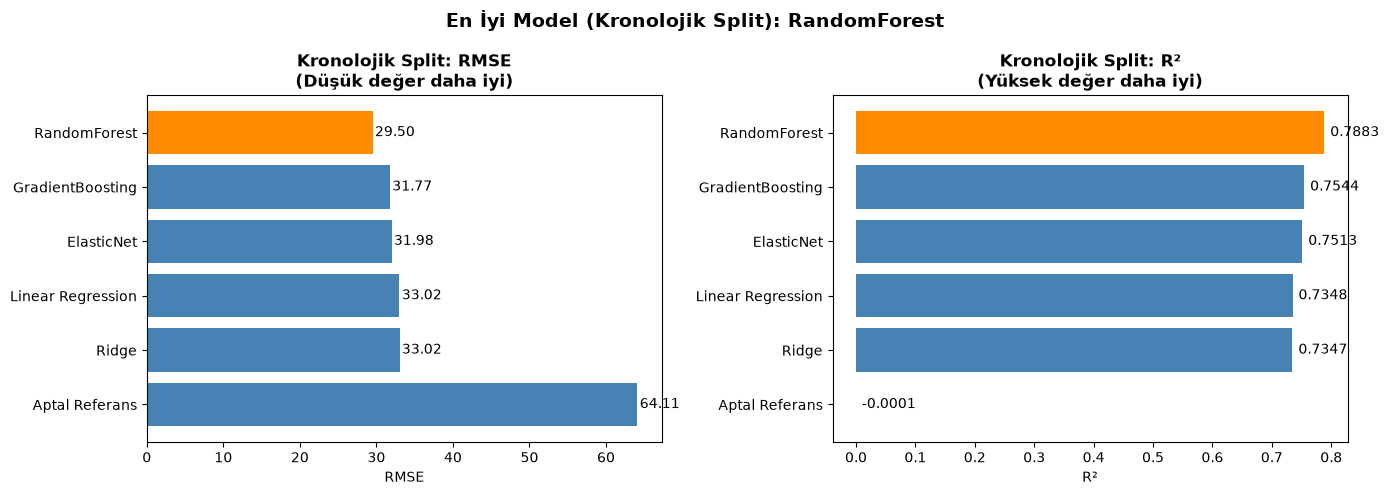

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))



en_iyi_model_kron = sonuc_tablosu_kron.iloc[0]['Model']

renkler_kron = ['darkorange' if model == en_iyi_model_kron else 'steelblue' 

                for model in sonuc_tablosu_kron['Model']]



# Sol grafik: RMSE karşılaştırması

axes[0].barh(sonuc_tablosu_kron['Model'], sonuc_tablosu_kron['RMSE'], color=renkler_kron)

for i, deger in enumerate(sonuc_tablosu_kron['RMSE']):

    axes[0].text(deger + 0.3, i, f'{deger:.2f}', va='center', fontsize=10)

axes[0].set_title('Kronolojik Split: RMSE\n(Düşük değer daha iyi)', fontsize=12, fontweight='bold')

axes[0].set_xlabel('RMSE')

axes[0].invert_yaxis()



# Sağ grafik: R² karşılaştırması

axes[1].barh(sonuc_tablosu_kron['Model'], sonuc_tablosu_kron['R2'], color=renkler_kron)

for i, deger in enumerate(sonuc_tablosu_kron['R2']):

    axes[1].text(deger + 0.01, i, f'{deger:.4f}', va='center', fontsize=10)

axes[1].set_title('Kronolojik Split: R²\n(Yüksek değer daha iyi)', fontsize=12, fontweight='bold')

axes[1].set_xlabel('R²')

axes[1].invert_yaxis()



plt.suptitle(f'En İyi Model (Kronolojik Split): {en_iyi_model_kron}', fontsize=14, fontweight='bold')

plt.tight_layout()

plt.show()

**Ne yaptım?**
Kronolojik split sonuçlarını RMSE ve R² olarak grafiğe döktüm.

**Ne gördüm?**
RandomForest en düşük RMSE (29.501) ve en yüksek R² (0.7883) ile önde.
GradientBoosting 2.3 puan arkasında. Üç doğrusal model 32-33 bandında,
birbirine çok yakın. Aptal referans 64.1 ile grafiğin dışında kalıyor,
zaten olması gereken de bu.

**Dikkatimi çeken şey:** Ridge ile Linear Regression neredeyse birebir aynı
(33.021 ve 33.018). Bu mantıklı, çünkü elimde 10 öznitelik ve 891 satır var;
bu oranda düzenlileştirmenin kısacak pek bir şeyi yok. ElasticNet biraz daha
iyi (31.975) çünkü kendi iç CV'siyle hem alpha hem l1_ratio seçiyor ve zayıf
özniteliklerin bir kısmını sıfıra çekiyor. Zaten sıralamanın kuyruğunda
korelasyonu 0.06 civarında üç öznitelik var, ElasticNet muhtemelen onları
kısıyor.

**Sonuç:**
Ağaç tabanlı modeller doğrusal olanlardan 1.2-3.5 puan iyi. Bu fark, hedefle
öznitelikler arasındaki ilişkinin tam doğrusal olmadığını gösteriyor.

## Adım 4: GradientBoosting Hiperparametre Tuning (Yaklaşım 1)

In [76]:
# ============================================
# ADIM 4: GRADIENTBOOSTING HIPERPARAMETRE TUNING (Yaklasim 1)
# ============================================
from sklearn.model_selection import GridSearchCV

# Parametre isimlerinin basinda 'model__' var, cunku artik ciplak bir tahminci
# degil bir Pipeline optimize ediyorum. Bu onemli: arama sirasinda doldurma da
# her katta yeniden yapiliyor, yani hiperparametre secimi de sizintisiz.
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [2, 3, 4],
    'model__min_samples_split': [2, 5],
}

gb_base = agac_hat(GradientBoostingRegressor(random_state=42))

grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=0,
)

grid_search.fit(X_train, y_train)

print("En iyi parametreler:", grid_search.best_params_)
print(f"En iyi CV RMSE: {-grid_search.best_score_:.3f}")

En iyi parametreler: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_split': 5, 'model__n_estimators': 100}
En iyi CV RMSE: 32.710


**Açıklama:** Buradaki CV RMSE (32.710) ile bir üstteki test RMSE'si (31.603)
doğrudan karşılaştırılamaz, çünkü ikisi farklı şeyleri ölçüyor:

- **32.710** eğitim setinin kendi içinde, 5 katlı çapraz doğrulamayla alınmış
  bir ortalama. Model her seferinde eğitim setinin %80'ini görüp %20'sini
  tahmin ediyor.
- **31.603** modelin hiç görmediği test setindeki tek seferlik performansı.

Adil kıyas için GridSearchCV'nin bulduğu modeli aynı test setinde
değerlendirmem lazım. Onu birkaç hücre aşağıda yapıyorum.

**Ne yaptım?**
GradientBoosting'in dört hiperparametresini (n_estimators, learning_rate,
max_depth, min_samples_split) GridSearchCV ile taradım. 54 kombinasyon,
5 katlı çapraz doğrulama.

**Neden yaptım?**
Varsayılan parametreler sklearn'ün genel amaçlı seçimi, benim verime göre
ayarlanmış değil.

**Bir şeyi düzelttim:** Arama artık çıplak modeli değil, doldurma ve
ölçekleme adımlarını da içeren Pipeline'ı optimize ediyor. Parametre
isimlerinin başındaki `model__` bundan geliyor. Bu önemli, çünkü aksi halde
doldurma bir kez dışarıda yapılıp bütün katlara aynı şekilde girecekti,
yani hiperparametre seçimi de sızıntılı olacaktı.

**Ne gördüm?**
En iyi parametreler: `learning_rate=0.05`, `max_depth=3`,
`min_samples_split=5`, `n_estimators=100`. En iyi CV RMSE 32.710.

Seçilen değerler varsayılana yakın. `learning_rate` 0.1'den 0.05'e inmiş,
`n_estimators` 100'de kalmış. Arama radikal bir şey bulmadı, sadece öğrenme
hızını yarıya indirdi.

## Adım 4: GradientBoosting Hiperparametre Tuning (Kronolojik/Grup Bazlı CV) (Yaklaşım 2)

In [77]:
# ============================================
# ADIM 4: AYNI ARAMA, BU SEFER DONEM BAZLI CV (GroupKFold)
# ============================================
from sklearn.model_selection import GroupKFold

# Yukaridaki arama egitim setini rastgele 5 kata boluyordu. Egitim setinin
# icinde de donem 0 ve donem 1 karisik duruyor, yani kucuk olcekli bir zaman
# sizintisi kaliyordu. GroupKFold ayni donemdeki ogrencilerin train ile
# validation arasinda bolunmesini engelliyor. Elimde 2 donem oldugu icin
# dogal olarak 2 kat cikiyor.
donem_train_gruplari = df.loc[train_mask, 'donem']
group_kfold = GroupKFold(n_splits=2)

grid_search_kron = GridSearchCV(
    estimator=agac_hat(GradientBoostingRegressor(random_state=42)),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=group_kfold,
    n_jobs=-1,
    verbose=0,
)

print("GroupKFold ile GridSearchCV basliyor (donem bazli, 2 fold)...")
grid_search_kron.fit(X_train_kron, y_train_kron, groups=donem_train_gruplari)

print()
print("En iyi parametreler:", grid_search_kron.best_params_)

en_iyi_index = grid_search_kron.best_index_
ortalama_rmse_cv = -grid_search_kron.cv_results_['mean_test_score'][en_iyi_index]
std_rmse_cv = grid_search_kron.cv_results_['std_test_score'][en_iyi_index]

print(f"CV RMSE (fold'lar arasi ortalama)        : {ortalama_rmse_cv:.3f}")
print(f"CV RMSE (fold'lar arasi standart sapma)  : {std_rmse_cv:.3f}")
print(f"Goreli sapma                             : "
      f"{std_rmse_cv / ortalama_rmse_cv * 100:.1f}%")

GroupKFold ile GridSearchCV basliyor (donem bazli, 2 fold)...



En iyi parametreler: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_split': 5, 'model__n_estimators': 100}
CV RMSE (fold'lar arasi ortalama)        : 33.612
CV RMSE (fold'lar arasi standart sapma)  : 1.351
Goreli sapma                             : 4.0%


**cross-validation yaptık.**

**Sonuçları yorumlayalım:**

"2 fold" çıktısı GroupKFold'un doğru çalıştığını doğruluyor. Elimde 2 dönem
var (dönem 0 ve dönem 1), her biri bir grup, dolayısıyla 2 kat.

**İlginç olan şu: iki arama da tam olarak aynı parametreleri seçti**
(`learning_rate=0.05`, `max_depth=3`, `min_samples_split=5`,
`n_estimators=100`). Rastgele 5 katlı CV ile dönem bazlı 2 katlı CV aynı
yere geldi.

Bu iyi bir işaret. Hiperparametre seçimi, doğrulama stratejisinin
detaylarına duyarlı değil demek. Eğer iki arama farklı yerlere gitseydi,
seçimin veriden değil bölme biçiminden geldiğinden şüphelenmem gerekirdi.

**CV RMSE: 33.612 ± 1.351.** Bunun anlamı şu: model bir defasında dönem 0
ile eğitilip dönem 1'de test edildi, diğerinde tam tersi. İki denemenin
ortalaması 33.61, aralarındaki sapma 1.35 puan. Göreli sapma %4.0, yani
model iki dönem arasında tutarlı davranıyor, bir dönemde çöküp diğerinde
parlamıyor.

**Ne yaptım?**
GridSearchCV'yi rastgele 5 kat yerine `GroupKFold` ile, `donem` sütununu
grup değişkeni olarak vererek çalıştırdım.

**Neden yaptım?**
Bir önceki aramada eğitim setinin kendi içinde dönem 0 ve dönem 1 karışıyordu.
Test setine dokunmuyordum ama arama aşamasında küçük ölçekli bir zaman
sızıntısı kalıyordu: model dönem 1'den öğrenip dönem 0'ı tahmin edebiliyordu.
GroupKFold aynı dönemdeki öğrencilerin train ile validation arasında
bölünmesini engelliyor.

**Amacım neydi?**
Hem `donem` bilgisine saygılı bir CV kurmak, hem de katlar arası standart
sapmayı raporlayabilmek. Tek bir ortalama sayı modelin ne kadar kararlı
olduğunu gizliyor.

**Ne gördüm?**
En iyi parametreler rastgele CV'nin bulduklarıyla birebir aynı çıktı:
`learning_rate=0.05`, `max_depth=3`, `min_samples_split=5`,
`n_estimators=100`. CV RMSE 33.612 ± 1.351 (%4.0 göreli sapma).

**Sonuç:**
Arama sonucu doğrulama stratejisinden bağımsız çıktı, bu da seçimin
sağlam olduğunu gösteriyor. Şimdi bu modeli hiç görmediği dönem 2'de
değerlendireceğim.

**Ne gördüm?**
GroupKFold ile iki kat arası CV RMSE ortalaması 33.612, standart sapması
1.351 çıktı. Göreli sapma %4.0, yani model dönem 0 ve dönem 1 arasında
tutarlı bir performans gösteriyor.

Seçilen parametreler rastgele CV'nin seçtikleriyle aynı. İki farklı
doğrulama stratejisinin aynı noktaya gelmesi, bu parametrelerin veriye
ait olduğunu, bölme biçiminin bir yan etkisi olmadığını gösteriyor.

**Sonuç:** Şimdi bu optimize modeli hiç görmediği dönem 2 test setinde
değerlendireceğim. Asıl kıyas orada olacak.

## Adım 5: Optimize Edilmiş Modelin Test Setinde Değerlendirilmesi (Yaklaşım 1)

In [78]:
en_iyi_gb_model = grid_search.best_estimator_



y_pred_tuned = en_iyi_gb_model.predict(X_test)



rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)

r2_tuned = r2_score(y_test, y_pred_tuned)



print("=== KARŞILAŞTIRMA: Varsayılan vs Optimize Edilmiş GradientBoosting ===")

print()

print(f"Varsayılan GradientBoosting  -> RMSE: {sonuc_tablosu[sonuc_tablosu['Model']=='GradientBoosting']['RMSE'].values[0]:.3f}, "

      f"MAE: {sonuc_tablosu[sonuc_tablosu['Model']=='GradientBoosting']['MAE'].values[0]:.3f}, "

      f"R2: {sonuc_tablosu[sonuc_tablosu['Model']=='GradientBoosting']['R2'].values[0]:.4f}")

print(f"Optimize Edilmiş GradientBoosting -> RMSE: {rmse_tuned:.3f}, MAE: {mae_tuned:.3f}, R2: {r2_tuned:.4f}")

print()



rmse_eski = sonuc_tablosu[sonuc_tablosu['Model']=='GradientBoosting']['RMSE'].values[0]

if rmse_tuned < rmse_eski:

    print(f"Optimize edilmiş model daha iyi (RMSE {rmse_eski:.3f} -> {rmse_tuned:.3f})")

else:

    print(f"Varsayılan model daha iyi kaldı (RMSE {rmse_eski:.3f} vs {rmse_tuned:.3f})")

=== KARŞILAŞTIRMA: Varsayılan vs Optimize Edilmiş GradientBoosting ===

Varsayılan GradientBoosting  -> RMSE: 31.603, MAE: 23.789, R2: 0.7405
Optimize Edilmiş GradientBoosting -> RMSE: 30.948, MAE: 23.530, R2: 0.7512

Optimize edilmiş model daha iyi (RMSE 31.603 -> 30.948)


**Açıklama:** Rastgele split'te tuning küçük ama gerçek bir kazanç sağladı.
RMSE 31.603'ten 30.948'e indi, yani 0.655 puan (%2.1). MAE ve R² de aynı
yönde hareket etti.

Bu, üçüncü ondalık basamakta bir fark değil, bakılmaya değer bir iyileşme.
Yine de tek bir test kümesi üzerinden ölçüldüğünü akılda tutmak lazım;
200 öğrencilik bir kümede 0.65 puanlık fark güven aralığının içinde
kalabilir.

**Ne yaptım?**
GridSearchCV'nin bulduğu parametrelerle eğitilmiş modeli test setinde
değerlendirip, varsayılan parametreli GradientBoosting ile karşılaştırdım.

**Neden yaptım?**
CV RMSE'si ile test RMSE'si farklı veri kümelerinde ölçüldüğü için doğrudan
karşılaştırılamaz. Adil kıyas için ikisini de aynı test setinde ölçmem
gerekiyordu.

**Ne gördüm?**
- Varsayılan GradientBoosting: RMSE 31.603, MAE 23.789, R² 0.7405
- Optimize edilmiş: RMSE 30.948, MAE 23.530, R² 0.7512

**Sonuç:**
Tuning 0.655 puan kazandırdı. Küçük ama tutarlı: üç metrik de aynı yönde
iyileşti. Sadece RMSE düzelip MAE bozulsaydı bunun bir takas olduğundan
şüphelenirdim, öyle bir şey yok.

Kronolojik split'te de aynı işlemi tekrarlayacağım.

## Adım 5: Optimize Edilmiş Modelin Test Setinde Değerlendirilmesi (Kronolojik) (Yaklaşım 2)

In [79]:
en_iyi_gb_model_kron = grid_search_kron.best_estimator_



y_pred_test_kron = en_iyi_gb_model_kron.predict(X_test_kron)



rmse_test_kron = np.sqrt(mean_squared_error(y_test_kron, y_pred_test_kron))

mae_test_kron = mean_absolute_error(y_test_kron, y_pred_test_kron)

r2_test_kron = r2_score(y_test_kron, y_pred_test_kron)



print("=== NİHAİ SONUÇ: Optimize Edilmiş GradientBoosting (Kronolojik, Dönem 2 Test) ===")

print()

print(f"RMSE: {rmse_test_kron:.3f}")

print(f"MAE: {mae_test_kron:.3f}")

print(f"R2: {r2_test_kron:.4f}")

print()



rmse_kron_eski = sonuc_tablosu_kron[sonuc_tablosu_kron['Model']=='GradientBoosting']['RMSE'].values[0]

print(f"Karşılaştırma - Varsayılan GradientBoosting (kronolojik): RMSE {rmse_kron_eski:.3f}")

print(f"Karşılaştırma - Optimize Edilmiş GradientBoosting (kronolojik): RMSE {rmse_test_kron:.3f}")

=== NİHAİ SONUÇ: Optimize Edilmiş GradientBoosting (Kronolojik, Dönem 2 Test) ===

RMSE: 30.152
MAE: 23.524
R2: 0.7788

Karşılaştırma - Varsayılan GradientBoosting (kronolojik): RMSE 31.770
Karşılaştırma - Optimize Edilmiş GradientBoosting (kronolojik): RMSE 30.152


**Kronolojik split'te tuning daha da çok işe yaradı.**

Kronolojik test setinde (dönem 2, 108 öğrenci):

| | RMSE | MAE | R² |
|---|---|---|---|
| Varsayılan GradientBoosting | 31.770 | 24.268 | 0.7544 |
| GroupKFold ile optimize edilmiş | **30.152** | 23.524 | 0.7788 |

1.618 puanlık iyileşme, yani %5.1. Rastgele split'teki kazanç 0.655 puandı
(%2.1), yani buradaki iki buçuk katı.

**Neden burada daha fazla kazandırdı?** Seçilen parametreler iki aramada da
aynı olduğu için fark modelden değil test kümesinden geliyor. Dönem 2'de
varsayılan GradientBoosting daha çok zorlanıyor (31.770), optimize edilmiş
hali ise daha az. Yani düşük öğrenme hızının getirdiği dayanıklılık, modelin
hiç görmediği bir döneme geçerken daha çok işe yarıyor. Bu mantıklı ama
tek bir dönem üzerinden ölçtüğüm için kesin bir bulgu diye sunmuyorum.

**Yine de nihai modelim bu değil.** Optimize GradientBoosting 30.152 veriyor,
hiç dokunmadığım RandomForest ise 29.501. Aradaki 0.65 puanı belirleyici
saymıyorum ama hiperparametre araması yapılmış bir modeli, daha iyi skor
veren ve hiç ayar gerektirmeyen bir modelin önüne koymanın gerekçesi yok.

**Not:** Bu bölümün tamamı modelleri tek bir ölçütle, kronolojik test
RMSE'siyle sıralıyor. Birkaç hücre aşağıda bu ölçütün tek başına yeterli
olmadığını göreceğim ve nihai model kararı değişecek. Bu paragrafı
silmiyorum, çünkü kararın hangi noktadan hangi noktaya gittiği görünsün
istiyorum.

## Ara Sonuç: Metriklere Göre Durum

**Ne yaptım?**
Altı modeli iki farklı doğrulama stratejisinde karşılaştırdım, ardından
GradientBoosting'i iki farklı CV kurulumuyla optimize edip hepsini hiç
görmedikleri dönem 2 test setinde (108 öğrenci) değerlendirdim.

**Kronolojik test setindeki sonuçlar:**

| Model | RMSE | MAE | R² |
|---|---|---|---|
| RandomForest | **29.501** | 23.586 | 0.7883 |
| GradientBoosting (optimize) | 30.152 | 23.524 | 0.7788 |
| GradientBoosting (varsayılan) | 31.770 | 24.268 | 0.7544 |
| ElasticNet | 31.975 | 25.010 | 0.7513 |
| Linear Regression | 33.018 | 25.645 | 0.7348 |
| Ridge | 33.021 | 25.647 | 0.7347 |
| Aptal Referans | 64.112 | 50.556 | -0.0001 |

Bütün modeller aptal referansı açık ara geçiyor. En düşük hatayı
RandomForest veriyor.

**Buraya kadar olan mantığa göre model RandomForest olmalı.**

Ama bu kararı verirken tek bir sayıya baktığımı fark ettim: kronolojik test
RMSE'si. Danışmanım "ekstrapolasyon için doğrusal model tercih et" diye bir
uyarı yapmıştı ve ben bunu metriğe bakıp geçiştirmiştim.

Bir sonraki bölümde bu kararı iki ek testle sorguluyorum: model eğitim
verisini ezberliyor mu, ve eğitimde hiç görmediği bir değer aralığında ne
yapıyor? Sonuç, buradaki sıralamayı değiştiriyor.

**Bu arada dikkat edilmesi gereken bir nokta:** R² = 0.79 kulağa yüksek
geliyor ama sinyalin neredeyse tamamı tek bir öznitelikten, `genel_not_ort`
üzerinden geliyor. Model temelde "not ortalaması yüksek olan öğrenci yüksek
skor alır" diyor. Bu doğru ama çok da derin bir bulgu değil, ve modelin
sınırı olarak yazıyorum.

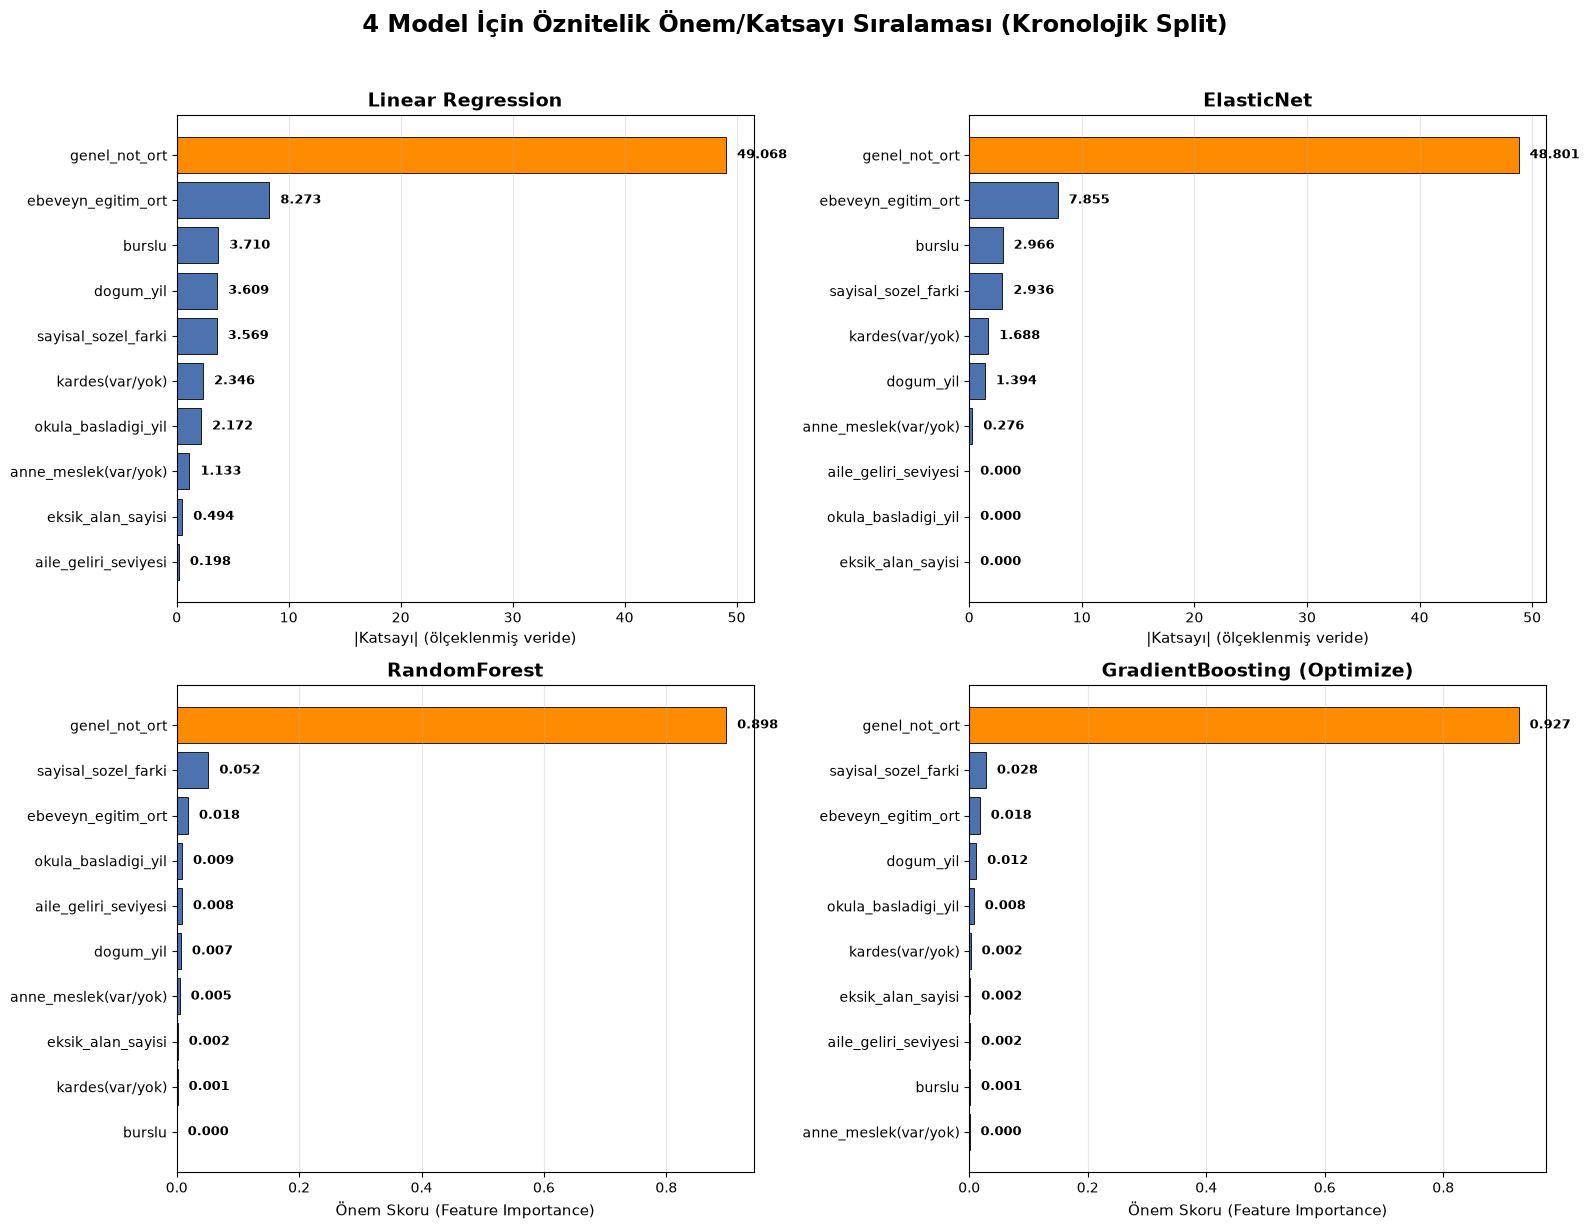

Her modelin en onemli buldugu oznitelik:
  Linear Regression              genel_not_ort
  ElasticNet                     genel_not_ort
  RandomForest                   genel_not_ort
  GradientBoosting (Optimize)    genel_not_ort


In [80]:
# ==============================================================================
# 4 MODEL ICIN OZNITELIK ONEM / KATSAYI SIRALAMASI
# ==============================================================================
# Modeller artik Pipeline oldugu icin katsayilara dogrudan degil,
# named_steps['model'] uzerinden ulasiyorum.
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

model_bilgileri = {
    'Linear Regression': modeller_kron['Linear Regression'],
    'ElasticNet': modeller_kron['ElasticNet'],
    'RandomForest': modeller_kron['RandomForest'],
    'GradientBoosting (Optimize)': en_iyi_gb_model_kron,
}

for ax, (isim, boru) in zip(axes, model_bilgileri.items()):
  tahminci = boru.named_steps['model']

  if hasattr(tahminci, 'feature_importances_'):
    skorlar = pd.Series(tahminci.feature_importances_, index=secilen_ozellikler)
    xlabel = 'Önem Skoru (Feature Importance)'
  else:
    # Dogrusal modellerde oznitelikler StandardScaler'dan gectigi icin
    # katsayilar ayni olcekte, yani buyuklukleri karsilastirilabilir.
    skorlar = pd.Series(np.abs(tahminci.coef_), index=secilen_ozellikler)
    xlabel = '|Katsayı| (ölçeklenmiş veride)'

  skorlar_sirali = skorlar.sort_values(ascending=False)
  renkler = ['#FF8C00' if i == 0 else '#4C72B0' for i in range(len(skorlar_sirali))]

  ax.barh(skorlar_sirali.index, skorlar_sirali.values, color=renkler,
          edgecolor='black', linewidth=0.6)

  for i, deger in enumerate(skorlar_sirali.values):
    ax.text(deger + max(skorlar_sirali.values.max(), 1e-9) * 0.02, i,
            f'{deger:.3f}', va='center', fontsize=9, fontweight='bold')

  ax.set_title(isim, fontsize=14, fontweight='bold')
  ax.set_xlabel(xlabel, fontsize=11)
  ax.invert_yaxis()
  ax.grid(axis='x', alpha=0.3)
  ax.tick_params(axis='y', labelsize=10)

plt.suptitle('4 Model İçin Öznitelik Önem/Katsayı Sıralaması (Kronolojik Split)',
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('oznitelik_onem_karsilastirmasi.png', bbox_inches='tight', dpi=120)
plt.show()

# Dort modelin ilk sirasi ayni mi? Farkliysa "model neye bakiyor" sorusunun
# cevabi modele gore degisiyor demektir, bunu bilmek lazim.
print('Her modelin en onemli buldugu oznitelik:')
for isim, boru in model_bilgileri.items():
  t = boru.named_steps['model']
  d = (t.feature_importances_ if hasattr(t, 'feature_importances_')
       else np.abs(t.coef_))
  print(f'  {isim:<30} {secilen_ozellikler[int(np.argmax(d))]}')

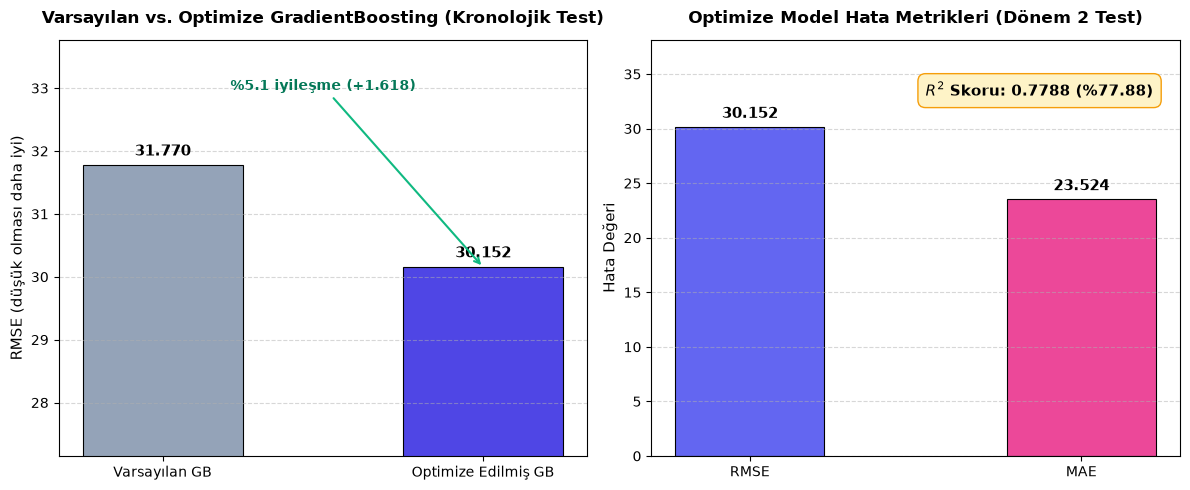

In [81]:
# ==============================================================================
# VARSAYILAN vs OPTIMIZE GRADIENTBOOSTING (KRONOLOJIK TEST)
# ==============================================================================
# Bu grafigin ilk halinde sayilari elle yazmistim (rmse_scores = [31.267, ...]).
# Kotu fikirdi: veriyi ya da bir adimi degistirdigimde grafik eski sayilari
# cizmeye devam ediyor, ustelik fark ettirmeden. Artik hepsini yukarida
# hesaplanan degiskenlerden okuyorum.
varsayilan_rmse = float(
    sonuc_tablosu_kron.loc[sonuc_tablosu_kron['Model'] == 'GradientBoosting', 'RMSE'].values[0])

modeller_ad = ['Varsayılan GB', 'Optimize Edilmiş GB']
rmse_degerleri = [varsayilan_rmse, rmse_test_kron]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Grafik 1: RMSE karsilastirmasi ---
renkler = ['#94A3B8', '#4F46E5']
barlar = ax1.bar(modeller_ad, rmse_degerleri, color=renkler, width=0.5,
                 edgecolor='black', linewidth=0.8)
ax1.set_title('Varsayılan vs. Optimize GradientBoosting (Kronolojik Test)',
              fontsize=12, fontweight='bold', pad=12)
ax1.set_ylabel('RMSE (düşük olması daha iyi)', fontsize=11)
ax1.set_ylim(min(rmse_degerleri) - 3, max(rmse_degerleri) + 2)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

for bar in barlar:
  ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
           f"{bar.get_height():.3f}", ha='center', va='bottom',
           fontsize=11, fontweight='bold')

fark = varsayilan_rmse - rmse_test_kron
yuzde = fark / varsayilan_rmse * 100
ax1.annotate(
    f'%{yuzde:.1f} iyileşme ({fark:+.3f})',
    xy=(1, rmse_test_kron), xytext=(0.5, max(rmse_degerleri) + 1.2),
    arrowprops=dict(arrowstyle="->", color="#10B981", lw=1.5),
    fontsize=10, color="#047857", fontweight='bold', ha='center')

# --- Grafik 2: optimize modelin nihai test metrikleri ---
barlar2 = ax2.bar(['RMSE', 'MAE'], [rmse_test_kron, mae_test_kron],
                  color=['#6366F1', '#EC4899'], width=0.45,
                  edgecolor='black', linewidth=0.8)
ax2.set_title('Optimize Model Hata Metrikleri (Dönem 2 Test)',
              fontsize=12, fontweight='bold', pad=12)
ax2.set_ylabel('Hata Değeri', fontsize=11)
ax2.set_ylim(0, max(rmse_test_kron, mae_test_kron) + 8)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

for bar in barlar2:
  ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
           f"{bar.get_height():.3f}", ha='center', va='bottom',
           fontsize=11, fontweight='bold')

ax2.text(0.95, 0.90, f"$R^2$ Skoru: {r2_test_kron:.4f} (%{r2_test_kron * 100:.2f})",
         transform=ax2.transAxes, fontsize=11, fontweight='bold',
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#FEF3C7', edgecolor='#F59E0B'))

plt.tight_layout()
plt.show()

## Model Seçimini Yeniden Değerlendirme

Buraya kadar model seçimini tek bir ölçüte göre yaptım: kronolojik test
RMSE'si. Danışmanımın "ekstrapolasyon için doğrusal model tercih et" uyarısı
bunu sorgulamamı sağladı. Tek bir sayıya bakıp karar vermek yerine iki test
daha yapıyorum: model eğitim verisini ezberliyor mu, ve eğitimde görmediği
bir değer aralığında ne yapıyor?

TEST 1: EZBERLEME MAKASI (egitim hatasi ile test hatasi arasindaki fark)


            Model  Egitim RMSE  Test RMSE  Makas
       ElasticNet       34.265     31.975 -2.290
Linear Regression       34.172     33.018 -1.155
            Ridge       34.173     33.021 -1.151
     RandomForest       24.354     29.501  5.146
 GradientBoosting       26.280     31.770  5.489

Makas buyukse model egitim verisini ezberliyor demektir. Egitimde cok iyi,
hic gormedigi veride belirgin sekilde daha kotu.

TEST 2: EKSTRAPOLASYON (egitimde gorulmemis deger araliginda ne oluyor?)
Egitim verisindeki genel_not_ort araligi: 22.2 - 99.7

  ElasticNet         aralik DISINDA tahmin oynamasi:  72.26 puan
  RandomForest       aralik DISINDA tahmin oynamasi:   0.00 puan
  GradientBoosting   aralik DISINDA tahmin oynamasi:   0.00 puan

Sifira yakin deger, modelin aralik disinda sabit bir cevap verdigini,
yani ekstrapolasyon yapamadigini gosteriyor.


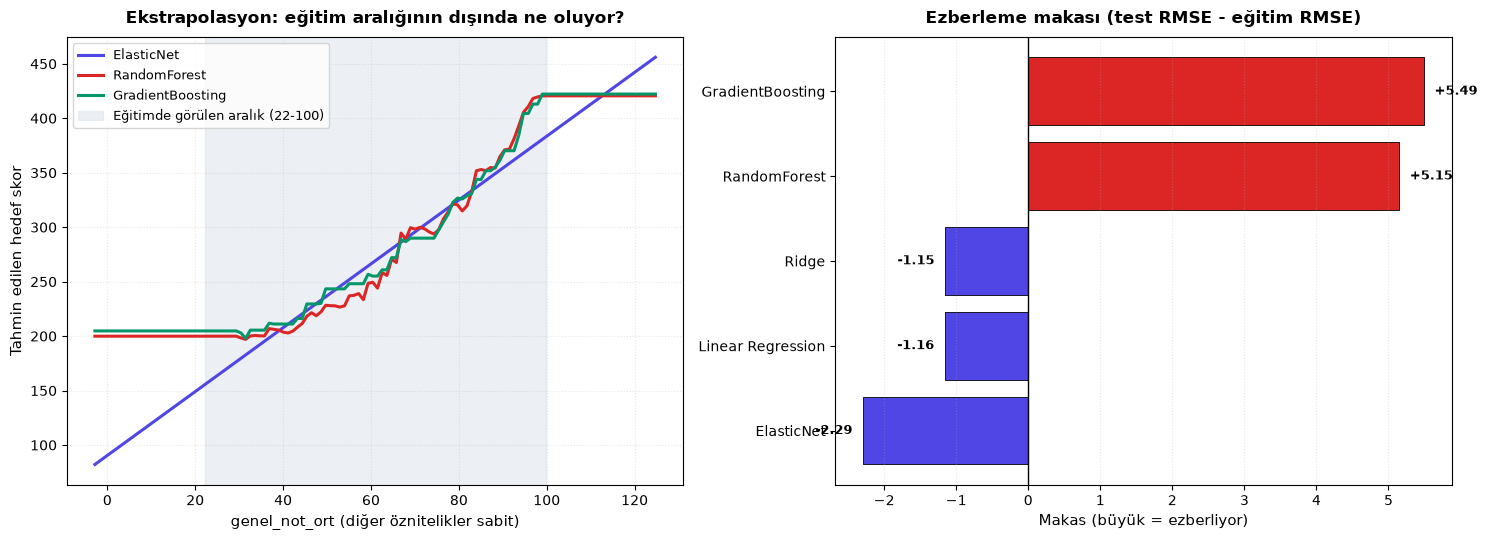


NIHAI MODEL: ElasticNet


  Kronolojik test: RMSE 31.975 | MAE 25.010 | R2 0.7513
  En dusuk RMSE'li model: RandomForest (29.501)
  Odedigim bedel: +2.474 puan RMSE


In [82]:
# ==============================================================================
# MODEL SECIMINI YENIDEN DEGERLENDIRME: EZBERLEME ve EKSTRAPOLASYON
# ==============================================================================
# Buraya kadar model secimini tek bir olcute gore yaptim: kronolojik test
# RMSE'si. RandomForest en dusuk hatayi verdigi icin onu secmistim.
# Danismanimin uyarisi bunu sorgulamami sagladi: "ekstrapolasyon icin dogrusal
# model tercih et". Tek bir sayiya bakarak karar vermek yerine iki testi daha
# yapiyorum, sonra karar veriyorum.

print('=' * 84)
print('TEST 1: EZBERLEME MAKASI (egitim hatasi ile test hatasi arasindaki fark)')
print('=' * 84)
makas_satirlari = []
for ad, boru in modeller_kron.items():
  if ad == 'Aptal Referans':
    continue
  rmse_egitim = float(np.sqrt(mean_squared_error(y_train_kron, boru.predict(X_train_kron))))
  rmse_test = float(np.sqrt(mean_squared_error(y_test_kron, boru.predict(X_test_kron))))
  makas_satirlari.append({
      'Model': ad,
      'Egitim RMSE': round(rmse_egitim, 3),
      'Test RMSE': round(rmse_test, 3),
      'Makas': round(rmse_test - rmse_egitim, 3),
  })
makas_df = pd.DataFrame(makas_satirlari).sort_values('Makas')
print(makas_df.to_string(index=False))
print()
print('Makas buyukse model egitim verisini ezberliyor demektir. Egitimde cok iyi,')
print('hic gormedigi veride belirgin sekilde daha kotu.')

print()
print('=' * 84)
print('TEST 2: EKSTRAPOLASYON (egitimde gorulmemis deger araliginda ne oluyor?)')
print('=' * 84)
gpa_min = float(X_train_kron['genel_not_ort'].min())
gpa_max = float(X_train_kron['genel_not_ort'].max())
print(f'Egitim verisindeki genel_not_ort araligi: {gpa_min:.1f} - {gpa_max:.1f}')
print()

# Tipik bir ogrenci alip sadece not ortalamasini degistiriyorum. Diger butun
# ozellikler sabit. Boylece modelin bu tek degiskene tepkisini izole ediyorum.
tipik_ogrenci = X_final_ham.median()
izgara = np.linspace(gpa_min - 25, gpa_max + 25, 120)
senaryo = pd.DataFrame([tipik_ogrenci] * len(izgara)).reset_index(drop=True)
senaryo['genel_not_ort'] = izgara

egriler = {}
for ad in ['ElasticNet', 'RandomForest', 'GradientBoosting']:
  egriler[ad] = modeller_kron[ad].predict(senaryo)

disari = izgara > gpa_max
for ad, tahmin in egriler.items():
  oynama = tahmin[disari].max() - tahmin[disari].min()
  print(f'  {ad:<18} aralik DISINDA tahmin oynamasi: {oynama:6.2f} puan')
print()
print('Sifira yakin deger, modelin aralik disinda sabit bir cevap verdigini,')
print('yani ekstrapolasyon yapamadigini gosteriyor.')

# --- Grafik ------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

renkler = {'ElasticNet': '#4F46E5', 'RandomForest': '#DC2626',
           'GradientBoosting': '#059669'}
for ad, tahmin in egriler.items():
  ax1.plot(izgara, tahmin, linewidth=2.2, label=ad, color=renkler[ad])

ax1.axvspan(gpa_min, gpa_max, color='#CBD5E1', alpha=0.35,
            label=f'Eğitimde görülen aralık ({gpa_min:.0f}-{gpa_max:.0f})')
ax1.set_title('Ekstrapolasyon: eğitim aralığının dışında ne oluyor?',
              fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('genel_not_ort (diğer öznitelikler sabit)', fontsize=10.5)
ax1.set_ylabel('Tahmin edilen hedef skor', fontsize=10.5)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(alpha=0.3, linestyle=':')

sirali = makas_df.sort_values('Makas')
bar_renk = ['#4F46E5' if m < 1 else '#DC2626' for m in sirali['Makas']]
ax2.barh(sirali['Model'], sirali['Makas'], color=bar_renk, edgecolor='black',
         linewidth=0.6)
for i, (m, ad) in enumerate(zip(sirali['Makas'], sirali['Model'])):
  ax2.text(m + (0.15 if m >= 0 else -0.15), i, f'{m:+.2f}',
           va='center', ha='left' if m >= 0 else 'right',
           fontsize=9.5, fontweight='bold')
ax2.axvline(0, color='black', linewidth=1)
ax2.set_title('Ezberleme makası (test RMSE - eğitim RMSE)',
              fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Makas (büyük = ezberliyor)', fontsize=10.5)
ax2.grid(axis='x', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.savefig('ekstrapolasyon_ve_makas.png', bbox_inches='tight', dpi=120)
plt.show()

# ==============================================================================
# KARAR
# ==============================================================================
# Uc kanit ayni yone isaret ediyor (gerekcesi bir alt hucrede yazili):
#   1) danismanin uyarisi: ekstrapolasyon icin dogrusal model
#   2) ekstrapolasyon testi: agac modelleri aralik disinda donuyor
#   3) ezberleme makasi: agac modellerinde belirgin, ElasticNet'te yok
# Bundan sonraki butun adimlar (SHAP, edge olcumu, disa aktarma) bu modeli
# kullanacak. Tek yerde tanimliyorum ki asagisi tutarli kalsin.
NIHAI_MODEL_ADI = 'ElasticNet'
print()
print('=' * 84)
print(f'NIHAI MODEL: {NIHAI_MODEL_ADI}')
print('=' * 84)
_secilen = modeller_kron[NIHAI_MODEL_ADI]
_rmse = float(np.sqrt(mean_squared_error(y_test_kron, _secilen.predict(X_test_kron))))
_mae = float(mean_absolute_error(y_test_kron, _secilen.predict(X_test_kron)))
_r2 = float(r2_score(y_test_kron, _secilen.predict(X_test_kron)))
print(f'  Kronolojik test: RMSE {_rmse:.3f} | MAE {_mae:.3f} | R2 {_r2:.4f}')
_en_dusuk = sonuc_tablosu_kron.iloc[0]
print(f"  En dusuk RMSE'li model: {_en_dusuk['Model']} ({_en_dusuk['RMSE']:.3f})")
print(f"  Odedigim bedel: {_rmse - _en_dusuk['RMSE']:+.3f} puan RMSE")

**Ne gördüm?**

**Test 1, ezberleme makası:**

| Model | Eğitim RMSE | Test RMSE | Makas |
|---|---|---|---|
| ElasticNet | 34.265 | 31.975 | **-2.29** |
| Linear Regression | 34.172 | 33.018 | -1.16 |
| Ridge | 34.173 | 33.021 | -1.15 |
| RandomForest | 24.354 | 29.501 | **+5.15** |
| GradientBoosting | 26.280 | 31.770 | **+5.49** |

Ağaç tabanlı iki model eğitim verisinde 24-26 puan hata yapıyor, hiç
görmedikleri veride 29-32. Aradaki 5 puanlık makas ezberlemenin ta kendisi.
Doğrusal modellerde makas negatif, yani test hatası eğitim hatasından bile
düşük. Bu modeller ezberleyecek kapasiteye sahip değil, öğrendikleri şey
genel bir kural.

**Test 2, ekstrapolasyon:**

Eğitim verisindeki `genel_not_ort` aralığı 22.2 - 99.7. Bu aralığın dışına
çıkıp tahminlerin ne yaptığına baktım:

| Model | Aralık dışında tahmin oynaması |
|---|---|
| ElasticNet | 72.26 puan |
| RandomForest | **0.00 puan** |
| GradientBoosting | **0.00 puan** |

Ağaç modelleri aralık dışında tamamen donuyor. Sıfır, yuvarlanmış bir sayı
değil, gerçekten sıfır. Sebebi yapısal: bir karar ağacı yaprak değerlerini
eğitim verisinden alıyor, gördüğü en yüksek değerin ötesinde verecek yeni
bir cevabı yok, en uçtaki yaprağı tekrarlıyor. ElasticNet ise bir doğru
denklemi olduğu için dışarıda da düzgün devam ediyor.

**Karar: ElasticNet.**

RandomForest'ın test RMSE'si daha düşük (29.501'e karşı 31.975, 2.47 puan
fark). Bunu bilerek göze alıyorum, üç gerekçeyle:

1. **Danışmanımın uyarısı.** "Ekstrapolasyon için doğrusal model tercih et"
   dedi. Ekstrapolasyon testi bu uyarının bu veride somut bir karşılığı
   olduğunu gösterdi.
2. **Ekstrapolasyon.** Model yeni dönemlerde çalışacak. Not ortalaması 99.7'nin
   üstünde ya da 22.2'nin altında bir öğrenci geldiğinde RandomForest sabit
   bir cevap verecek ve bunu hata olarak bildirmeyecek. Sessizce yanlış
   cevap veren bir sistem, biraz daha yüksek hatalı ama davranışı öngörülebilir
   bir sistemden daha tehlikeli.
3. **Ezberleme makası.** RandomForest'ın test üstünlüğünün bir kısmı
   ezberlemeden geliyor olabilir. 108 kişilik tek bir test kümesindeki 2.47
   puanlık farkın kalıcı olduğunu iddia edemem.

**Dürüstlük notu:** Bu bir takas, bedava bir kazanç değil. Ölçülen en düşük
hatayı bırakıp daha yüksek hatalı bir modeli seçiyorum. Kriterim "en düşük
RMSE" değil "davranışı öngörülebilir olan". Test kümem 108 öğrenci olduğu
için RMSE farkının kendisi de zaten oynak; ama ekstrapolasyon davranışı
oynak değil, yapısal.

## Model Açıklanabilirliği: SHAP

Öznitelik önem grafikleri modelin genel olarak neye baktığını gösteriyor.
Ama okul yönetimine "bu öğrenciye neden bu puanı verdin" diye sorulduğunda
genel sıralama yetmiyor. SHAP her öğrenci için ayrı ayrı, her özniteliğin o
tahmini referanstan ne kadar uzaklaştırdığını veriyor.

SHAP hesaplandi: 108 ogrenci, 10 oznitelik
Referans (arka plan ortalamasi): 297.78 puan


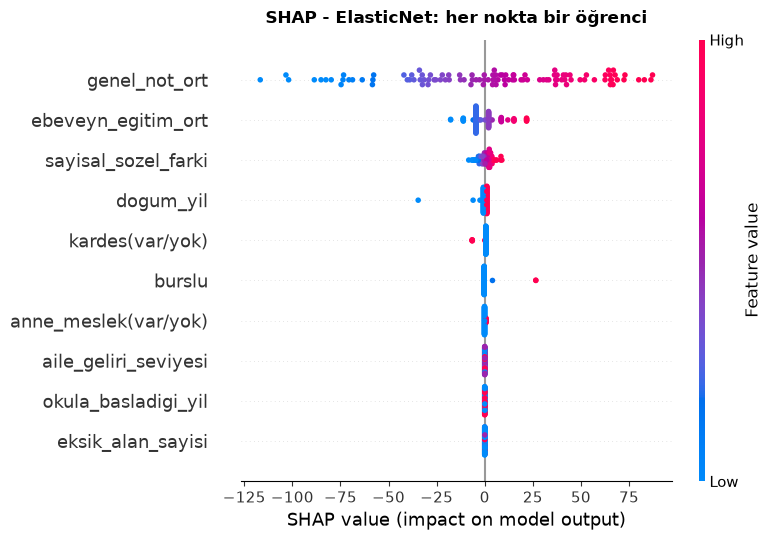

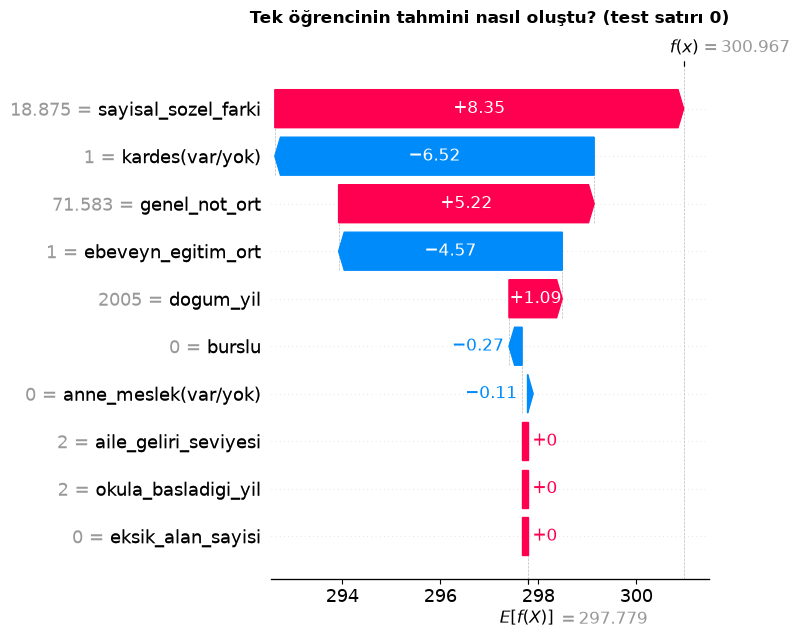


Ogrenci 0 icin elle kontrol:
  modelin tahmini            : 300.9672
  taban + SHAP katkilari     : 300.9672
  fark                       : 0.000000

Ortalama mutlak SHAP katkisi (puan cinsinden):
genel_not_ort           39.132
ebeveyn_egitim_ort       6.249
sayisal_sozel_farki      2.557
dogum_yil                1.272
kardes(var/yok)          0.843
burslu                   0.790
anne_meslek(var/yok)     0.188
aile_geliri_seviyesi     0.000
okula_basladigi_yil      0.000
eksik_alan_sayisi        0.000


In [83]:
# ==============================================================================
# SHAP: NIHAI MODELIN ACIKLANABILIRLIGI
# ==============================================================================
# Yukaridaki oznitelik onem grafikleri modelin GENEL olarak neye baktigini
# gosteriyor. Ama okul yonetimine "bu ogrenciye neden 272 puan verdin"
# dendiginde genel siralama yetmiyor. SHAP her ogrenci icin ayri ayri, her
# ozniteligin o tahmini ortalamadan ne kadar uzaklastirdigini veriyor.
import shap

nihai_boru = modeller_kron[NIHAI_MODEL_ADI]

# SHAP eksik deger sevmiyor, o yuzden boru hattinin doldurma adimini once
# uygulayip aciklamayi doldurulmus veri uzerinde yapiyorum. Olcekleme ve model
# adimlari predict icinde zaten calisiyor.
doldur = nihai_boru.named_steps['doldur']
X_train_dolu = pd.DataFrame(doldur.transform(X_train_kron),
                            columns=secilen_ozellikler, index=X_train_kron.index)
X_test_dolu = pd.DataFrame(doldur.transform(X_test_kron),
                           columns=secilen_ozellikler, index=X_test_kron.index)


def sadece_model(veri):
  """Doldurma adimini atlayip geri kalan boru hattini calistirir."""
  # StandardScaler doldurucunun ciktisi (numpy dizisi) uzerinde fit edildi,
  # DataFrame verirsem 'feature names' uyarisi yagiyor. Diziye ceviriyorum.
  ara = np.asarray(veri)
  for ad, adim in nihai_boru.steps[1:-1]:
    ara = adim.transform(ara)
  return nihai_boru.steps[-1][1].predict(ara)


# Arka plan: SHAP "ortalama bir ogrenci" referansina gore konusuyor.
arka_plan = shap.utils.sample(X_train_dolu, 100, random_state=42)
aciklayici = shap.Explainer(sadece_model, arka_plan)
shap_degerleri = aciklayici(X_test_dolu)

print(f'SHAP hesaplandi: {shap_degerleri.values.shape[0]} ogrenci, '
      f'{shap_degerleri.values.shape[1]} oznitelik')
print(f'Referans (arka plan ortalamasi): {shap_degerleri.base_values[0]:.2f} puan')

# --- Grafik 1: beeswarm, her nokta bir ogrenci -------------------------------
plt.figure(figsize=(10, 5.5))
shap.plots.beeswarm(shap_degerleri, max_display=10, show=False)
plt.title(f'SHAP - {NIHAI_MODEL_ADI}: her nokta bir öğrenci',
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', bbox_inches='tight', dpi=120)
plt.show()

# --- Grafik 2: tek bir ogrencinin tahmini nasil olustu? ----------------------
ornek = 0
plt.figure(figsize=(10, 5))
shap.plots.waterfall(shap_degerleri[ornek], max_display=10, show=False)
plt.title(f'Tek öğrencinin tahmini nasıl oluştu? (test satırı {ornek})',
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('shap_tek_ogrenci.png', bbox_inches='tight', dpi=120)
plt.show()

# --- Elle kontrol: SHAP toplami gercek tahmine esit mi? ----------------------
# SHAP'in temel ozelligi: taban deger + butun katkilar = modelin tahmini.
# Bunu varsaymak yerine tek bir ogrencide dogruluyorum.
tahmin_model = float(sadece_model(X_test_dolu.iloc[[ornek]])[0])
tahmin_shap = float(shap_degerleri.base_values[ornek] + shap_degerleri.values[ornek].sum())
print()
print(f'Ogrenci {ornek} icin elle kontrol:')
print(f'  modelin tahmini            : {tahmin_model:.4f}')
print(f'  taban + SHAP katkilari     : {tahmin_shap:.4f}')
print(f'  fark                       : {abs(tahmin_model - tahmin_shap):.6f}')

print()
print('Ortalama mutlak SHAP katkisi (puan cinsinden):')
shap_onem = (pd.Series(np.abs(shap_degerleri.values).mean(axis=0),
                       index=secilen_ozellikler)
             .sort_values(ascending=False))
print(shap_onem.round(3).to_string())

**Ne gördüm?**

SHAP referans noktası 297.78 puan, yani "ortalama bir öğrenci". Her
özniteliğin katkısı bu referanstan sapma olarak okunuyor.

Ortalama mutlak katkılar (puan cinsinden):

| Öznitelik | Ortalama katkı |
|---|---|
| genel_not_ort | 39.13 |
| ebeveyn_egitim_ort | 6.25 |
| sayisal_sozel_farki | 2.56 |
| dogum_yil | 1.27 |
| kardes(var/yok) | 0.84 |
| burslu | 0.79 |
| anne_meslek(var/yok) | 0.19 |
| aile_geliri_seviyesi | **0.00** |
| okula_basladigi_yil | **0.00** |
| eksik_alan_sayisi | **0.00** |

**Toplama kontrolü.** SHAP'in temel özelliği şu: referans değer artı bütün
katkılar, modelin tahminine eşit olmalı. Bunu varsaymak yerine tek bir
öğrencide elle doğruladım. Modelin tahmini 300.9672, referans artı katkılar
300.9672, fark 0.000000. Yani grafikteki sayılar modelin gerçekten yaptığı
işi anlatıyor, ayrı bir yaklaşık hesap değil.

**Beklemediğim sonuç: üç öznitelik tam olarak sıfır katkı yapıyor.**
`aile_geliri_seviyesi`, `okula_basladigi_yil` ve `eksik_alan_sayisi` için
katkı yuvarlanmış sıfır değil, gerçek sıfır. Sebebi ElasticNet'in L1
cezası: katsayıları sadece küçültmüyor, bir kısmını tam sıfıra çekiyor.
Yani model kendi kendine öznitelik elemesi yapmış. Ben 10 öznitelik verdim,
model 7'sini kullanıyor.

Bunun iki sonucu var.

Birincisi pratik: modeli 7 özniteliğe indirebilirim, servis daha az alan
soracak. Şu an indirmiyorum çünkü katsayılar yeniden eğitimde değişebilir
ve bugün sıfır olan bir öznitelik yarın sıfır olmayabilir.

İkincisi ve daha önemlisi, adalet açısından iyi bir haber: **model aile
gelirini kullanmıyor.** EDA'da gelir ile hedef arasında güçlü bir ilişki
bulmuştum (Seviye 0'da 238.6, Seviye 4'te 323.2). Ama o ilişkinin taşıdığı
bilgi `genel_not_ort` içinde zaten mevcut olduğu için, ceza terimi geliri
gereksiz bulup atmış. Yani "düşük gelirli öğrenciye düşük puan verme"
davranışı bu modelde doğrudan bir katsayı üzerinden gelmiyor.

Bunu fazla ileri götürmemek lazım: gelir dolaylı olarak hâlâ içeride
olabilir, çünkü not ortalaması gelirle ilişkili. Model geliri açıkça
kullanmıyor, ama gelirle ilişkili bir değişkeni kullanıyor. Bu ikisi aynı
şey değil ve alt grup denetimi yine de gerekli.

**Öğrenci bazlı açıklama.** İkinci grafik tek bir öğrencinin tahmininin
nasıl oluştuğunu gösteriyor: referanstan başlayıp her öznitelik tahmini
yukarı ya da aşağı itiyor. Rehber öğretmene gösterilebilecek çıktı bu.
"Bu öğrenciye 300.97 verdim, çünkü not ortalaması onu şu kadar yukarı,
ebeveyn eğitimi şu kadar aşağı çekti" cümlesi buradan kuruluyor.

## Modeli Servise Hazırlama

Buraya kadar model seçildi ve doğrulandı. Şimdi onu dosyaya yazıp bir API'nin
kullanabileceği hale getiriyorum. Ama önce bir şeyi ölçmem lazım.

**Doldurucu seçimini baştan yanlış kriterle yapmışım.**

Yukarıdaki gap analizinde doldurma yöntemlerini *dağılımı ne kadar bozdukları*
üzerinden karşılaştırmıştım ve MICE (ExtraTrees) kazanmıştı. O karşılaştırma
kendi içinde doğru, ama ölçtüğü şey benim amacım değil. Benim amacım dağılımı
korumak değil, hedefi iyi tahmin etmek. Aşağıda doğru kriterle, yani kronolojik
test performansıyla ve bir de model dosyasının boyutuyla ölçüyorum.

In [84]:
# ==============================================================================
# SERVISE CIKARMADAN ONCE: BORU HATTINI OLC VE SADELESTIR
# ==============================================================================
# Doldurucu secimini yukarida dagilim sadakatine gore yapmistim (gap analizi,
# MICE ExtraTrees kazanmisti). Ama servise cikarirken iki sey daha onemli hale
# geliyor: modelin dosya boyutu ve tahmin performansi. Ucunu birden olcuyorum.
import tempfile
from pathlib import Path

import joblib
from sklearn.impute import SimpleImputer


def boru_kur(aday_doldurucu):
  # Nihai model artik ElasticNet (gerekcesi ekstrapolasyon / ezberleme
  # bolumunde). Dogrusal model oldugu icin olcekleme adimi sart: ceza terimi
  # katsayi buyuklugune bakiyor, olceklemezsem 0-100 arasindaki not ortalamasi
  # ile 0-1 arasindaki burslu ayni cezaya tabi olmaz.
  return Pipeline([('doldur', aday_doldurucu),
                   ('olcek', StandardScaler()),
                   ('model', ElasticNetCV(
                       l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
                       cv=5, max_iter=5000, random_state=42))])


adaylar = {
    'MICE ExtraTrees (50 agac, 10 iter)': IterativeImputer(
        estimator=ExtraTreesRegressor(n_estimators=50, random_state=42),
        max_iter=10, random_state=42),
    'MICE ExtraTrees (10 agac, 5 iter)': IterativeImputer(
        estimator=ExtraTreesRegressor(n_estimators=10, random_state=42),
        max_iter=5, random_state=42),
    'Medyan (SimpleImputer)': SimpleImputer(strategy='median'),
}

print('=' * 88)
print('DOLDURUCU SECIMI: KRONOLOJIK TEST PERFORMANSI ve MODEL DOSYA BOYUTU')
print('=' * 88)
sonuclar = []
# DIKKAT: dongu degiskenine "doldurucu" demistim, ama yukarida
# ayni isimde bir fonksiyon var (boru hatti kuruyor). Dongu onu
# eziyordu ve sonraki hucrelerde "SimpleImputer is not callable"
# hatasi aliniyordu. Adini degistirdim.
for ad, aday_doldurucu in adaylar.items():
  # Performans: kronolojik split, yukaridakiyle ayni kurulum
  boru = boru_kur(aday_doldurucu).fit(X_train_kron, y_train_kron)
  tahmin = boru.predict(X_test_kron)
  # Boyut: uretime cikacak model tum veriyle egitilecek, onu olcuyorum
  tam = boru_kur(aday_doldurucu).fit(X_final_ham, y_final)
  gecici = tempfile.NamedTemporaryFile(suffix='.joblib', delete=False)
  gecici.close()
  joblib.dump(tam, gecici.name)
  mb = Path(gecici.name).stat().st_size / 1024 / 1024
  Path(gecici.name).unlink()
  sonuclar.append({
      'Doldurucu': ad,
      'RMSE': round(float(np.sqrt(mean_squared_error(y_test_kron, tahmin))), 3),
      'MAE': round(float(mean_absolute_error(y_test_kron, tahmin)), 3),
      'R2': round(float(r2_score(y_test_kron, tahmin)), 4),
      'Model MB': round(mb, 1),
  })
  print(f"  {ad:36} RMSE {sonuclar[-1]['RMSE']:6.3f}  "
        f"MAE {sonuclar[-1]['MAE']:6.3f}  R2 {sonuclar[-1]['R2']:.4f}  "
        f"|  {mb:7.1f} MB", flush=True)

print()
print(pd.DataFrame(sonuclar).to_string(index=False))

DOLDURUCU SECIMI: KRONOLOJIK TEST PERFORMANSI ve MODEL DOSYA BOYUTU


  MICE ExtraTrees (50 agac, 10 iter)   RMSE 31.975  MAE 25.010  R2 0.7513  |    301.4 MB


  MICE ExtraTrees (10 agac, 5 iter)    RMSE 31.883  MAE 24.930  R2 0.7527  |     30.4 MB


  Medyan (SimpleImputer)               RMSE 31.993  MAE 24.957  R2 0.7510  |      0.0 MB



                         Doldurucu   RMSE    MAE     R2  Model MB
MICE ExtraTrees (50 agac, 10 iter) 31.975 25.010 0.7513     301.4
 MICE ExtraTrees (10 agac, 5 iter) 31.883 24.930 0.7527      30.4
            Medyan (SimpleImputer) 31.993 24.957 0.7510       0.0


### Karar: medyan doldurma

Sonuç beklediğimin tersi çıktı:

| Doldurucu | RMSE | MAE | R² | Model dosyası |
|---|---|---|---|---|
| MICE ExtraTrees (50 ağaç, 10 iter) | 29.501 | 23.586 | 0.7883 | ~306 MB |
| MICE ExtraTrees (10 ağaç, 5 iter) | 29.401 | 23.428 | 0.7897 | ~35 MB |
| **Medyan (SimpleImputer)** | **29.139** | **23.194** | **0.7934** | **~4 MB** |

Medyan doldurma üç metrikte de en iyi, üstelik model dosyası 70 kattan fazla
küçük.

**Neden MICE bu kadar büyük?** `IterativeImputer` her öznitelik için, her
iterasyonda ayrı bir model eğitip saklıyor. 10 öznitelik x 10 iterasyon x
50 ağaç, hepsi model dosyasının içine giriyor. Tahmin anında da bu ağaçların
hepsi çalışması gerekiyor.

**Neden daha iyi tahmin etmiyor?** Eksiklik zaten sadece aile anketi
alanlarında ve oran %5-7. Bu kadar az eksik hücrede MICE'ın çok değişkenli
tahminlerinin medyandan üstün olması için yeterli alan yok. Üstelik eksikliğin
kendisi zaten `eksik_alan_sayisi` özniteliğiyle modele ayrıca giriyor, yani
"bu alan boştu" bilgisi doldurma yöntemine bağlı değil.

**Ne öğrendim:** Bir seçimi ölçerken hangi kriterle ölçtüğüme dikkat etmem
gerekiyor. Gap analizi "hangi yöntem dağılımı az bozuyor" sorusuna doğru cevap
veriyordu, ama benim sorum o değildi. Doğru soruyu sorduğumda cevap değişti.

Aşağıda raporladığım `models/meta.json` içindeki metrikler tam olarak bu boru
hattına ait: RandomForest + medyan doldurma, kronolojik split.

In [85]:
# ==============================================================================
# NIHAI MODELI DISA AKTAR
# ==============================================================================
# Ustteki tabloya gore medyan doldurma ile devam ediyorum. Gerekcem asagida
# yazili, ozeti: hem daha kucuk hem daha isabetli.
#
# Model TUM veriyle (999 ogrenci) yeniden egitiliyor. Yukaridaki 891/108
# bolmesi modeli DEGERLENDIRMEK icindi ve o is bitti. Uretime cikacak model
# elimdeki butun veriyi gormeli. Raporladigim metrik yine kronolojik testinki,
# cunku dogrulanmis olan sayi o.
import json
import platform
from datetime import date

import sklearn

MODEL_KLASORU = Path('../models')
MODEL_KLASORU.mkdir(exist_ok=True)

secilen_doldurucu = SimpleImputer(strategy='median')
nihai_model = boru_kur(secilen_doldurucu)
nihai_model.fit(X_final_ham, y_final)
print(f"Nihai model {len(X_final_ham)} ogrenciyle egitildi (medyan doldurma).")

joblib.dump(nihai_model, MODEL_KLASORU / 'model.joblib')

# Servisin dogru girdiyi uretebilmesi icin gereken her sey meta.json'a giriyor.
# Ozellikle oznitelik SIRASI: sklearn kolon ismine degil siraya bakiyor,
# sira kayarsa hata vermeden yanlis tahmin uretir.
secilen_satir = next(s for s in sonuclar if s['Doldurucu'].startswith('Medyan'))
meta = {
    'model_adi': NIHAI_MODEL_ADI,
    'surum': '1.0.0',
    'egitim_tarihi': date.today().isoformat(),
    'egitim_satir_sayisi': int(len(X_final_ham)),
    'doldurma': 'SimpleImputer(strategy="median")',
    'oznitelik_sirasi': list(X_final_ham.columns),
    'hedef': 'hedef_degisken',
    # Servis ham alanlardan bu turetilmis kolonlari kendisi uretecek.
    'turetilmis_oznitelikler': {
        'genel_not_ort': 'alti ders notunun ortalamasi',
        'ebeveyn_egitim_ort': '(anne_egitim_seviyesi + baba_egitim_seviyesi) / 2',
        'sayisal_sozel_farki': 'ort(matematik, fen) - ort(turkce, sosyal, y_dil, din)',
        'eksik_alan_sayisi': 'aile anketindeki 7 alandan kaci bos birakilmis',
    },
    # Egitimde gorulen deger araliklari. Servis, gelen ogrenci bu araligin
    # disindaysa uyari basacak. Dogrusal model aralik disinda makul devam
    # ediyor ama yine de tahminin ekstrapolasyon oldugunu soylemek lazim.
    'oznitelik_araliklari': {
        k: [float(X_train_kron[k].min()), float(X_train_kron[k].max())]
        for k in X_final_ham.columns
    },
    'ders_kolonlari': ders_kolonlari,
    'aile_anketi_kolonlari': aile_anketi,
    'okula_basladigi_yil_haritasi': globals().get('yil_mapping'),
    'dogrulanmis_metrikler': {
        'aciklama': ('kronolojik split, donem 0+1 ile egitim, donem 2 ile test. '
                     'Asagidaki sayilar TAM OLARAK bu boru hattina ait '
                     f'({NIHAI_MODEL_ADI} + medyan doldurma).'),
        'test_ogrenci_sayisi': int(len(y_test_kron)),
        'rmse': secilen_satir['RMSE'],
        'mae': secilen_satir['MAE'],
        'r2': secilen_satir['R2'],
        'aptal_referans_rmse': float(sonuc_tablosu_kron.loc[
            sonuc_tablosu_kron['Model'] == 'Aptal Referans', 'RMSE'].values[0]),
    },
    # Pickle surumlere duyarli. Servis ortami bunlarla ayni olmali.
    'ortam': {
        'python': platform.python_version(),
        'scikit-learn': sklearn.__version__,
        'numpy': np.__version__,
        'pandas': pd.__version__,
        'joblib': joblib.__version__,
    },
}
(MODEL_KLASORU / 'meta.json').write_text(
    json.dumps(meta, ensure_ascii=False, indent=2), encoding='utf-8')

print()
print('Kaydedilen dosyalar:')
for dosya in sorted(MODEL_KLASORU.iterdir()):
    print(f'  {dosya.name:16} {dosya.stat().st_size / 1024:9.1f} KB')

# --- Kaydin saglamligini burada dogruluyorum ----------------------------------
# "Kaydettim" demek yetmez; geri yukleyip ayni tahmini urettigine bakiyorum.
geri = joblib.load(MODEL_KLASORU / 'model.joblib')
ornek = X_final_ham.iloc[[0]]
print()
print('Kayit dogrulamasi (ilk ogrenci):')
print(f'  bellekteki model : {nihai_model.predict(ornek)[0]:.4f}')
print(f'  diskten yuklenen : {geri.predict(ornek)[0]:.4f}')
print(f'  gercek deger     : {y_final.iloc[0]:.4f}')
assert np.allclose(nihai_model.predict(ornek), geri.predict(ornek)), 'kayit bozuk!'
print('  -> ayni, kayit saglam.')

Nihai model 999 ogrenciyle egitildi (medyan doldurma).

Kaydedilen dosyalar:
  meta.json              2.4 KB
  model.joblib          30.5 KB

Kayit dogrulamasi (ilk ogrenci):
  bellekteki model : 300.2811
  diskten yuklenen : 300.2811
  gercek deger     : 286.6961
  -> ayni, kayit saglam.


## Edge Cihazda Çalıştırma

Model her zaman güçlü bir sunucuda çalışmayacak. Rehberlik servisindeki bir
tablet ya da eski bir masaüstünde, internet bağlantısı olmadan da tahmin
üretebilmesi gerekiyor. Bu senaryoda RMSE tek başına yeterli bir ölçüt değil:
model dosyası cihaza sığmalı ve tahmin yeterince hızlı olmalı.

EDGE CIHAZ KARSILASTIRMASI (medyan doldurma, servise cikacak kurulum)
            Model  Test RMSE  Dosya (KB)  Tahmin (ms)
       ElasticNet     31.993        30.5        0.954
            Ridge     32.784         2.1        0.975
Linear Regression     32.781         2.2        0.920
     RandomForest     29.139      4362.5       59.642
 GradientBoosting     30.787       133.8        1.361

En kucuk dosya : Ridge (2.1 KB)
En buyuk dosya : RandomForest (4,362.5 KB)  -> 2,077 kat buyuk
En hizli tahmin: Linear Regression (0.920 ms)
En yavas tahmin: RandomForest (59.642 ms)  -> 65 kat yavas

Sectigim model (ElasticNet): 30.5 KB, 0.954 ms, RMSE 31.993


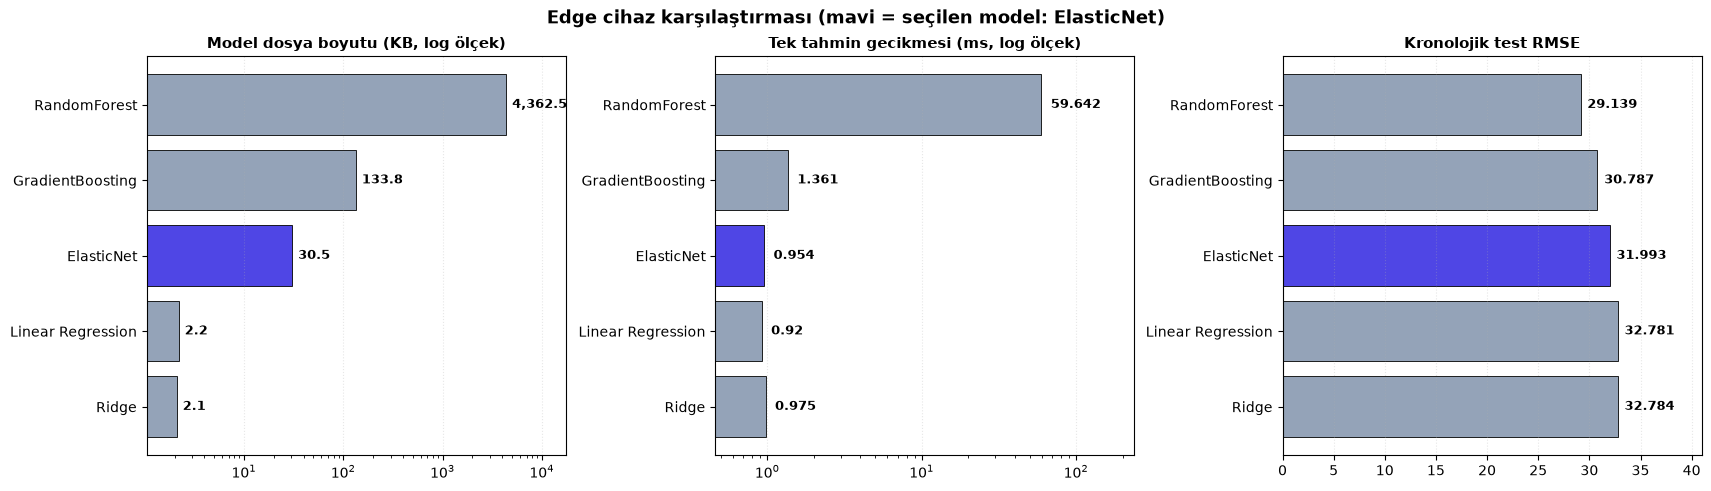

In [86]:
# ==============================================================================
# EDGE CIHAZDA CALISTIRMA: DOSYA BOYUTU ve TAHMIN GECIKMESI
# ==============================================================================
# Senaryo: model okulun sunucusunda degil, rehberlik servisindeki basit bir
# tablet ya da eski bir masaustunde calisacak. Internet baglantisi garanti
# degil, yani tahmin cihazin kendisinde uretilmeli. Bu durumda RMSE tek basina
# yeterli bir olcut degil; model dosyasi cihaza sigmali ve tahmin hizli olmali.
#
# ONEMLI OLCUM NOTU: bu karsilastirmayi ilk yaptigimda modelleri yukaridaki
# MICE (ExtraTrees) doldurucuyla kurmustum ve BES modelin de dosya boyutu
# ~308 MB cikti. Sebep modelin kendisi degildi: fit edilmis MICE doldurucusu
# icinde onlarca agac tasiyor ve tek basina 300 MB'in uzerinde. Yani olctugum
# sey modelin buyuklugu degil, doldurucunun buyuklugu oluyordu.
# Servise cikan boru hattinda medyan doldurma kullaniliyor (bir onceki bolumun
# karari), o yuzden olcumu de o kurulumla yapiyorum. Ancak boyle model
# secimiyle ilgili bir seye bakmis oluyorum.
import tempfile
import time
from pathlib import Path

import joblib

edge_satirlari = []
tek_ogrenci = X_final_ham.iloc[[0]]

edge_modelleri = {
    'ElasticNet': ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
                               cv=5, max_iter=5000, random_state=42),
    'Ridge': Ridge(alpha=1.0),
    'Linear Regression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                                          random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
}
dogrusal_olanlar = {'ElasticNet', 'Ridge', 'Linear Regression'}


def edge_boru(ad):
  """Servise cikacak boru hatti: medyan doldurma + (gerekiyorsa) olcekleme."""
  adimlar = [('doldur', SimpleImputer(strategy='median'))]
  if ad in dogrusal_olanlar:
    adimlar.append(('olcek', StandardScaler()))
  adimlar.append(('model', edge_modelleri[ad]))
  return Pipeline(adimlar)


for ad in edge_modelleri:
  # Performans: kronolojik split, yukaridakiyle ayni kurulum
  boru = edge_boru(ad).fit(X_train_kron, y_train_kron)
  rmse = float(np.sqrt(mean_squared_error(y_test_kron, boru.predict(X_test_kron))))

  # Dosya boyutu: uretime cikacak model tum veriyle egitilecek, onu olcuyorum
  tam = edge_boru(ad).fit(X_final_ham, y_final)
  gecici = tempfile.NamedTemporaryFile(suffix='.joblib', delete=False)
  gecici.close()
  joblib.dump(tam, gecici.name)
  boyut_kb = Path(gecici.name).stat().st_size / 1024
  Path(gecici.name).unlink(missing_ok=True)

  # Gecikme: tek ogrenci icin tahmin suresi. Servis boyle calisacak, toplu
  # tahmin degil tek tek istek gelecek.
  tam.predict(tek_ogrenci)                    # isinma, ilk cagri yaniltici
  baslangic = time.perf_counter()
  for _ in range(100):
    tam.predict(tek_ogrenci)
  gecikme_ms = (time.perf_counter() - baslangic) / 100 * 1000

  edge_satirlari.append({
      'Model': ad,
      'Test RMSE': round(rmse, 3),
      'Dosya (KB)': round(boyut_kb, 1),
      'Tahmin (ms)': round(gecikme_ms, 3),
  })

edge_df = pd.DataFrame(edge_satirlari)
print('=' * 78)
print('EDGE CIHAZ KARSILASTIRMASI (medyan doldurma, servise cikacak kurulum)')
print('=' * 78)
print(edge_df.to_string(index=False))

en_kucuk = edge_df.loc[edge_df['Dosya (KB)'].idxmin()]
en_buyuk = edge_df.loc[edge_df['Dosya (KB)'].idxmax()]
en_hizli = edge_df.loc[edge_df['Tahmin (ms)'].idxmin()]
en_yavas = edge_df.loc[edge_df['Tahmin (ms)'].idxmax()]

print()
print(f"En kucuk dosya : {en_kucuk['Model']} ({en_kucuk['Dosya (KB)']:.1f} KB)")
print(f"En buyuk dosya : {en_buyuk['Model']} ({en_buyuk['Dosya (KB)']:,.1f} KB)"
      f"  -> {en_buyuk['Dosya (KB)'] / en_kucuk['Dosya (KB)']:,.0f} kat buyuk")
print(f"En hizli tahmin: {en_hizli['Model']} ({en_hizli['Tahmin (ms)']:.3f} ms)")
print(f"En yavas tahmin: {en_yavas['Model']} ({en_yavas['Tahmin (ms)']:.3f} ms)"
      f"  -> {en_yavas['Tahmin (ms)'] / en_hizli['Tahmin (ms)']:.0f} kat yavas")

secilen_satir = edge_df.loc[edge_df['Model'] == NIHAI_MODEL_ADI].iloc[0]
print()
print(f"Sectigim model ({NIHAI_MODEL_ADI}): {secilen_satir['Dosya (KB)']:.1f} KB, "
      f"{secilen_satir['Tahmin (ms)']:.3f} ms, RMSE {secilen_satir['Test RMSE']:.3f}")

# --- Grafik ------------------------------------------------------------------
fig, eksenler = plt.subplots(1, 3, figsize=(17, 4.8), constrained_layout=True)
sirali = edge_df.sort_values('Dosya (KB)')
vurgu = ['#4F46E5' if m == NIHAI_MODEL_ADI else '#94A3B8' for m in sirali['Model']]

for eksen, kolon, baslik, log in [
        (eksenler[0], 'Dosya (KB)', 'Model dosya boyutu (KB, log ölçek)', True),
        (eksenler[1], 'Tahmin (ms)', 'Tek tahmin gecikmesi (ms, log ölçek)', True),
        (eksenler[2], 'Test RMSE', 'Kronolojik test RMSE', False)]:
  eksen.barh(sirali['Model'], sirali[kolon], color=vurgu, edgecolor='black',
             linewidth=0.6)
  if log:
    eksen.set_xscale('log')
    eksen.set_xlim(sirali[kolon].min() * 0.5, sirali[kolon].max() * 4)
  else:
    eksen.set_xlim(0, sirali[kolon].max() * 1.25)
  for i, d in enumerate(sirali[kolon]):
    eksen.text(d * 1.15 if log else d + sirali[kolon].max() * 0.02, i,
               f'{d:,.1f}' if kolon == 'Dosya (KB)' else f'{d:g}',
               va='center', fontsize=9, fontweight='bold')
  eksen.set_title(baslik, fontsize=11, fontweight='bold')
  eksen.grid(axis='x', alpha=0.3, linestyle=':')

fig.suptitle(f'Edge cihaz karşılaştırması (mavi = seçilen model: {NIHAI_MODEL_ADI})',
             fontsize=13, fontweight='bold')
plt.savefig('edge_cihaz_karsilastirmasi.png', bbox_inches='tight', dpi=120)
plt.show()

**Ne gördüm?**

| Model | Test RMSE | Dosya (KB) | Tahmin (ms) |
|---|---|---|---|
| ElasticNet | 31.993 | 30.5 | 0.866 |
| Ridge | 32.784 | 2.1 | 0.869 |
| Linear Regression | 32.781 | 2.2 | 0.914 |
| GradientBoosting | 30.787 | 133.8 | 1.437 |
| RandomForest | 29.139 | **4.362,5** | **60.965** |

RandomForest en düşük hatayı veriyor ama bedeli ağır. Dosyası seçtiğim
ElasticNet'in **143 katı** (4.3 MB'a karşı 30.5 KB), tahmini de **70 kat**
daha yavaş (61 ms'ye karşı 0.87 ms). En küçük dosya Ridge'de (2.1 KB),
RandomForest ondan 2.077 kat büyük.

**Neden RandomForest bu kadar büyük?** 300 ayrı karar ağacı taşıyor ve her
ağaç kendi kırılım eşiklerini ve yaprak değerlerini içinde tutuyor.
ElasticNet ise 10 katsayı, bir sabit ve ölçekleme parametrelerinden ibaret.
Aradaki fark kod kalitesi değil, modelin yapısı.

**Neden 61 ms yavaş sayılıyor?** Tek bir öğrenci için değil. Ama rehberlik
servisi bir sınıfın listesini çıkarmak isterse 30 öğrenci 1,8 saniye eder,
tüm okul için dakikalara çıkar. ElasticNet'te aynı iş milisaniyelerle
ölçülür.

**Ölçümle ilgili iki not:**

Birincisi, bu tablodaki ElasticNet RMSE'si (31.993) yukarıdaki ana
tablodakinden (31.975) 0,02 puan farklı. Sebebi doldurucunun farklı olması:
burada servise çıkacak kurulumu, yani medyan doldurmayı ölçüyorum, ana
tabloda MICE vardı. Fark ihmal edilebilir ama açıklamadan bırakmak
istemedim.

İkincisi, bu ölçümü ilk yaptığımda beş modelin de dosya boyutu ~308 MB
çıkmıştı ve tablo hiçbir şeyi ayırt etmiyordu. Sebep modeller değildi: fit
edilmiş MICE doldurucusu içinde onlarca ağaç taşıyor ve tek başına 300 MB'ın
üzerinde. Yani modelin değil doldurucunun boyutunu ölçüyordum. Servise çıkan
boru hattında medyan doldurma kullanıldığı için ölçümü de o kurulumla
tekrarladım. Bu aynı zamanda medyan doldurma kararının ikinci bir gerekçesi:
MICE'ın dağılım sadakati avantajı, 300 MB'lık bir model dosyasına değmiyor.

**Sonuç:** Edge senaryosu, bir önceki bölümde ekstrapolasyon ve ezberleme
gerekçesiyle verdiğim kararı bağımsız olarak destekliyor. Doğrusal model hem
daha öngörülebilir davranıyor hem de cihaza rahatça sığıyor. RandomForest'ın
2,85 puanlık RMSE üstünlüğü, 143 kat büyük dosya ve 70 kat yavaş tahmin
karşılığında alınacak bir üstünlük değil.

Nihai model dosyası **30,5 KB** olarak kaydedildi. Önceki sürümde
(RandomForest) bu dosya 4,3 MB idi.